### Data Collection

In [191]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
from sklearn.metrics import average_precision_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, mutual_info_classif, RFE, SelectFromModel
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
import numpy as np
import pandas as pd
from sklearn.feature_selection import RFECV, SequentialFeatureSelector
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectFromModel
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

# Load the dataset
file_path = 'dataset.csv'
df = pd.read_csv(file_path)
# Display dataset info
print("Dataset Shape:", df.shape)
df.head(10)

Dataset Shape: (43400, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0
5,32257,Female,47.0,0,0,Yes,Private,Urban,210.95,50.1,NaN,0
6,52800,Female,52.0,0,0,Yes,Private,Urban,77.59,17.7,formerly smoked,0
7,41413,Female,75.0,0,1,Yes,Self-employed,Rural,243.53,27.0,never smoked,0
8,15266,Female,32.0,0,0,Yes,Private,Rural,77.67,32.3,smokes,0
9,28674,Female,74.0,1,0,Yes,Self-employed,Urban,205.84,54.6,never smoked,0


In [3]:
print("Dataset Information:\n")
df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  object 
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  object 
 6   work_type          43400 non-null  object 
 7   Residence_type     43400 non-null  object 
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                41938 non-null  float64
 10  smoking_status     30108 non-null  object 
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 4.0+ MB


In [4]:
print("Descriptive Statistics Summary:\n")
df.describe()

Descriptive Statistics Summary:



,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,41938.000000,43400.000000
mean,36326.142350,42.217894,0.093571,0.047512,104.482750,28.605038,0.018041
std,21072.134879,22.519649,0.291235,0.212733,43.111751,7.770020,0.133103
min,1.000000,0.080000,0.000000,0.000000,55.000000,10.100000,0.000000
25%,18038.500000,24.000000,0.000000,0.000000,77.540000,23.200000,0.000000
50%,36351.500000,44.000000,0.000000,0.000000,91.580000,27.700000,0.000000
75%,54514.250000,60.000000,0.000000,0.000000,112.070000,32.900000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,291.050000,97.600000,1.000000


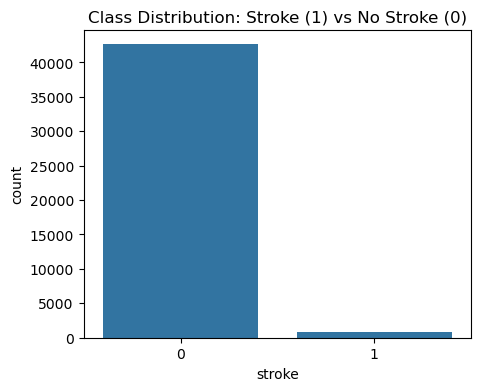


Class Distribution (Ratio):
stroke
0    0.981959
1    0.018041
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(5, 4))
sns.countplot(x='stroke', data=df)
plt.title('Class Distribution: Stroke (1) vs No Stroke (0)')
plt.show()

stroke_ratio = df['stroke'].value_counts(normalize=True)
print("\nClass Distribution (Ratio):")
print(stroke_ratio)

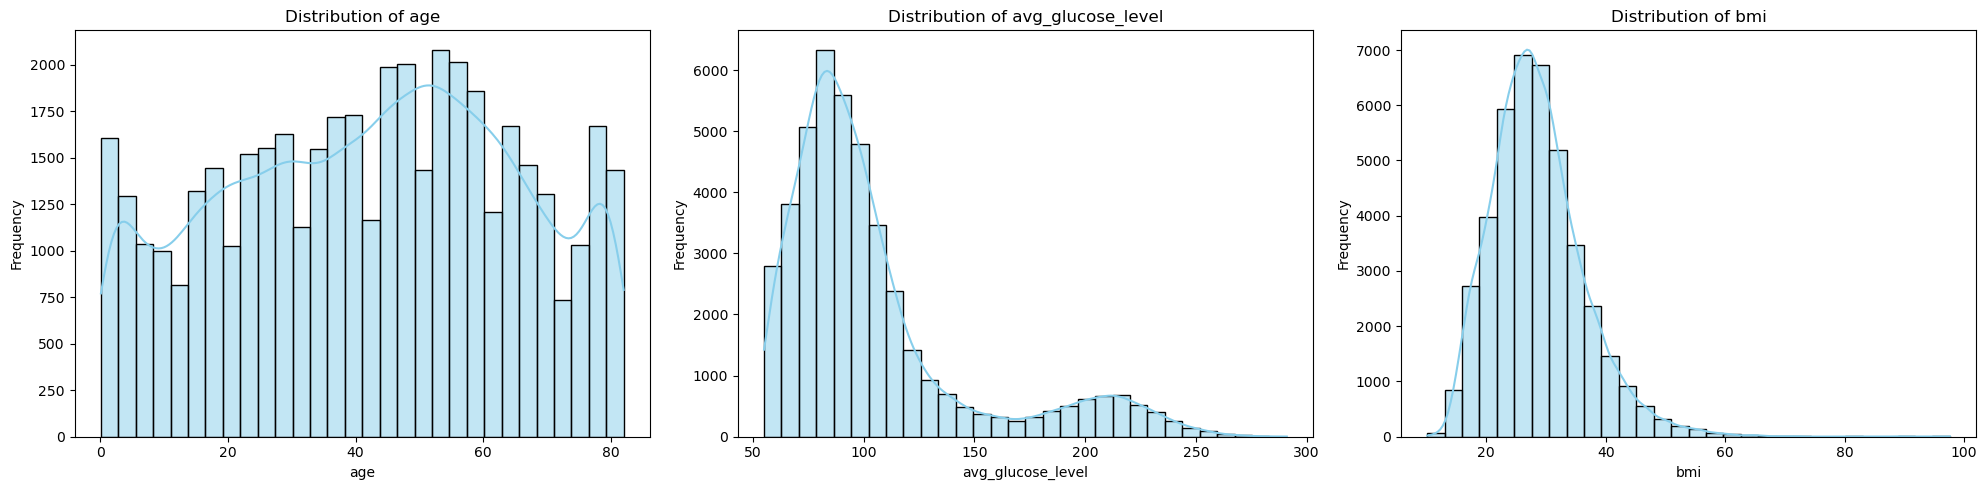

In [6]:
# Define the continuous features
continuous_features = ['age', 'avg_glucose_level', 'bmi']

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

# Plot distributions
for i, feature in enumerate(continuous_features):
    sns.histplot(df[feature], kde=True, color='skyblue', ax=axes[i], bins=30)  # Adjust bins as needed
    axes[i].set_title(f'Distribution of {feature}', fontsize=12)
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)

plt.tight_layout()  # Prevent overlapping
plt.show()

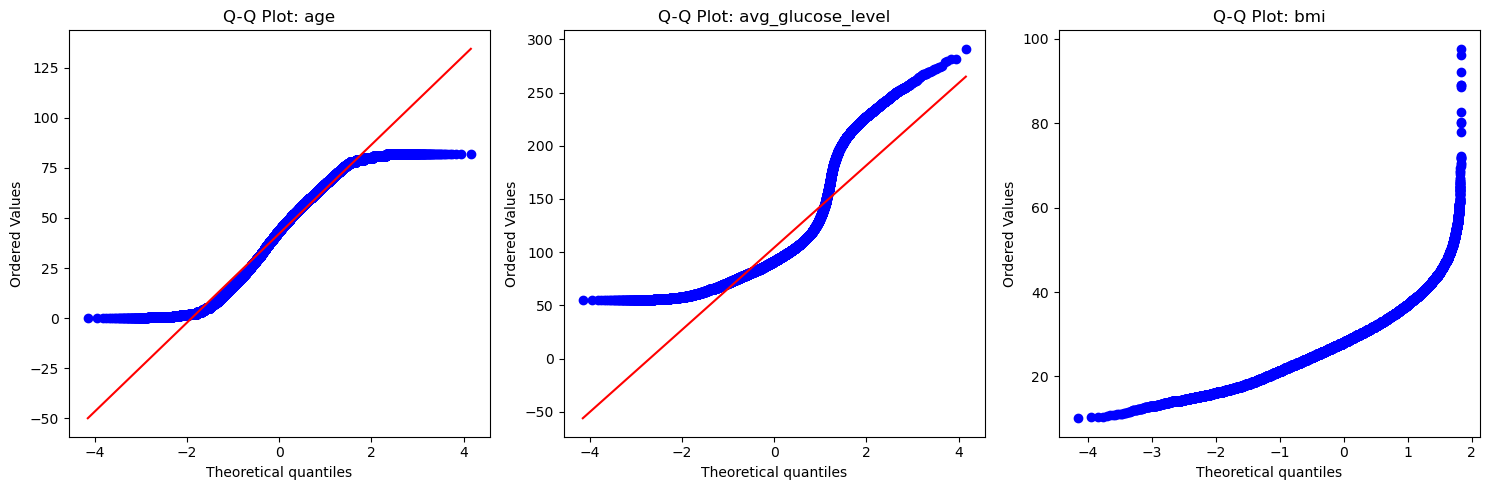

In [7]:
from scipy import stats

plt.figure(figsize=(15, 5))
for i, col in enumerate(continuous_features, 1):
    plt.subplot(1, 3, i)
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot: {col}')
plt.tight_layout()
plt.show()

### Data preprocessing

In [9]:
print("=== Check Duplicate Record ===")
duplicate_count = df.duplicated(subset='id').sum()
print(f"Duplicate IDs: {duplicate_count}")
if duplicate_count > 0:
    print(df[df.duplicated(subset='id', keep=False)].sort_values('id'))

=== Check Duplicate Record ===
Duplicate IDs: 0


In [10]:
print("\n=== Drop Irrelevant Column: ID ===")
df_drop = df.drop(['id'], axis=1)
print(df_drop.columns)


=== Drop Irrelevant Column: ID ===
Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')


In [11]:
print("\n=== Filter Age >= 25 ===")
df_filter = df_drop[df_drop['age'] >= 25].copy()
print(f"Filtered dataset shape: {df_filter.shape}")

print("\n=== Filter BMI >= 60 ===")
df_filter2 = df_filter[df_filter['bmi'] < 60].copy()
df_filter2 = df_filter2[df_filter2['bmi'] > 12].copy()

print(f"Filtered dataset shape: {df_filter2.shape}")


=== Filter Age >= 25 ===
Filtered dataset shape: (32345, 11)

=== Filter BMI >= 60 ===
Filtered dataset shape: (30967, 11)


In [12]:
print("\n=== Handling 'Other' in Gender Column ===")
most_frequent_gender = df_filter2['gender'].value_counts().idxmax()
df_filter2['gender'] = df_filter2['gender'].replace('Other', most_frequent_gender)
print(f"Replaced 'Other' with: {most_frequent_gender}")


=== Handling 'Other' in Gender Column ===
Replaced 'Other' with: Female


In [13]:
print("\n=== Checking Missing Values Before Imputation ===")
print(df_filter2.isnull().sum())


=== Checking Missing Values Before Imputation ===
gender                  0
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type               0
Residence_type          0
avg_glucose_level       0
bmi                     0
smoking_status       5931
stroke                  0
dtype: int64


In [14]:
df_filter2['bmi'].fillna(df_filter2['bmi'].median(), inplace=True)
df_filter2['smoking_status'].fillna('Unknown', inplace=True)
print("Remaining Missing Values:")
print(df_filter2.isnull().sum())

Remaining Missing Values:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\3335583980.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_filter2['bmi'].fillna(df_filter2['bmi'].median(), inplace=True)
C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\3335583980.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [15]:
from sklearn.preprocessing import LabelEncoder
from rich.console import Console
from rich.table import Table

# Initialize the encoders dictionary
label_encoders = {}
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# First fit the encoders (assuming df is your DataFrame)
for col in categorical_cols:
    le = LabelEncoder()
    df_filter2[col] = le.fit_transform(df_filter2[col])
    label_encoders[col] = le  # Store the encoder

console = Console()
table = Table(title="Label Encoding Mappings", show_header=True, header_style="bold magenta")
table.add_column("Column", style="dim", width=15)
table.add_column("Encoded Value", justify="center", style="cyan")
table.add_column("Original Label", style="green")

for col in categorical_cols:
    # Add a separator between columns
    if col != categorical_cols[0]:
        table.add_row("─"*15, "─"*15, "─"*15, style="dim")
    
    for i, label in enumerate(label_encoders[col].classes_):
        table.add_row(
            col if i == 0 else "",
            str(i),
            str(label)
        )

console.print(table)

                Label Encoding Mappings                
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Column          ┃  Encoded Value  ┃ Original Label  ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gender          │        0        │ Female          │
│                 │        1        │ Male            │
│ ─────────────── │ ─────────────── │ ─────────────── │
│ ever_married    │        0        │ No              │
│                 │        1        │ Yes             │
│ ─────────────── │ ─────────────── │ ─────────────── │
│ work_type       │        0        │ Govt_job        │
│                 │        1        │ Never_worked    │
│                 │        2        │ Private         │
│                 │        3        │ Self-employed   │
│ ─────────────── │ ─────────────── │ ─────────────── │
│ Residence_type  │        0        │ Rural           │
│                 │        1        │ Urban           │
│ ─────────────── │ ─────────────── │ ─────────────── │
│ smoking_status  │        0        │ Unknown         │
│                 │        1        │ formerly smoked │
│                 │        2        │ never smoked    │
│                 │        3        │ smokes          │
└─────────────────┴─────────────────┴─────────────────┘

In [16]:
df_encoded=df_filter2.copy()


=== Checking Outliers ===


<Figure size 1800x500 with 0 Axes>

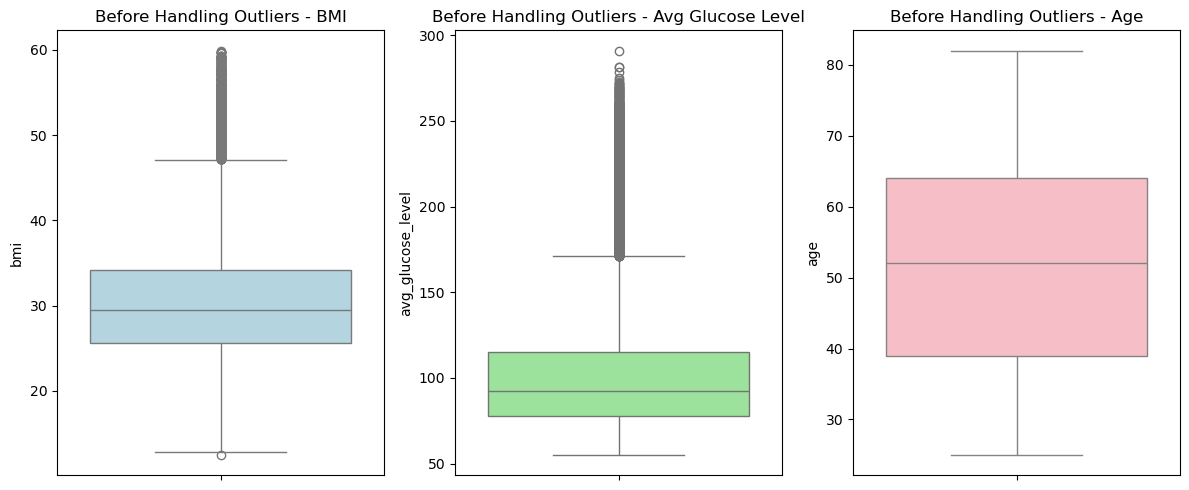


bmi IQR Outlier Limits:
Lower Bound: 12.70, Upper Bound: 47.10
Original Max: 59.90, Min: 12.50
Capped Max: 47.10, Min: 12.70

avg_glucose_level IQR Outlier Limits:
Lower Bound: 22.05, Upper Bound: 170.99
Original Max: 291.05, Min: 55.01
Capped Max: 170.99, Min: 55.01


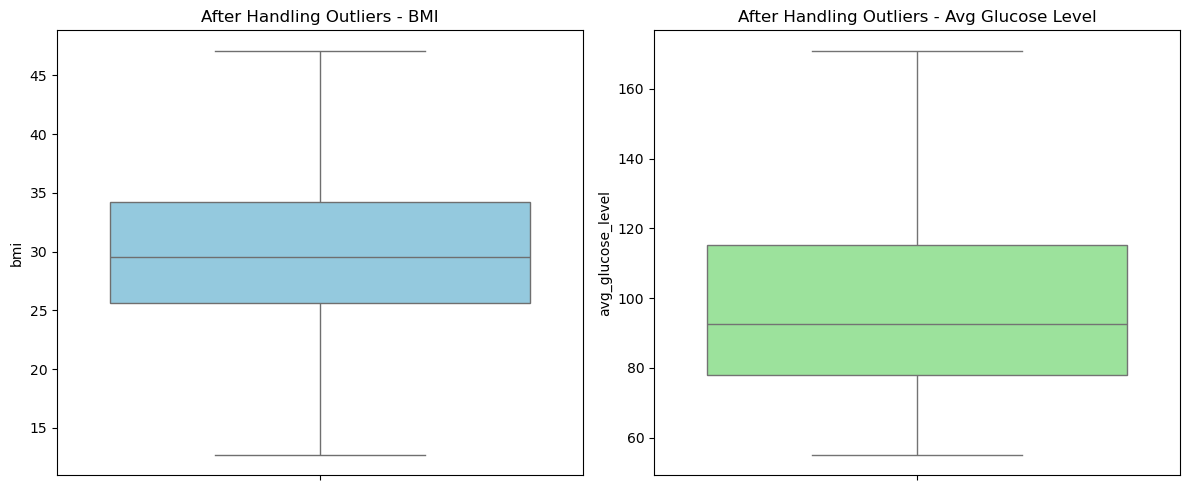

In [17]:
print("\n=== Checking Outliers ===")
def cap_outliers_iqr(df_encoded, column):
    Q1 = df_encoded[column].quantile(0.25)
    Q3 = df_encoded[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"\n{column} IQR Outlier Limits:")
    print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"Original Max: {df_encoded[column].max():.2f}, Min: {df_encoded[column].min():.2f}")

    # Capping
    df_encoded[column] = df_encoded[column].clip(lower=lower_bound, upper=upper_bound)
    print(f"Capped Max: {df_encoded[column].max():.2f}, Min: {df_encoded[column].min():.2f}")

# === BEFORE: Boxplots to visualize original data ===
plt.figure(figsize=(18, 5))

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df_encoded['bmi'], color='lightblue')
plt.title('Before Handling Outliers - BMI')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_encoded['avg_glucose_level'], color='lightgreen')
plt.title('Before Handling Outliers - Avg Glucose Level')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_encoded['age'], color='lightpink')
plt.title('Before Handling Outliers - Age')
plt.tight_layout()
plt.show()

# === Capping using IQR method ===
cap_outliers_iqr(df_encoded, 'bmi')
cap_outliers_iqr(df_encoded, 'avg_glucose_level')

# === AFTER: Boxplots to verify result ===
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_encoded['bmi'], color='skyblue')
plt.title('After Handling Outliers - BMI')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_encoded['avg_glucose_level'], color='lightgreen')
plt.title('After Handling Outliers - Avg Glucose Level')
plt.tight_layout()
plt.show()

In [18]:
print("=== Checking Final Dataset Information ===")
df_encoded.info()

=== Checking Final Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
Index: 30967 entries, 1 to 43399
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             30967 non-null  int32  
 1   age                30967 non-null  float64
 2   hypertension       30967 non-null  int64  
 3   heart_disease      30967 non-null  int64  
 4   ever_married       30967 non-null  int32  
 5   work_type          30967 non-null  int32  
 6   Residence_type     30967 non-null  int32  
 7   avg_glucose_level  30967 non-null  float64
 8   bmi                30967 non-null  float64
 9   smoking_status     30967 non-null  int32  
 10  stroke             30967 non-null  int64  
dtypes: float64(3), int32(5), int64(3)
memory usage: 2.2 MB


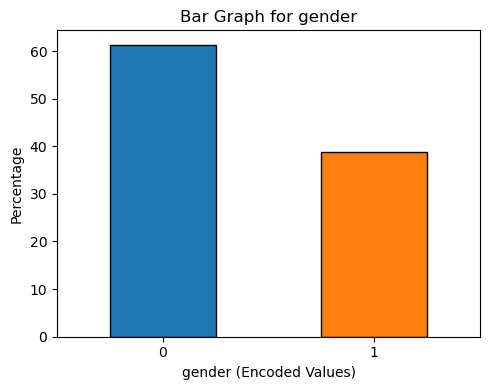

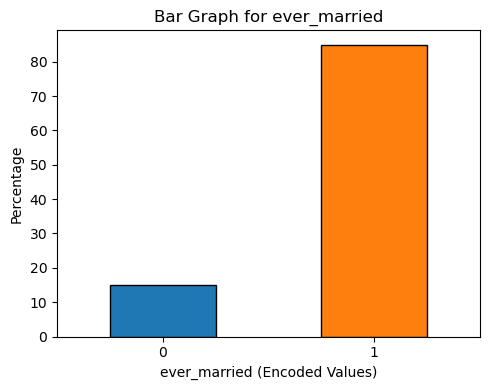

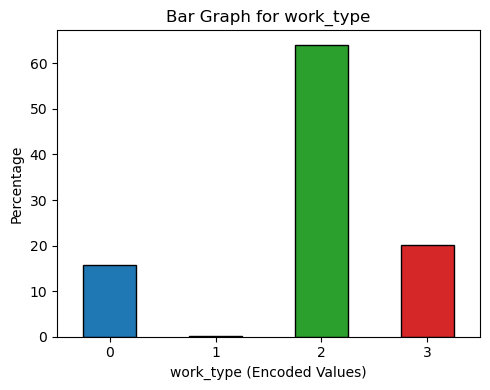

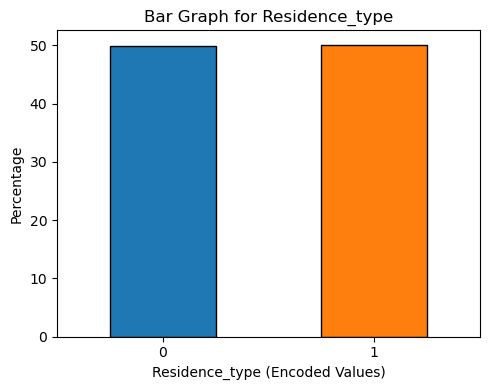

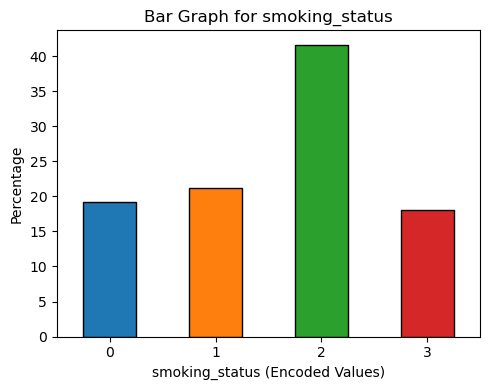

In [19]:
# Get only the encoded categorical columns
categorical_encoded_cols = [col for col in df_encoded.columns if any(orig in col for orig in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'])]

# Define a color palette
colors = plt.cm.tab10.colors

# Plot each encoded categorical feature
for col in categorical_encoded_cols:
    value_counts = df_encoded[col].value_counts(normalize=True) * 100
    
    plt.figure(figsize=(5, 4))
    value_counts.sort_index().plot(
        kind='bar',
        color=[colors[i % len(colors)] for i in range(len(value_counts))],
        edgecolor='black'
    )
    plt.title(f'Bar Graph for {col}')
    plt.xlabel(f'{col} (Encoded Values)')
    plt.ylabel('Percentage')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [20]:
### Separate feature and target
X = df_encoded.drop('stroke',axis=1)
y = df_encoded['stroke']
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y, random_state=42)
# Initialize MinMaxScaler
scaler = MinMaxScaler()
# Fit the scaler on training data and transform both training and test data
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)        

In [21]:
print("========== Data Splitting ==========\n")
print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")
print(f"Test ratio: {X_test.shape[0]/X.shape[0]:.1%}")

========== Data Splitting ==========

Training set: (24773, 10), (24773,)
Test set: (6194, 10), (6194,)
Test ratio: 20.0%


## Task 1 & 2

### Baseline training Without Resampling

In [24]:
# Define models
models = {
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression()
}

# Initialize a dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    # ---- Full Training ----
    model.fit(X_train, y_train)
    
    # ---- Test Evaluation ----
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for PR-AUC and ROC-AUC
    
    # ---- Metrics ----
    # Critical Metrics for Imbalanced Data
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    sensitivity = recall_score(y_test, y_pred)
    specificity = confusion_matrix(y_test, y_pred)[0, 0] / (confusion_matrix(y_test, y_pred)[0, 0] + confusion_matrix(y_test, y_pred)[0, 1])
    
    # ---- Cross-Validation ---- (if needed for the summary, not required in the initial part of the code)
    cv = StratifiedKFold(n_splits=5)
    cv_roc_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_pr_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring='average_precision')
    
    # ---- Store Results ----
    results[name] = {
        "CV ROC-AUC Mean": np.mean(cv_roc_auc),
        "CV ROC-AUC Std": np.std(cv_roc_auc),
        "CV PR-AUC Mean": np.mean(cv_pr_auc),
        "CV PR-AUC Std": np.std(cv_pr_auc),
        "Test ROC-AUC": roc_auc_score(y_test, y_prob),
        "Test PR-AUC": pr_auc,
        "Sensitivity (Recall)": sensitivity,
        "Specificity": specificity,
        "Precision": precision_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
        "Classification Report": classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke'], output_dict=True),
        "Model": model
    }

# Create a summary DataFrame for metrics comparison
summary_baseline_data = []
for name, result in results.items():
    summary_baseline_data.append({
        "Model": name,
        "CV ROC-AUC": f"{result['CV ROC-AUC Mean']:.3f} ± {result['CV ROC-AUC Std']:.3f}",
        "CV PR-AUC": f"{result['CV PR-AUC Mean']:.3f} ± {result['CV PR-AUC Std']:.3f}",
        "Test ROC-AUC": f"{result['Test ROC-AUC']:.3f}",
        "Test PR-AUC": f"{result['Test PR-AUC']:.3f}",
        "Sensitivity": f"{result['Sensitivity (Recall)']:.3f}",
        "Specificity": f"{result['Specificity']:.3f}",
        "Precision": f"{result['Precision']:.3f}",
        "F1 Score": f"{result['F1 Score']:.3f}"
    })

summary_baseline_df = pd.DataFrame(summary_baseline_data)
summary_baseline_df = summary_baseline_df.set_index("Model")

# Display the results
print("\n" + "="*80)
print("STROKE PREDICTION MODEL COMPARISON".center(80))
print("="*80)

# Display the summary table
display(summary_baseline_df.style
       .set_caption("Model Performance Summary (Baseline Without Resampling)")
       .set_properties(**{'text-align': 'center'})
       .highlight_max(subset=["Test PR-AUC", "Sensitivity","Precision"], color='lightgreen')
       .highlight_min(subset=["Test PR-AUC", "Sensitivity","Precision"], color='lightcoral')
       .format(precision=3))

# Display detailed results for each model
for name, result in results.items():
    print("\n" + "="*80)
    print(f"MODEL: {name.upper()}".center(80))
    print("="*80)
    
    # Metrics
    metrics_baseline_df = pd.DataFrame({
        "Cross-Validation": [
            f"{result['CV ROC-AUC Mean']:.3f} ± {result['CV ROC-AUC Std']:.3f}",
            f"{result['CV PR-AUC Mean']:.3f} ± {result['CV PR-AUC Std']:.3f}"
        ],
        "Test Set": [
            f"{result['Test ROC-AUC']:.3f}",
            f"{result['Test PR-AUC']:.3f}"
        ]
    }, index=["ROC-AUC", "PR-AUC"])
    
    print("\nPerformance Metrics:")
    display(metrics_baseline_df.style.set_properties(**{'text-align': 'center'}))
    
    # Classification metrics
    print("\nComplete Classification Report:")
    cr_baseline_df = pd.DataFrame(result['Classification Report']).transpose()
    display(cr_baseline_df.style.format("{:.3f}").set_properties(**{'text-align': 'center'}))
    
    # Confusion matrix
    cm_baseline_df = pd.DataFrame(
        result['Confusion Matrix'],
        index=['Actual No Stroke', 'Actual Stroke'],
        columns=['Predicted No Stroke', 'Predicted Stroke']
    )
    
    print("\nConfusion Matrix:")
    display(cm_baseline_df.style.set_properties(**{'text-align': 'center'}))
    
    print("\n" + "-"*80)

C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ziyan\anaconda3\Lib\site-packages\sklea


                       STROKE PREDICTION MODEL COMPARISON                       


,CV ROC-AUC,CV PR-AUC,Test ROC-AUC,Test PR-AUC,Sensitivity,Specificity,Precision,F1 Score
Model,,,,,,,,
KNN,0.560 ± 0.012,0.030 ± 0.004,0.561,0.043,0.008,1.000,0.333,0.015
Naive Bayes,0.788 ± 0.012,0.073 ± 0.007,0.798,0.067,0.266,0.942,0.088,0.132
Decision Tree,0.520 ± 0.002,0.023 ± 0.001,0.538,0.099,0.102,0.974,0.077,0.088
Logistic Regression,0.809 ± 0.003,0.088 ± 0.008,0.816,0.074,0.000,1.000,0.000,0.000



                                   MODEL: KNN                                   

Performance Metrics:


,Cross-Validation,Test Set
ROC-AUC,0.560 ± 0.012,0.561
PR-AUC,0.030 ± 0.004,0.043


...


Complete Classification Report:


,precision,recall,f1-score,support
No Stroke,0.979,1.000,0.990,6066.000
Stroke,0.000,0.000,0.000,128.000
accuracy,0.979,0.979,0.979,0.979
macro avg,0.490,0.500,0.495,6194.000
weighted avg,0.959,0.979,0.969,6194.000



Confusion Matrix:


,Predicted No Stroke,Predicted Stroke
Actual No Stroke,6066,0
Actual Stroke,128,0



--------------------------------------------------------------------------------


### Visualise Baseline

C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\2189140190.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_pred, palette=colors, ax=axes[row, col])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\2189140190.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_pred, palette=colors, ax=axes[row, col])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\2189140190.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_pred, palette=colors, ax=axes[row, col])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_35

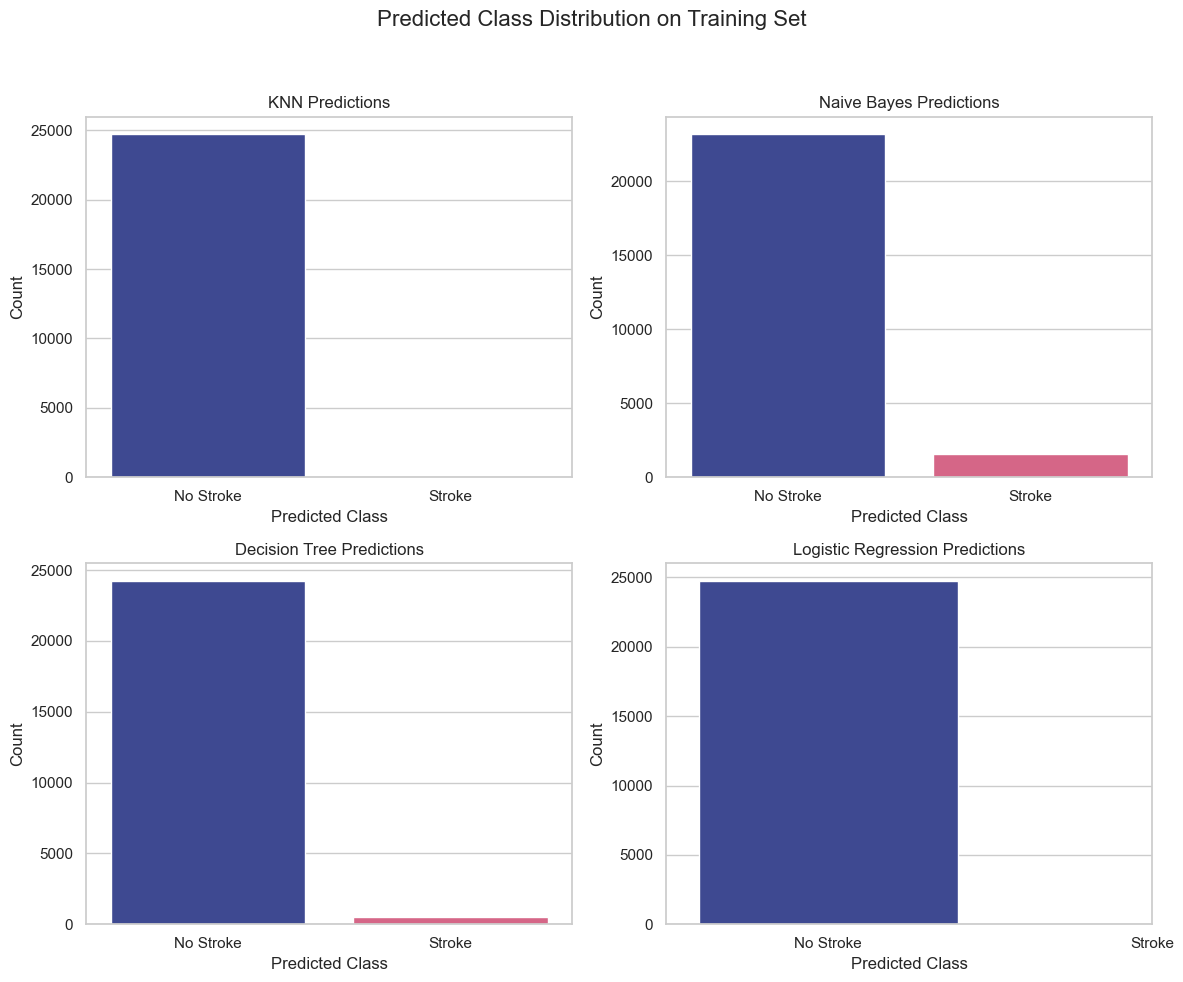

In [26]:
# Set Seaborn theme
sns.set(style="whitegrid")
colors = ["#303F9F", "#E75480"]

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Predicted Class Distribution on Training Set", fontsize=16)

# Choose models to display
selected_models = list(results.keys())[:4]  

# Plot each model's predicted class distribution on training data
for i, model_name in enumerate(selected_models):
    row, col = divmod(i, 2)
    
    # Predict on training data (original or resampled)
    y_train_pred = results[model_name]["Model"].predict(X_train)
    
    sns.countplot(x=y_train_pred, palette=colors, ax=axes[row, col])
    axes[row, col].set_title(f"{model_name} Predictions")
    axes[row, col].set_xlabel("Predicted Class")
    axes[row, col].set_ylabel("Count")
    axes[row, col].set_xticks([0, 1])
    axes[row, col].set_xticklabels(["No Stroke", "Stroke"])

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\1869480453.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred, palette=colors, ax=axes[row, col])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\1869480453.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred, palette=colors, ax=axes[row, col])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\1869480453.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred, palette=colors, ax=axes[row, col])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\1869480453.py:

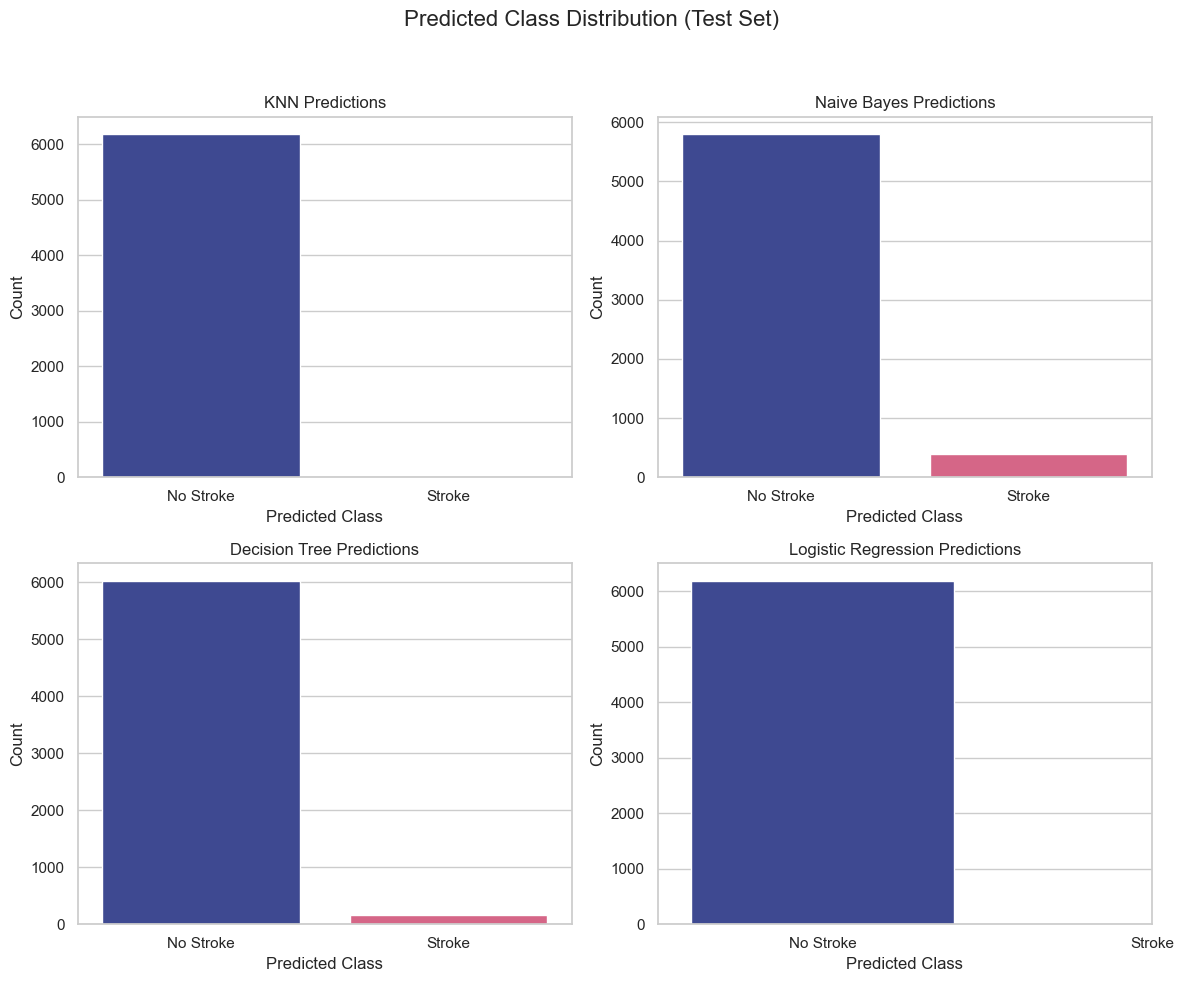

In [27]:
# Set Seaborn theme
sns.set(style="whitegrid")
colors = ["#303F9F", "#E75480"]

# Create subplots for model predictions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Predicted Class Distribution (Test Set)", fontsize=16)

# Select four models to visualize (if more, we can extend this)
selected_models = list(results.keys())[:4]  # First 4 models

# Plot predicted class distribution for each model
for i, model_name in enumerate(selected_models):
    row, col = divmod(i, 2)
    y_pred = results[model_name]["Model"].predict(X_test)

    sns.countplot(x=y_pred, palette=colors, ax=axes[row, col])
    axes[row, col].set_title(f"{model_name} Predictions")
    axes[row, col].set_xlabel("Predicted Class")
    axes[row, col].set_ylabel("Count")
    axes[row, col].set_xticks([0, 1])
    axes[row, col].set_xticklabels(["No Stroke", "Stroke"])

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


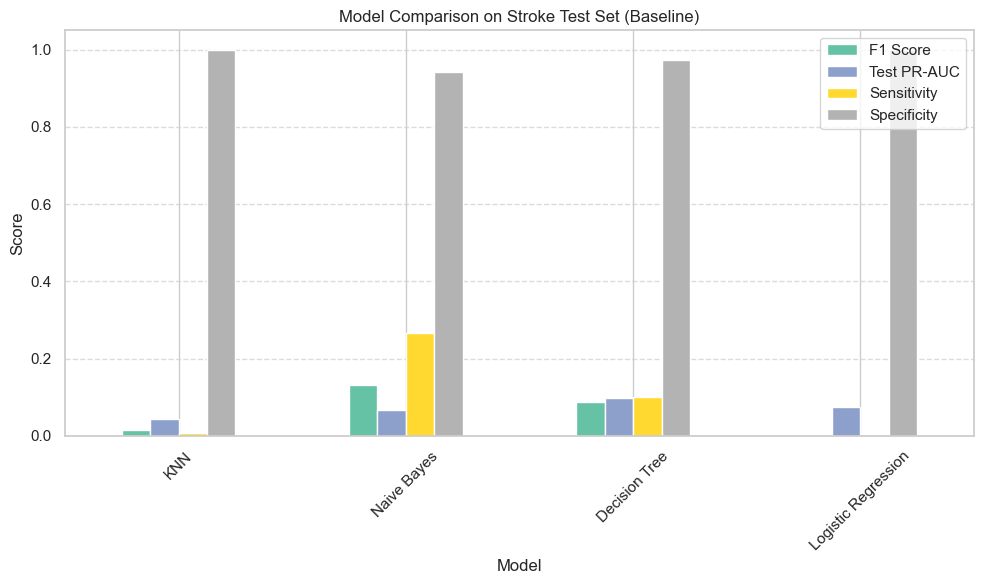

In [28]:
summary_baseline_df[['F1 Score', 'Test PR-AUC', 'Sensitivity', 'Specificity']] = \
    summary_baseline_df[['F1 Score', 'Test PR-AUC', 'Sensitivity', 'Specificity']].apply(pd.to_numeric, errors='coerce')

# Plot
summary_baseline_df[['F1 Score', 'Test PR-AUC', 'Sensitivity', 'Specificity']].plot.bar(
    figsize=(10, 6), 
    rot=45, 
    title="Model Comparison on Stroke Test Set (Baseline)", 
    colormap='Set2',
)
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

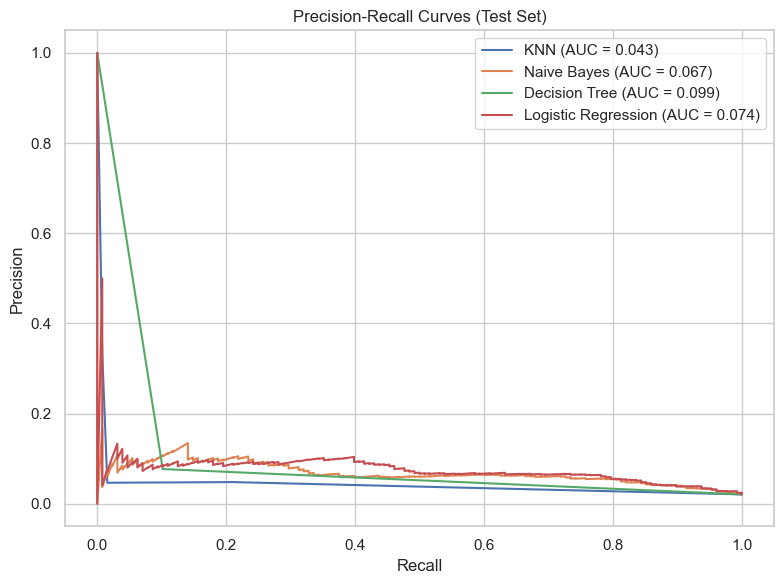

In [29]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))

for name, result in results.items():
    model = result["Model"]
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Test Set)")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()

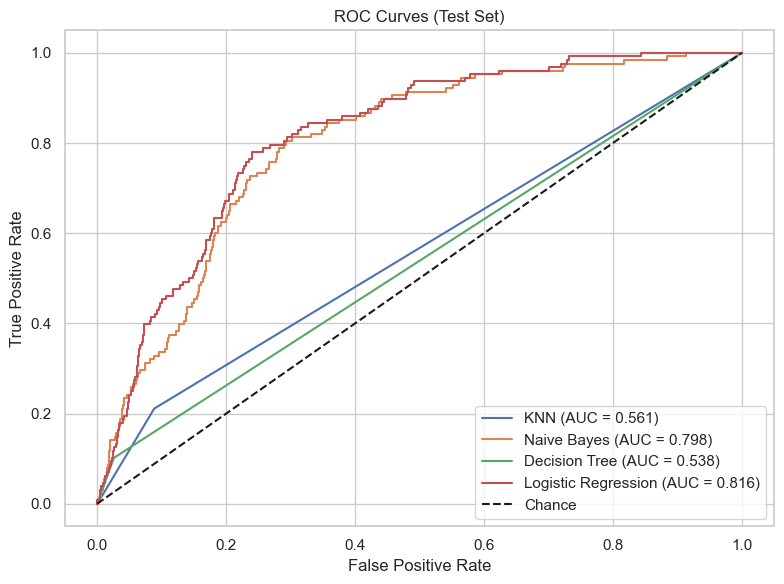

In [30]:

plt.figure(figsize=(8, 6))

for name, result in results.items():
    model = result["Model"]
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test Set)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

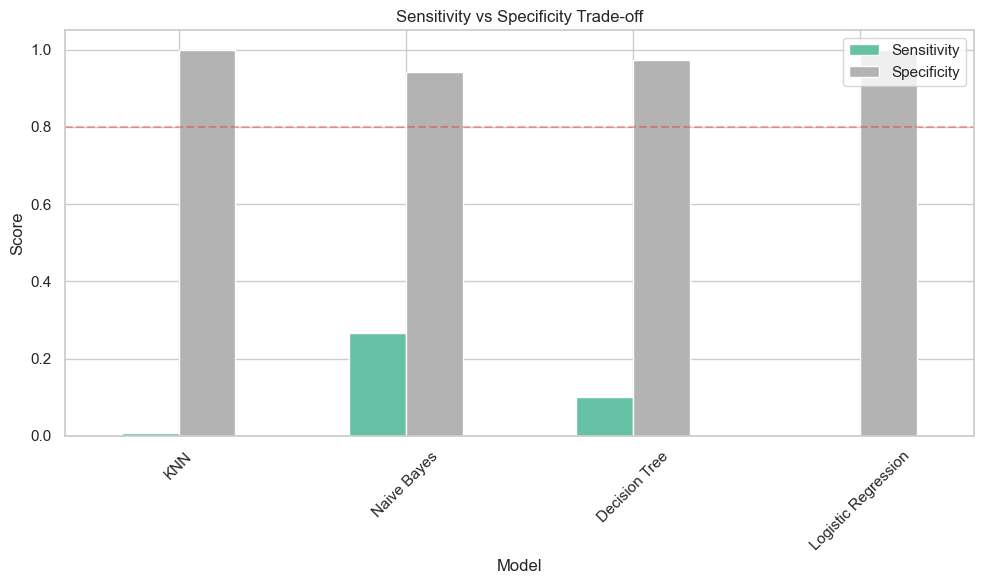

In [31]:
summary_baseline_df[['Sensitivity', 'Specificity']].plot.bar(
    figsize=(10, 6), 
    rot=45, 
    title="Sensitivity vs Specificity Trade-off", 
    colormap='Set2',
)
plt.ylabel('Score')
plt.axhline(0.8, color='red', linestyle='--', alpha=0.3, label='Clinical Threshold')
plt.tight_layout()
plt.show()

## Resampling Method

### SMOTEENN

In [867]:
# Smoteenn
X = df_encoded.drop("stroke", axis=1)
y = df_encoded["stroke"]
feature_names = X.columns.tolist()

C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\2082514977.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette=colors, ax=axes[0, 0])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\2082514977.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(["No Stroke", "Stroke"])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\2082514977.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_before_smoteenn, palette=colors, ax=axes[0, 1])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\2082514977.py:26: UserWarning: set_ticklabels() should only be used with

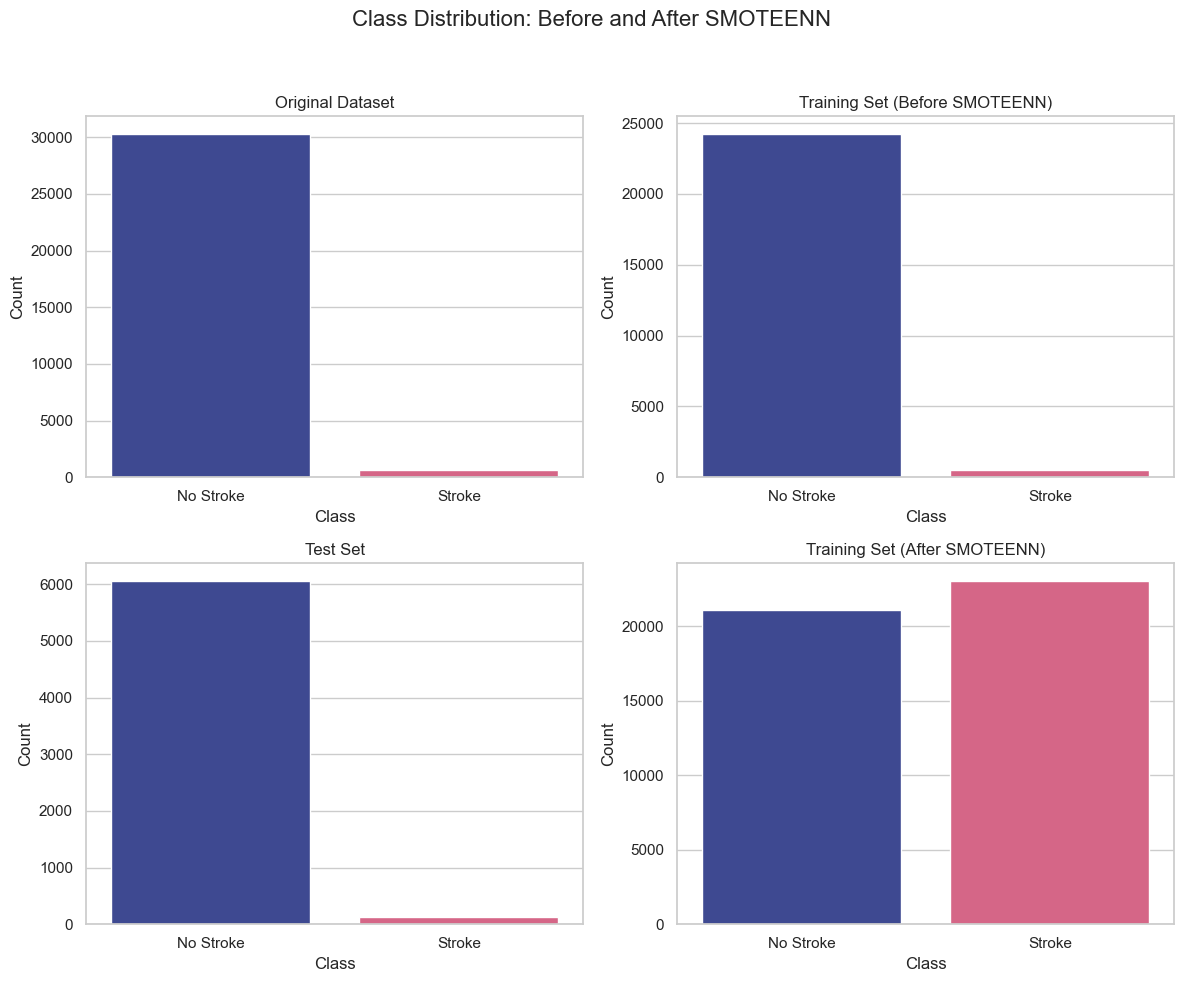


              STROKE PREDICTION MODEL COMPARISON (After SMOTEENN)               


,CV ROC-AUC,CV PR-AUC,Test ROC-AUC,Test PR-AUC,Sensitivity,Specificity,Precision,F1 Score
Model,,,,,,,,
KNN,0.997 ± 0.000,0.995 ± 0.001,0.630,0.144,0.320,0.848,0.042,0.075
Naive Bayes,0.843 ± 0.004,0.828 ± 0.005,0.793,0.066,0.742,0.749,0.059,0.109
Decision Tree,0.966 ± 0.008,0.951 ± 0.006,0.552,0.122,0.180,0.924,0.048,0.076
Logistic Regression,0.863 ± 0.003,0.848 ± 0.003,0.816,0.078,0.805,0.703,0.054,0.101



                                   MODEL: KNN                                   

Performance Metrics:


,Cross-Validation,Test Set
ROC-AUC,0.997 ± 0.000,0.630
PR-AUC,0.995 ± 0.001,0.144



Complete Classification Report:


...


Complete Classification Report:


,precision,recall,f1-score,support
No Stroke,0.994,0.703,0.823,6066.000
Stroke,0.054,0.805,0.101,128.000
accuracy,0.705,0.705,0.705,0.705
macro avg,0.524,0.754,0.462,6194.000
weighted avg,0.975,0.705,0.809,6194.000



Confusion Matrix:


,Predicted No Stroke,Predicted Stroke
Actual No Stroke,4263,1803
Actual Stroke,25,103



--------------------------------------------------------------------------------


In [869]:
X_train_before_smoteenn = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)
y_train_before_smoteenn = pd.Series(y_train)
# Step 2: Apply SMOTEENN only to the training data
smoteenn = SMOTEENN(random_state=1)
X_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(X_train_before_smoteenn, y_train_before_smoteenn)

sns.set(style="whitegrid")
colors = ["#303F9F", "#E75480"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Class Distribution: Before and After SMOTEENN", fontsize=16)

# Plot 1: Original Full Dataset
sns.countplot(x=y, palette=colors, ax=axes[0, 0])
axes[0, 0].set_title("Original Dataset")
axes[0, 0].set_xlabel("Class")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_xticklabels(["No Stroke", "Stroke"])

# Plot 2: Training Set Before SMOTEENN
sns.countplot(x=y_train_before_smoteenn, palette=colors, ax=axes[0, 1])
axes[0, 1].set_title("Training Set (Before SMOTEENN)")
axes[0, 1].set_xlabel("Class")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_xticklabels(["No Stroke", "Stroke"])

# Plot 3: Test Set (Untouched)
sns.countplot(x=y_test, palette=colors, ax=axes[1, 0])
axes[1, 0].set_title("Test Set")
axes[1, 0].set_xlabel("Class")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_xticklabels(["No Stroke", "Stroke"])

# Plot 4: Training Set After SMOTEENN
sns.countplot(x=y_train_smoteenn, palette=colors, ax=axes[1, 1])
axes[1, 1].set_title("Training Set (After SMOTEENN)")
axes[1, 1].set_xlabel("Class")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_xticklabels(["No Stroke", "Stroke"])

# Layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Initialize models
models = {
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression()
}

# Initialize a dictionary to store results
results_smoteenn = {}

# Train and evaluate each model
for name, model in models.items():
    # ---- Full Training ----
    model.fit(X_train_smoteenn, y_train_smoteenn)
    
    # ---- Test Evaluation ----
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for PR-AUC and ROC-AUC
    
    # ---- Metrics ----
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    sensitivity = recall_score(y_test, y_pred)
    specificity = confusion_matrix(y_test, y_pred)[0, 0] / (confusion_matrix(y_test, y_pred)[0, 0] + confusion_matrix(y_test, y_pred)[0, 1])

    # Cross-validation for ROC-AUC and PR-AUC
    cv = StratifiedKFold(n_splits=5)
    cv_roc_auc = cross_val_score(model, X_train_smoteenn, y_train_smoteenn, cv=cv, scoring='roc_auc')
    cv_pr_auc = cross_val_score(model, X_train_smoteenn, y_train_smoteenn, cv=cv, scoring='average_precision')
    
    # ---- Store Results ----
    results_smoteenn[name] = {
        "CV ROC-AUC Mean": np.mean(cv_roc_auc),
        "CV ROC-AUC Std": np.std(cv_roc_auc),
        "CV PR-AUC Mean": np.mean(cv_pr_auc),
        "CV PR-AUC Std": np.std(cv_pr_auc),
        "Test ROC-AUC": roc_auc_score(y_test, y_prob),
        "Test PR-AUC": pr_auc,
        "Sensitivity (Recall)": sensitivity,
        "Specificity": specificity,
        "Precision": precision_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
        "Classification Report": classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke'], output_dict=True),
        "Model": model
    }

# Create a summary DataFrame for metrics comparison
summary_smoteenn_data = []
for name, result in results_smoteenn.items():
    summary_smoteenn_data.append({
        "Model": name,
        "CV ROC-AUC": f"{result['CV ROC-AUC Mean']:.3f} ± {result['CV ROC-AUC Std']:.3f}",
        "CV PR-AUC": f"{result['CV PR-AUC Mean']:.3f} ± {result['CV PR-AUC Std']:.3f}",
        "Test ROC-AUC": f"{result['Test ROC-AUC']:.3f}",
        "Test PR-AUC": f"{result['Test PR-AUC']:.3f}",
        "Sensitivity": f"{result['Sensitivity (Recall)']:.3f}",
        "Specificity": f"{result['Specificity']:.3f}",
        "Precision": f"{result['Precision']:.3f}",
        "F1 Score": f"{result['F1 Score']:.3f}"
    })

summary_smoteenn_df = pd.DataFrame(summary_smoteenn_data)
summary_smoteenn_df = summary_smoteenn_df.set_index("Model")

# Display the results
print("\n" + "="*80)
print("STROKE PREDICTION MODEL COMPARISON (After SMOTEENN)".center(80))
print("="*80)

# Display the summary table
display(summary_smoteenn_df.style
       .set_caption("Model Performance Summary (After SMOTEENN)")
       .set_properties(**{'text-align': 'center'})
       .highlight_max(subset=["Test PR-AUC", "Sensitivity","Precision"], color='lightgreen')
       .highlight_min(subset=["Test PR-AUC", "Sensitivity","Precision"], color='lightcoral')
       .format(precision=3))

# Display detailed results for each model
for name, result in results_smoteenn.items():
    print("\n" + "="*80)
    print(f"MODEL: {name.upper()}".center(80))
    print("="*80)
    
    # Metrics
    metrics_smoteenn_df = pd.DataFrame({
        "Cross-Validation": [
            f"{result['CV ROC-AUC Mean']:.3f} ± {result['CV ROC-AUC Std']:.3f}",
            f"{result['CV PR-AUC Mean']:.3f} ± {result['CV PR-AUC Std']:.3f}"
        ],
        "Test Set": [
            f"{result['Test ROC-AUC']:.3f}",
            f"{result['Test PR-AUC']:.3f}"
        ]
    }, index=["ROC-AUC", "PR-AUC"])
    
    print("\nPerformance Metrics:")
    display(metrics_smoteenn_df.style.set_properties(**{'text-align': 'center'}))
    
    # Classification metrics
    print("\nComplete Classification Report:")
    cr_df = pd.DataFrame(result['Classification Report']).transpose()
    display(cr_df.style.format("{:.3f}").set_properties(**{'text-align': 'center'}))
    
    # Confusion matrix
    cm_df = pd.DataFrame(
        result['Confusion Matrix'],
        index=['Actual No Stroke', 'Actual Stroke'],
        columns=['Predicted No Stroke', 'Predicted Stroke']
    )
    
    print("\nConfusion Matrix:")
    display(cm_df.style.set_properties(**{'text-align': 'center'}))
    
    print("\n" + "-"*80)


### Visualise SMOTEENN

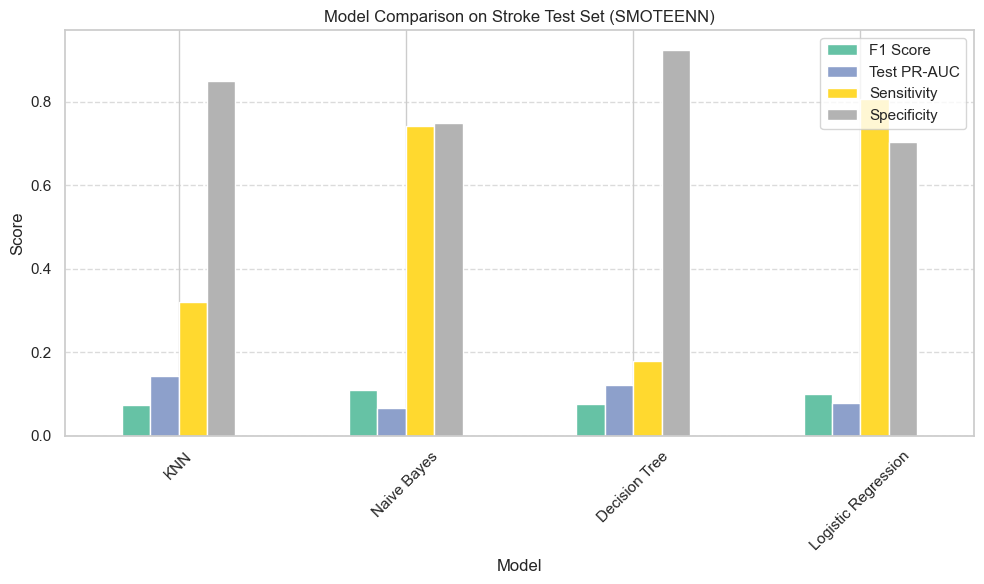

In [873]:
summary_smoteenn_df[['F1 Score', 'Test PR-AUC', 'Sensitivity', 'Specificity']] = \
    summary_smoteenn_df[['F1 Score', 'Test PR-AUC', 'Sensitivity', 'Specificity']].apply(pd.to_numeric, errors='coerce')

# Plot
summary_smoteenn_df[['F1 Score', 'Test PR-AUC', 'Sensitivity', 'Specificity']].plot.bar(
    figsize=(10, 6), 
    rot=45, 
    title="Model Comparison on Stroke Test Set (SMOTEENN)", 
    colormap='Set2',
)
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

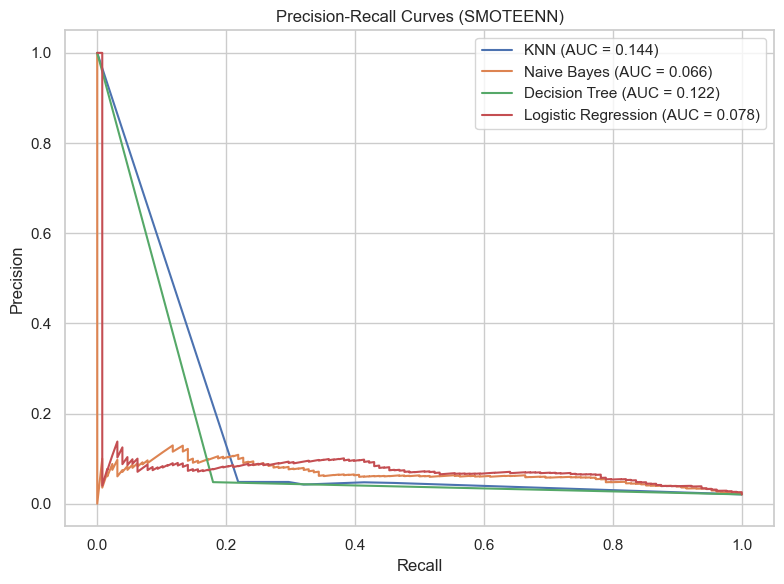

In [875]:
plt.figure(figsize=(8, 6))

for name, result in results_smoteenn.items():
    model = result["Model"]
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (SMOTEENN)")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()

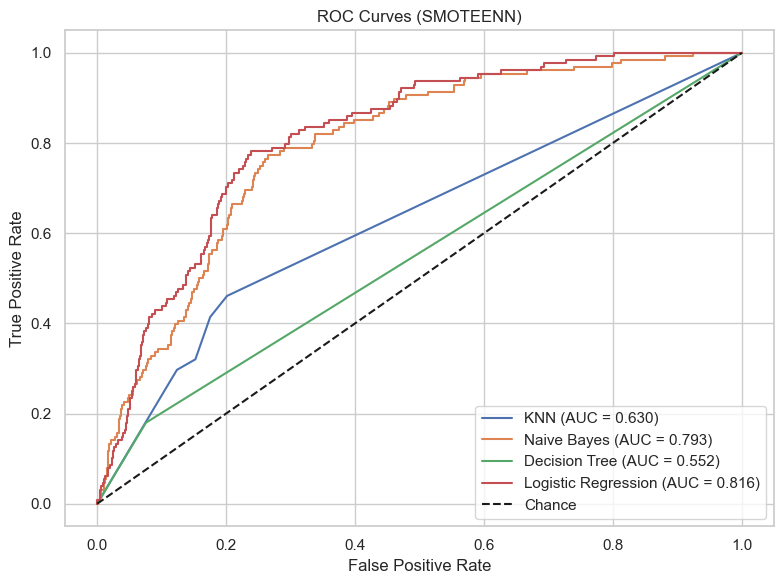

In [877]:
plt.figure(figsize=(8, 6))

for name, result in results_smoteenn.items():
    model = result["Model"]
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (SMOTEENN)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

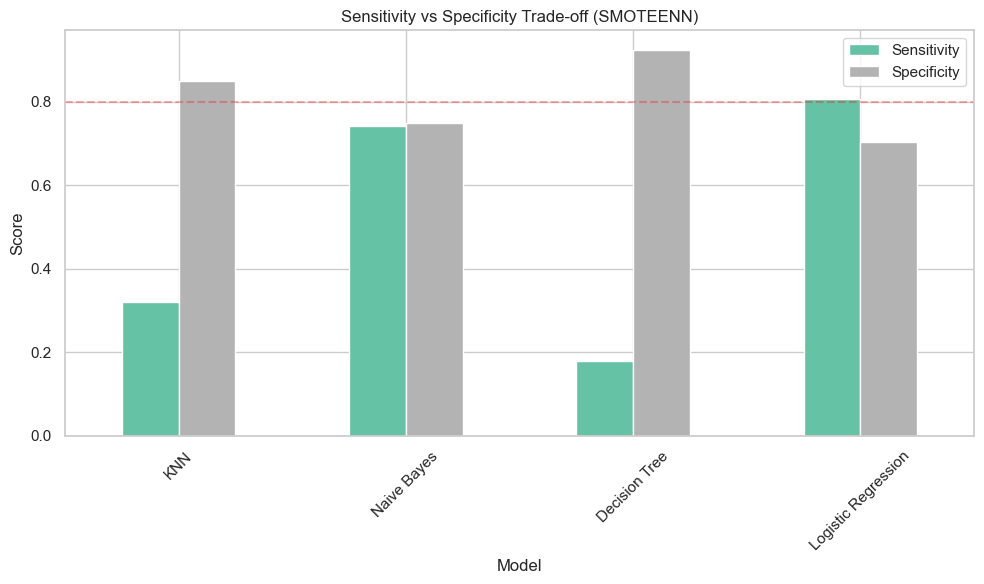

In [893]:
summary_smoteenn_df[['Sensitivity', 'Specificity']].plot.bar(
    figsize=(10, 6), 
    rot=45, 
    title="Sensitivity vs Specificity Trade-off (SMOTEENN)", 
    colormap='Set2',
)
plt.ylabel('Score')
plt.axhline(0.8, color='red', linestyle='--', alpha=0.3, label='Clinical Threshold')
plt.tight_layout()
plt.show()

## Task 2
### Analyze robustness and reliability across different data distributions and conditions.

### SMOTE

C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\608834324.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette=colors, ax=axes[0, 0])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\608834324.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(["No Stroke", "Stroke"])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\608834324.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_before_smote, palette=colors, ax=axes[0, 1])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\608834324.py:28: UserWarning: set_ticklabels() should only be used with a fixe

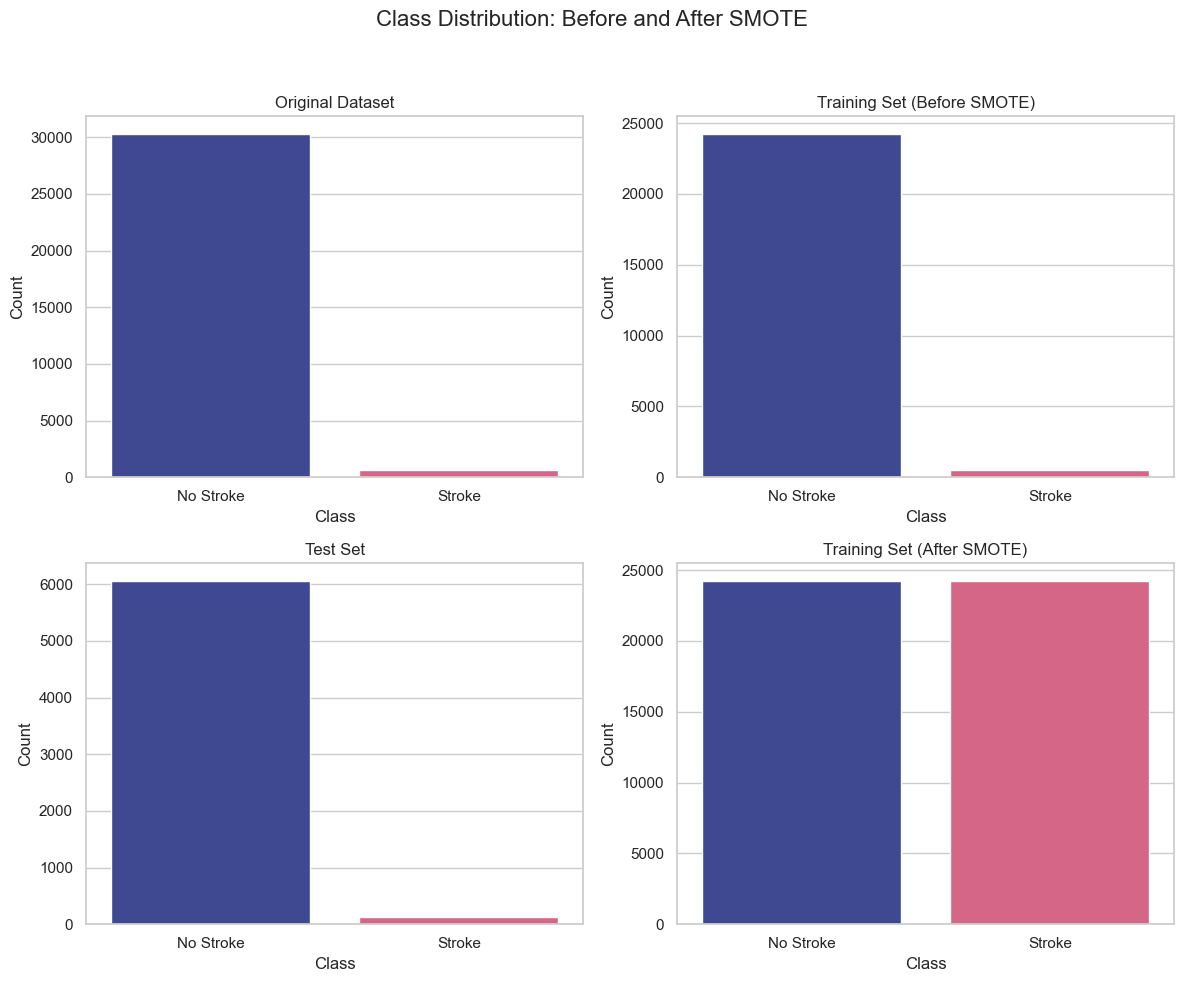


         STROKE PREDICTION MODEL COMPARISON (After SMOTE-OverSampling)          


,CV ROC-AUC,CV PR-AUC,Test ROC-AUC,Test PR-AUC,Sensitivity,Specificity,Precision,F1 Score
Model,,,,,,,,
KNN,0.973 ± 0.001,0.951 ± 0.002,0.608,0.091,0.258,0.884,0.045,0.076
Naive Bayes,0.807 ± 0.003,0.768 ± 0.004,0.791,0.066,0.727,0.755,0.059,0.109
Decision Tree,0.959 ± 0.010,0.938 ± 0.004,0.536,0.094,0.117,0.955,0.052,0.072
Logistic Regression,0.824 ± 0.002,0.783 ± 0.004,0.815,0.077,0.789,0.730,0.058,0.108



                                   MODEL: KNN                                   

Performance Metrics:


,Cross-Validation,Test Set
ROC-AUC,0.973 ± 0.001,0.608
PR-AUC,0.951 ± 0.002,0.091



Complete Classification Report:


...

,Cross-Validation,Test Set
ROC-AUC,0.824 ± 0.002,0.815
PR-AUC,0.783 ± 0.004,0.077



Complete Classification Report:


,precision,recall,f1-score,support
No Stroke,0.994,0.730,0.842,6066.000
Stroke,0.058,0.789,0.108,128.000
accuracy,0.731,0.731,0.731,0.731
macro avg,0.526,0.760,0.475,6194.000
weighted avg,0.975,0.731,0.827,6194.000



Confusion Matrix:


,Predicted No Stroke,Predicted Stroke
Actual No Stroke,4429,1637
Actual Stroke,27,101


In [33]:
X_train_before_smote, y_train_before_smote = X_train.copy(), y_train.copy()

# Step 2: Apply SMOTE to training data only
# Apply SMOTE to training data only
os = SMOTE(random_state=1)
X_train_smote, y_train_smote = os.fit_resample(X_train_before_smote, y_train_before_smote)

# Set Seaborn theme and color palette
sns.set(style="whitegrid")
colors = ["#303F9F", "#E75480"]

# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Class Distribution: Before and After SMOTE", fontsize=16)

# Plot 1: Full dataset
sns.countplot(x=y, palette=colors, ax=axes[0, 0])
axes[0, 0].set_title("Original Dataset")
axes[0, 0].set_xlabel("Class")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_xticklabels(["No Stroke", "Stroke"])

# Plot 2: Training Set BEFORE SMOTE
sns.countplot(x=y_train_before_smote, palette=colors, ax=axes[0, 1])
axes[0, 1].set_title("Training Set (Before SMOTE)")
axes[0, 1].set_xlabel("Class")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_xticklabels(["No Stroke", "Stroke"])

# Plot 3: Test Set (unchanged)
sns.countplot(x=y_test, palette=colors, ax=axes[1, 0])
axes[1, 0].set_title("Test Set")
axes[1, 0].set_xlabel("Class")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_xticklabels(["No Stroke", "Stroke"])

# Plot 4: Training Set AFTER SMOTE
sns.countplot(x=y_train_smote, palette=colors, ax=axes[1, 1])
axes[1, 1].set_title("Training Set (After SMOTE)")
axes[1, 1].set_xlabel("Class")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_xticklabels(["No Stroke", "Stroke"])

# Layout fix
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Initialize models
models = {
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression()
}

# Initialize a dictionary to store results
results_smote = {}

# Train and evaluate each model
for name, model in models.items():
    # ---- Full Training ----
    model.fit(X_train_smote, y_train_smote)
    
    # ---- Test Evaluation ----
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for PR-AUC and ROC-AUC
    
    # ---- Metrics ----
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    sensitivity = recall_score(y_test, y_pred)
    specificity = confusion_matrix(y_test, y_pred)[0, 0] / (confusion_matrix(y_test, y_pred)[0, 0] + confusion_matrix(y_test, y_pred)[0, 1])

    # Cross-validation for ROC-AUC and PR-AUC
    cv = StratifiedKFold(n_splits=5)
    cv_roc_auc = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring='roc_auc')
    cv_pr_auc = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring='average_precision')
    
    # ---- Store Results ----
    results_smote[name] = {
        "CV ROC-AUC Mean": np.mean(cv_roc_auc),
        "CV ROC-AUC Std": np.std(cv_roc_auc),
        "CV PR-AUC Mean": np.mean(cv_pr_auc),
        "CV PR-AUC Std": np.std(cv_pr_auc),
        "Test ROC-AUC": roc_auc_score(y_test, y_prob),
        "Test PR-AUC": pr_auc,
        "Sensitivity (Recall)": sensitivity,
        "Specificity": specificity,
        "Precision": precision_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
        "Classification Report": classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke'], output_dict=True),
        "Model": model
    }

# Step 4: Create a summary DataFrame for metrics comparison
summary_smote_data = []
for name, result in results_smote.items():
    summary_smote_data.append({
        "Model": name,
        "CV ROC-AUC": f"{result['CV ROC-AUC Mean']:.3f} ± {result['CV ROC-AUC Std']:.3f}",
        "CV PR-AUC": f"{result['CV PR-AUC Mean']:.3f} ± {result['CV PR-AUC Std']:.3f}",
        "Test ROC-AUC": f"{result['Test ROC-AUC']:.3f}",
        "Test PR-AUC": f"{result['Test PR-AUC']:.3f}",
        "Sensitivity": f"{result['Sensitivity (Recall)']:.3f}",
        "Specificity": f"{result['Specificity']:.3f}",
        "Precision": f"{result['Precision']:.3f}",
        "F1 Score": f"{result['F1 Score']:.3f}"
    })

summary_smote_df = pd.DataFrame(summary_smote_data)
summary_smote_df = summary_smote_df.set_index("Model")

# Display the results
print("\n" + "="*80)
print("STROKE PREDICTION MODEL COMPARISON (After SMOTE-OverSampling)".center(80))
print("="*80)

# Display the summary table
display(summary_smote_df.style
       .set_caption("Model Performance Summary (After SMOTE)")
       .set_properties(**{'text-align': 'center'})
       .highlight_max(subset=["Test PR-AUC", "Sensitivity", "Precision"], color='lightgreen')
       .highlight_min(subset=["Test PR-AUC", "Sensitivity", "Precision"], color='lightcoral')
       .format(precision=3))

# Display detailed results for each model
for name, result in results_smote.items():
    print("\n" + "="*80)
    print(f"MODEL: {name.upper()}".center(80))
    print("="*80)
    
    # Cross-Validation and Test Metrics
    metrics_smote_df = pd.DataFrame({
        "Cross-Validation": [
            f"{result['CV ROC-AUC Mean']:.3f} ± {result['CV ROC-AUC Std']:.3f}",
            f"{result['CV PR-AUC Mean']:.3f} ± {result['CV PR-AUC Std']:.3f}"
        ],
        "Test Set": [
            f"{result['Test ROC-AUC']:.3f}",
            f"{result['Test PR-AUC']:.3f}"
        ]
    }, index=["ROC-AUC", "PR-AUC"])
    
    print("\nPerformance Metrics:")
    display(metrics_smote_df.style.set_properties(**{'text-align': 'center'}))
    
    # Classification metrics
    print("\nComplete Classification Report:")
    cr_df = pd.DataFrame(result['Classification Report']).transpose()
    display(cr_df.style.format("{:.3f}").set_properties(**{'text-align': 'center'}))
    
    # Confusion matrix
    cm_df = pd.DataFrame(
        result['Confusion Matrix'],
        index=['Actual No Stroke', 'Actual Stroke'],
        columns=['Predicted No Stroke', 'Predicted Stroke']
    )
    
    print("\nConfusion Matrix:")
    display(cm_df.style.set_properties(**{'text-align': 'center'}))
    
    print("\n" + "="*80)

### Visualise SMOTE

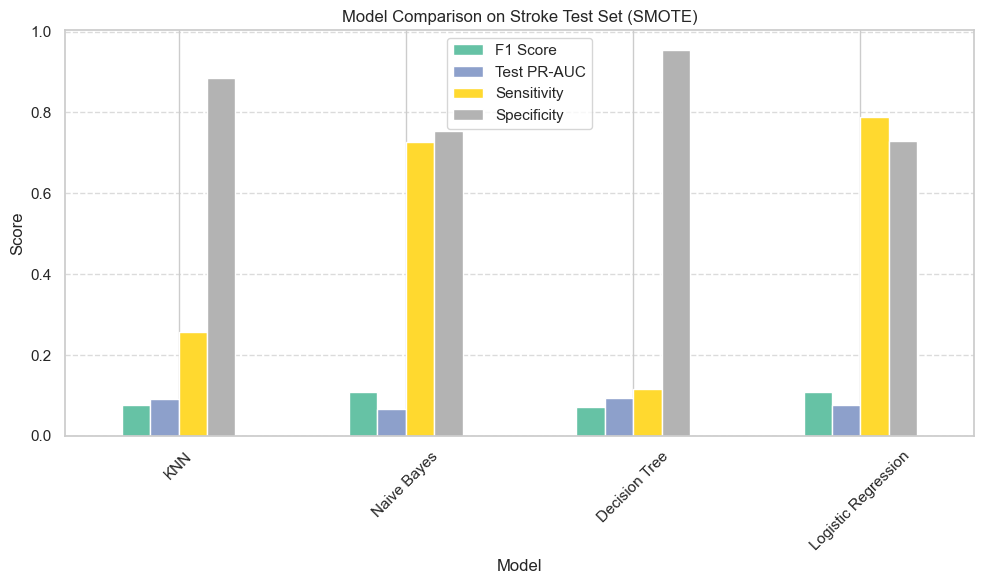

In [36]:
summary_smote_df[['F1 Score', 'Test PR-AUC', 'Sensitivity', 'Specificity']] = \
    summary_smote_df[['F1 Score', 'Test PR-AUC', 'Sensitivity', 'Specificity']].apply(pd.to_numeric, errors='coerce')

# Plot
summary_smote_df[['F1 Score', 'Test PR-AUC', 'Sensitivity', 'Specificity']].plot.bar(
    figsize=(10, 6), 
    rot=45, 
    title="Model Comparison on Stroke Test Set (SMOTE)", 
    colormap='Set2',
)
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

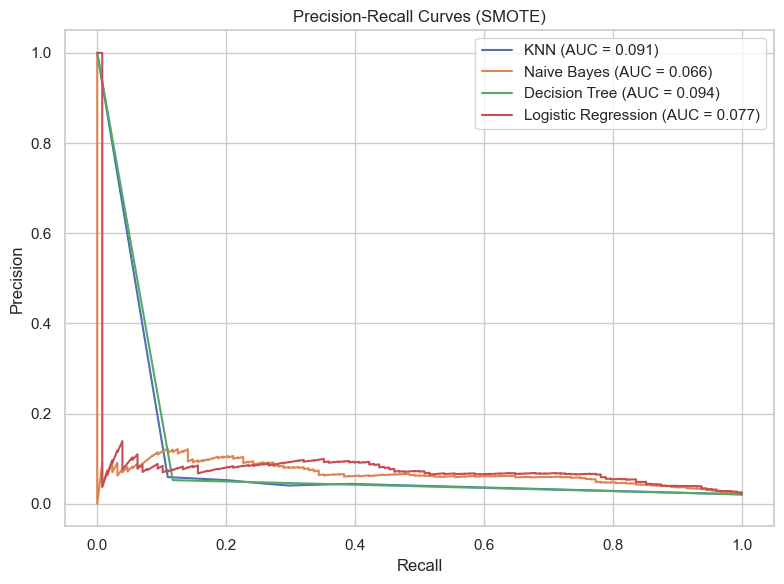

In [37]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))

for name, result in results_smote.items():
    model = result["Model"]
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (SMOTE)")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()

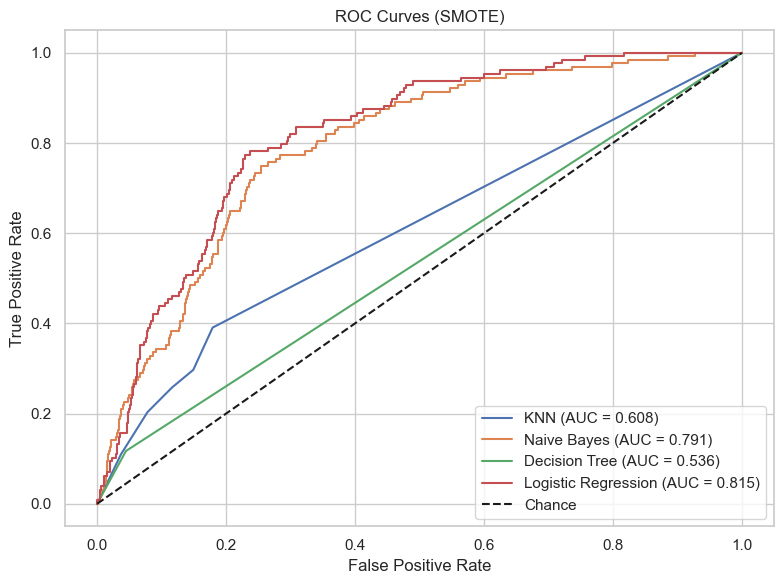

In [38]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, result in results_smote.items():
    model = result["Model"]
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (SMOTE)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

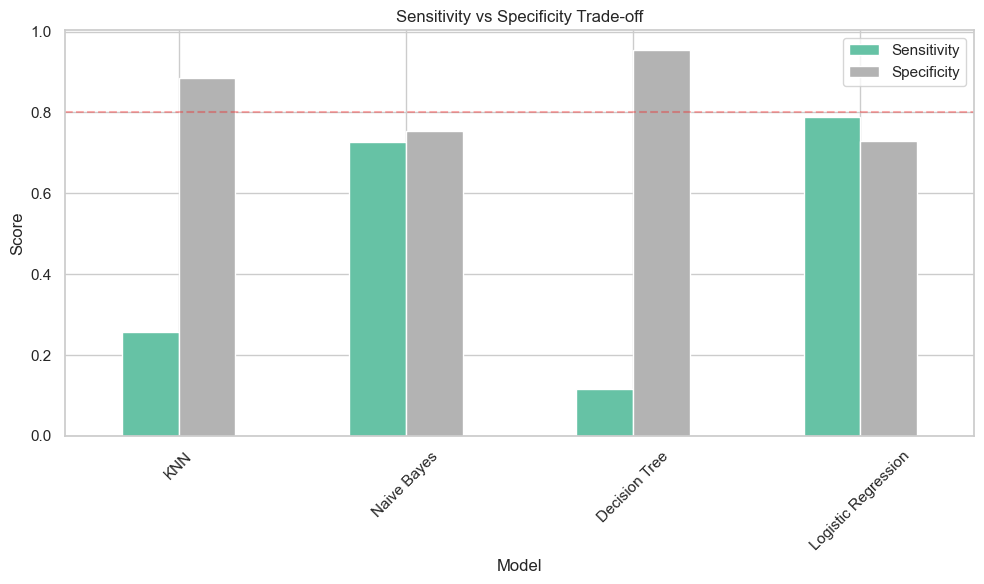

In [39]:
summary_smote_df[['Sensitivity', 'Specificity']].plot.bar(
    figsize=(10, 6), 
    rot=45, 
    title="Sensitivity vs Specificity Trade-off", 
    colormap='Set2',
)
plt.ylabel('Score')
plt.axhline(0.8, color='red', linestyle='--', alpha=0.3, label='Clinical Threshold')
plt.tight_layout()
plt.show()

### Random UnderSampling

C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\3085504520.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette=colors, ax=axes[0, 0])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\3085504520.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(["No Stroke", "Stroke"])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\3085504520.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_before_under, palette=colors, ax=axes[0, 1])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\3085504520.py:30: UserWarning: set_ticklabels() should only be used with a 

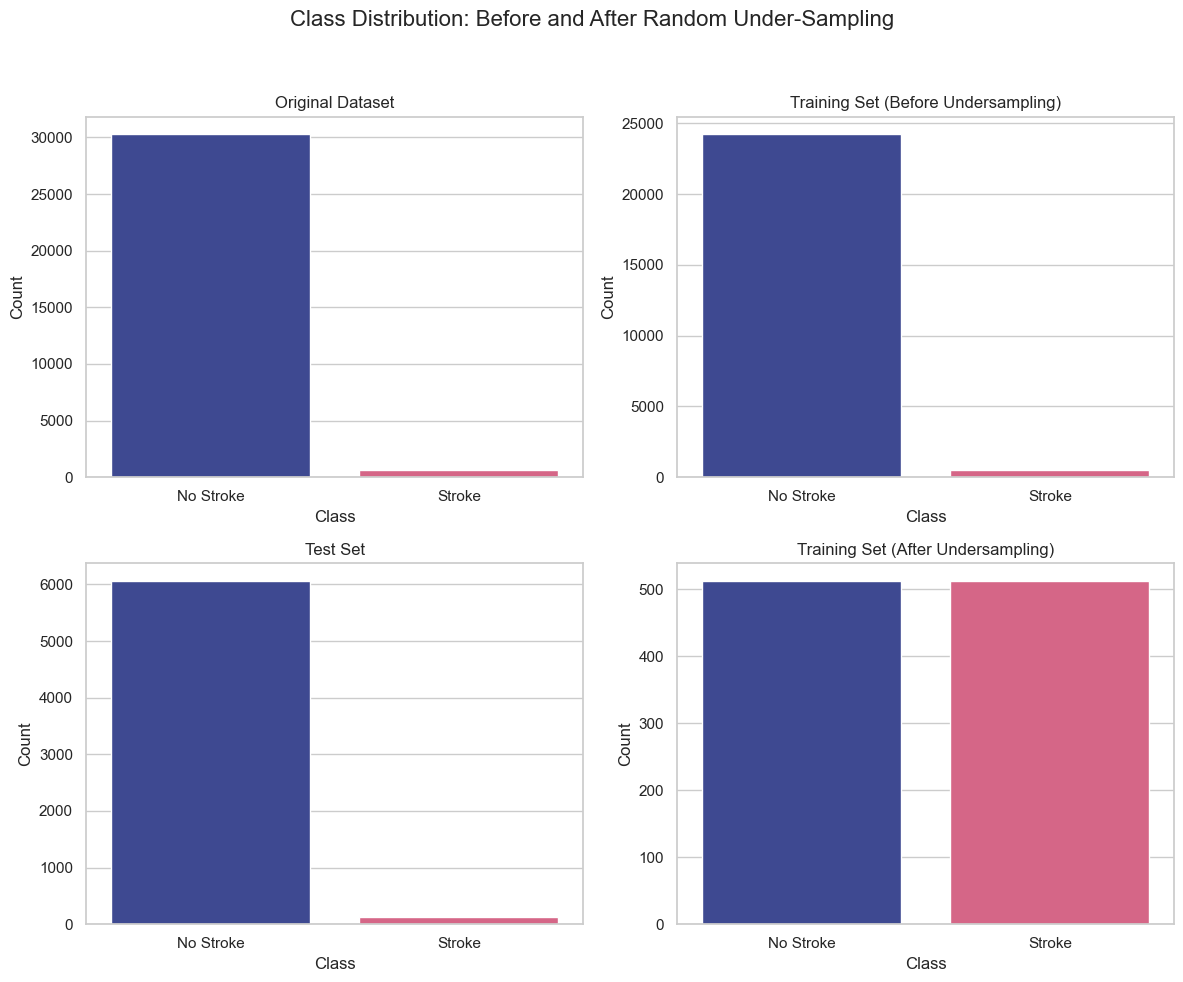


        STROKE PREDICTION MODEL COMPARISON (After Random Under-Sampling)        


,CV ROC-AUC,CV PR-AUC,Test ROC-AUC,Test PR-AUC,Sensitivity,Specificity,Precision,F1 Score
Model,,,,,,,,
KNN,0.742 ± 0.020,0.689 ± 0.020,0.764,0.132,0.789,0.674,0.049,0.091
Naive Bayes,0.790 ± 0.018,0.765 ± 0.017,0.797,0.068,0.711,0.758,0.058,0.108
Decision Tree,0.652 ± 0.024,0.590 ± 0.009,0.660,0.355,0.664,0.656,0.039,0.074
Logistic Regression,0.811 ± 0.013,0.788 ± 0.008,0.815,0.074,0.797,0.721,0.057,0.106



                                   MODEL: KNN                                   

Performance Metrics:


,Cross-Validation,Test Set
ROC-AUC,0.742 ± 0.020,0.764
PR-AUC,0.689 ± 0.020,0.132



Complete Classification Report:


...


Complete Classification Report:


,precision,recall,f1-score,support
No Stroke,0.994,0.721,0.836,6066.000
Stroke,0.057,0.797,0.106,128.000
accuracy,0.722,0.722,0.722,0.722
macro avg,0.525,0.759,0.471,6194.000
weighted avg,0.975,0.722,0.821,6194.000



Confusion Matrix:


,Predicted No Stroke,Predicted Stroke
Actual No Stroke,4372,1694
Actual Stroke,26,102



--------------------------------------------------------------------------------


In [42]:
# Step 1: Split the data
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

# Save original training labels before undersampling
X_train_before_under, y_train_before_under = X_train.copy(), y_train.copy()

# Step 2: Apply undersampling to the training set
us = RandomUnderSampler(random_state=1)
X_train_under, y_train_under = us.fit_resample(X_train_before_under, y_train_before_under)

# Visualizing class distributions
sns.set(style="whitegrid")
colors = ["#303F9F", "#E75480"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Class Distribution: Before and After Random Under-Sampling", fontsize=16)

# Plot 1: Original Dataset
sns.countplot(x=y, palette=colors, ax=axes[0, 0])
axes[0, 0].set_title("Original Dataset")
axes[0, 0].set_xlabel("Class")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_xticklabels(["No Stroke", "Stroke"])

# Plot 2: Training Set Before Undersampling
sns.countplot(x=y_train_before_under, palette=colors, ax=axes[0, 1])
axes[0, 1].set_title("Training Set (Before Undersampling)")
axes[0, 1].set_xlabel("Class")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_xticklabels(["No Stroke", "Stroke"])

# Plot 3: Test Set
sns.countplot(x=y_test, palette=colors, ax=axes[1, 0])
axes[1, 0].set_title("Test Set")
axes[1, 0].set_xlabel("Class")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_xticklabels(["No Stroke", "Stroke"])

# Plot 4: Training Set After Undersampling
sns.countplot(x=y_train_under, palette=colors, ax=axes[1, 1])
axes[1, 1].set_title("Training Set (After Undersampling)")
axes[1, 1].set_xlabel("Class")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_xticklabels(["No Stroke", "Stroke"])

# Layout adjustment
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Initialize models
models = {
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression()
}

# Initialize a dictionary to store results
results_under = {}

# Train and evaluate each model
for name, model in models.items():
    # ---- Full Training ----
    model.fit(X_train_under, y_train_under)
    
    # ---- Test Evaluation ----
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for PR-AUC and ROC-AUC
    
    # ---- Metrics ----
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    sensitivity = recall_score(y_test, y_pred)
    specificity = confusion_matrix(y_test, y_pred)[0, 0] / (confusion_matrix(y_test, y_pred)[0, 0] + confusion_matrix(y_test, y_pred)[0, 1])

    # Cross-validation for ROC-AUC and PR-AUC
    cv = StratifiedKFold(n_splits=5)
    cv_roc_auc = cross_val_score(model, X_train_under, y_train_under, cv=cv, scoring='roc_auc')
    cv_pr_auc = cross_val_score(model, X_train_under, y_train_under, cv=cv, scoring='average_precision')
    
    # ---- Store Results ----
    results_under[name] = {
        "CV ROC-AUC Mean": np.mean(cv_roc_auc),
        "CV ROC-AUC Std": np.std(cv_roc_auc),
        "CV PR-AUC Mean": np.mean(cv_pr_auc),
        "CV PR-AUC Std": np.std(cv_pr_auc),
        "Test ROC-AUC": roc_auc_score(y_test, y_prob),
        "Test PR-AUC": pr_auc,
        "Sensitivity (Recall)": sensitivity,
        "Specificity": specificity,
        "Precision": precision_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
        "Classification Report": classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke'], output_dict=True),
        "Model": model
    }

# Create a summary DataFrame for metrics comparison
summary_under_data = []
for name, result in results_under.items():
    summary_under_data.append({
        "Model": name,
        "CV ROC-AUC": f"{result['CV ROC-AUC Mean']:.3f} ± {result['CV ROC-AUC Std']:.3f}",
        "CV PR-AUC": f"{result['CV PR-AUC Mean']:.3f} ± {result['CV PR-AUC Std']:.3f}",
        "Test ROC-AUC": f"{result['Test ROC-AUC']:.3f}",
        "Test PR-AUC": f"{result['Test PR-AUC']:.3f}",
        "Sensitivity": f"{result['Sensitivity (Recall)']:.3f}",
        "Specificity": f"{result['Specificity']:.3f}",
        "Precision": f"{result['Precision']:.3f}",
        "F1 Score": f"{result['F1 Score']:.3f}"
    })

summary_under_df = pd.DataFrame(summary_under_data)
summary_under_df = summary_under_df.set_index("Model")

# Display the results
print("\n" + "="*80)
print("STROKE PREDICTION MODEL COMPARISON (After Random Under-Sampling)".center(80))
print("="*80)

# Display the summary table
display(summary_under_df.style
       .set_caption("Model Performance Summary (After Random Under-Sampling)")
       .set_properties(**{'text-align': 'center'})
       .highlight_max(subset=["Test PR-AUC", "Sensitivity","Precision"], color='lightgreen')
       .highlight_min(subset=["Test PR-AUC", "Sensitivity","Precision"], color='lightcoral')
       .format(precision=3))

# Display detailed results for each model
for name, result in results_under.items():
    print("\n" + "="*80)
    print(f"MODEL: {name.upper()}".center(80))
    print("="*80)
    
    # Metrics
    metrics_under_df = pd.DataFrame({
        "Cross-Validation": [
            f"{result['CV ROC-AUC Mean']:.3f} ± {result['CV ROC-AUC Std']:.3f}",
            f"{result['CV PR-AUC Mean']:.3f} ± {result['CV PR-AUC Std']:.3f}"
        ],
        "Test Set": [
            f"{result['Test ROC-AUC']:.3f}",
            f"{result['Test PR-AUC']:.3f}"
        ]
    }, index=["ROC-AUC", "PR-AUC"])
    
    print("\nPerformance Metrics:")
    display(metrics_under_df.style.set_properties(**{'text-align': 'center'}))
    
    # Classification metrics
    print("\nComplete Classification Report:")
    cr_df = pd.DataFrame(result['Classification Report']).transpose()
    display(cr_df.style.format("{:.3f}").set_properties(**{'text-align': 'center'}))
    
    # Confusion matrix
    cm_df = pd.DataFrame(
        result['Confusion Matrix'],
        index=['Actual No Stroke', 'Actual Stroke'],
        columns=['Predicted No Stroke', 'Predicted Stroke']
    )
    
    print("\nConfusion Matrix:")
    display(cm_df.style.set_properties(**{'text-align': 'center'}))
    
    print("\n" + "-"*80)

### Visualise Undersampling

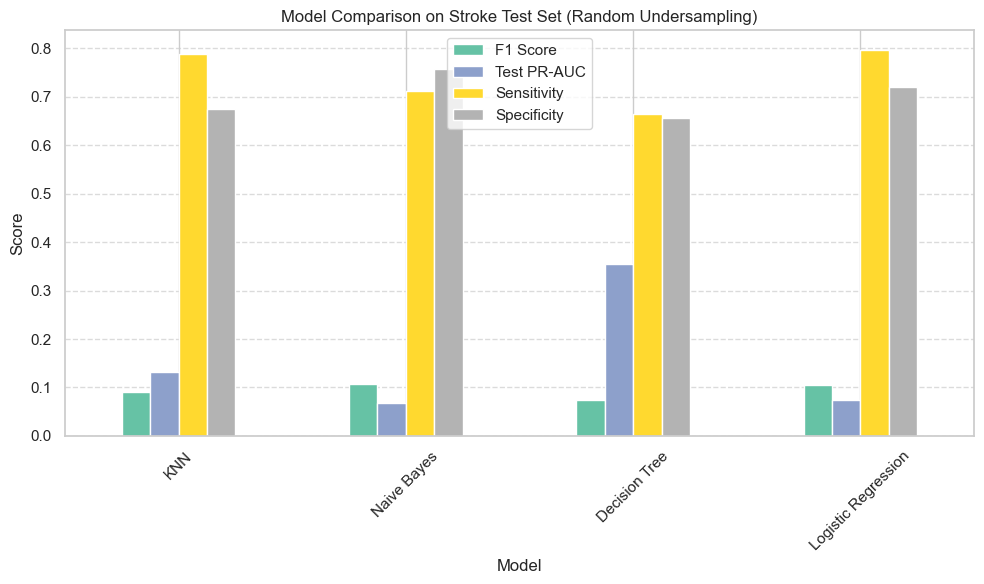

In [44]:
summary_under_df[['F1 Score', 'Test PR-AUC', 'Sensitivity', 'Specificity']] = \
    summary_under_df[['F1 Score', 'Test PR-AUC', 'Sensitivity', 'Specificity']].apply(pd.to_numeric, errors='coerce')

# Plot
summary_under_df[['F1 Score', 'Test PR-AUC', 'Sensitivity', 'Specificity']].plot.bar(
    figsize=(10, 6), 
    rot=45, 
    title="Model Comparison on Stroke Test Set (Random Undersampling)", 
    colormap='Set2',
)
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

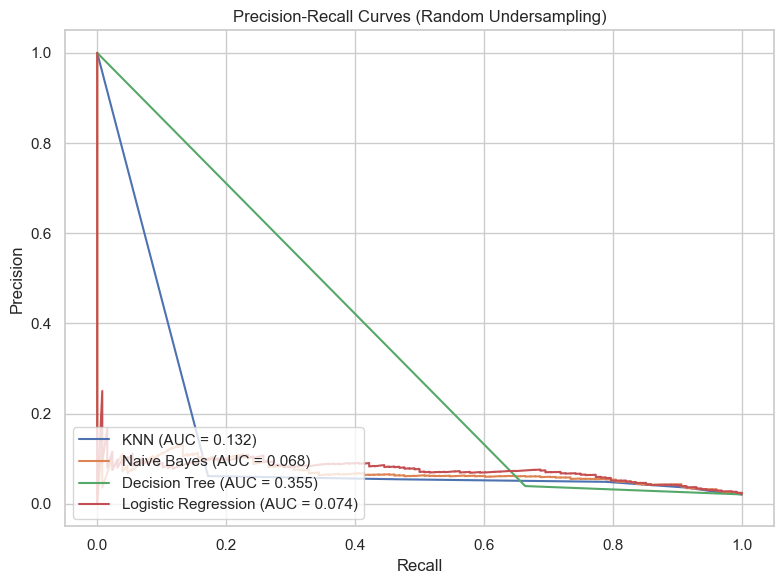

In [45]:
plt.figure(figsize=(8, 6))

for name, result in results_under.items():
    model = result["Model"]
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Random Undersampling)")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()

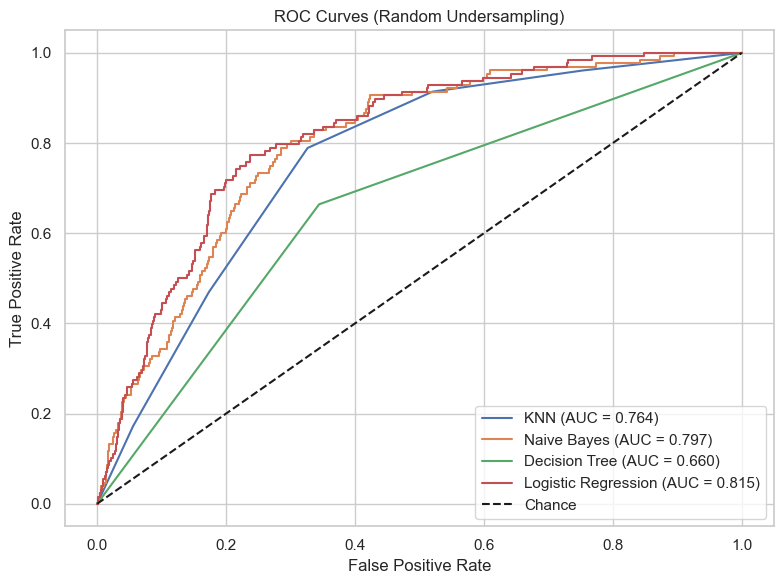

In [46]:
plt.figure(figsize=(8, 6))

for name, result in results_under.items():
    model = result["Model"]
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Random Undersampling)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

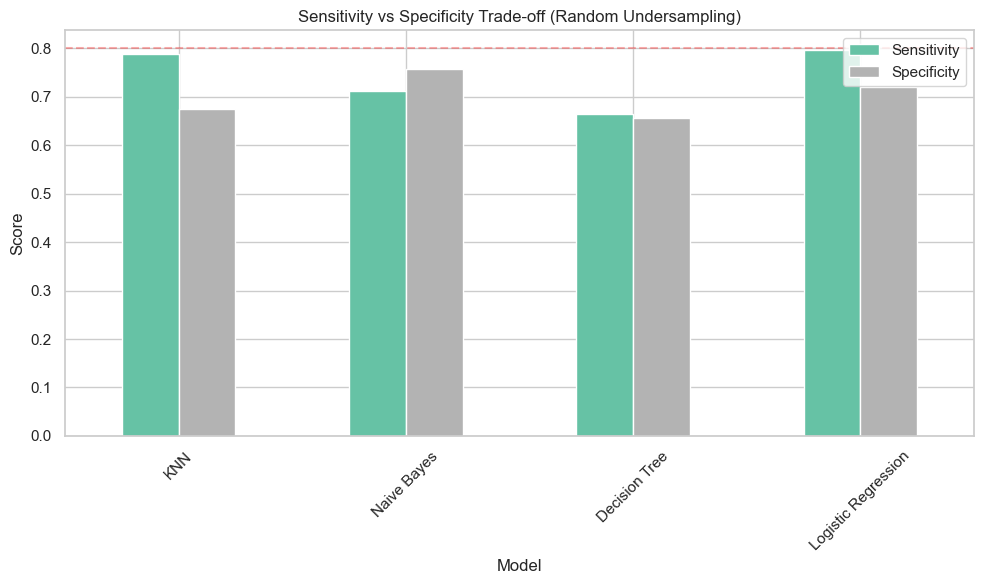

In [895]:
summary_under_df[['Sensitivity', 'Specificity']].plot.bar(
    figsize=(10, 6), 
    rot=45, 
    title="Sensitivity vs Specificity Trade-off (Random Undersampling)", 
    colormap='Set2',
)
plt.ylabel('Score')
plt.axhline(0.8, color='red', linestyle='--', alpha=0.3, label='Clinical Threshold')
plt.tight_layout()
plt.show()

### Compare Results

In [905]:
def extract_results(results_dict, sampling_name):
    data = []
    for model_name, metrics in results_dict.items():
        data.append({
            "Sampling": sampling_name,
            "Model": model_name,
            "Test ROC-AUC": round(metrics["Test ROC-AUC"], 3),
            "Test PR-AUC": round(metrics["Test PR-AUC"], 3),
            "Sensitivity": round(metrics["Sensitivity (Recall)"], 3),
            "Specificity": round(metrics["Specificity"], 3),
            "Precision": round(metrics["Precision"], 3),
            "F1 Score": round(metrics["F1 Score"], 3)
        })
    return data

# Combine results from each sampling strategy
all_results = (
    extract_results(results_under, "Under-Sampling") +
    extract_results(results_smote, "SMOTE") +
    extract_results(results_smoteenn, "SMOTEENN")
)

# Create comparison DataFrame
comparison_df = pd.DataFrame(all_results)

# Optional: sort by Test PR-AUC or any other metric
comparison_df = comparison_df.sort_values(by=["Sampling", "F1 Score"], ascending=[True, False])

# Display comparison
display(comparison_df.style.set_caption("Model Performance Comparison Across Sampling Strategies")
        .highlight_max(subset=["Test PR-AUC", "Sensitivity", "Precision", "F1 Score"], color='lightgreen')
        .highlight_min(subset=["Test PR-AUC", "Sensitivity", "Precision", "F1 Score"], color='lightcoral')
        .set_properties(**{'text-align': 'center'})
)

,Sampling,Model,Test ROC-AUC,Test PR-AUC,Sensitivity,Specificity,Precision,F1 Score
5,SMOTE,Naive Bayes,0.791000,0.066000,0.727000,0.755000,0.059000,0.109000
7,SMOTE,Logistic Regression,0.815000,0.077000,0.789000,0.730000,0.058000,0.108000
4,SMOTE,KNN,0.608000,0.091000,0.258000,0.884000,0.045000,0.076000
6,SMOTE,Decision Tree,0.536000,0.094000,0.117000,0.955000,0.052000,0.072000
9,SMOTEENN,Naive Bayes,0.793000,0.066000,0.742000,0.749000,0.059000,0.109000
11,SMOTEENN,Logistic Regression,0.816000,0.078000,0.805000,0.703000,0.054000,0.101000
10,SMOTEENN,Decision Tree,0.552000,0.122000,0.180000,0.924000,0.048000,0.076000
8,SMOTEENN,KNN,0.630000,0.144000,0.320000,0.848000,0.042000,0.075000
1,Under-Sampling,Naive Bayes,0.797000,0.068000,0.711000,0.758000,0.058000,0.108000
3,Under-Sampling,Logistic Regression,0.815000,0.074000,0.797000,0.721000,0.057000,0.106000


### Model Stability Across CV Folds


----- Cross-Validation ROC-AUC Stability (Fold-wise) -----
Model                Fold ROC-AUCs                  Std Dev   
------------------------------------------------------------
KNN                  [0.973 0.974 0.971 0.974 0.972] 0.001     
Naive Bayes          [0.804 0.811 0.803 0.807 0.807] 0.003     
Decision Tree        [0.939 0.963 0.963 0.964 0.963] 0.010     
Logistic Regression  [0.826 0.826 0.823 0.82  0.822] 0.002     


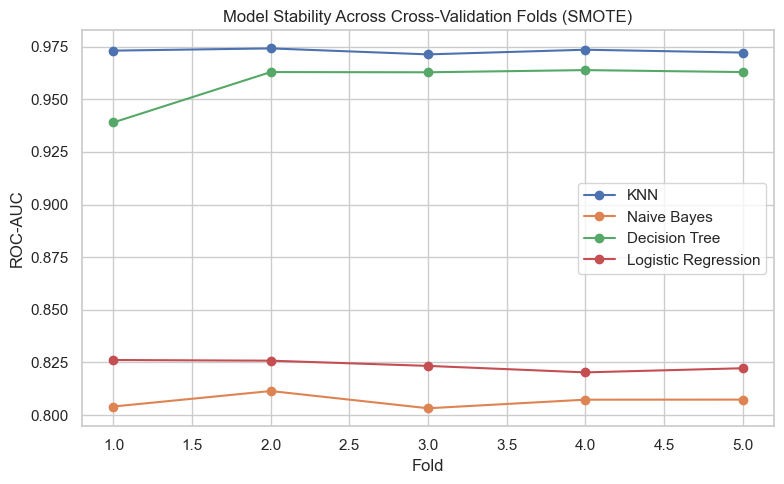

In [58]:
print("\n----- Cross-Validation ROC-AUC Stability (Fold-wise) -----")
print(f"{'Model':<20} {'Fold ROC-AUCs':<30} {'Std Dev':<10}")
print("-" * 60)

plt.figure(figsize=(8, 5))

for name, model in models.items():
    # Perform cross-validation and get ROC-AUC scores for each fold
    fold_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring='roc_auc', n_jobs=-1)
    results_smote[name]["CV ROC Std"] = np.std(fold_scores)
    
    # Display fold ROC-AUCs and standard deviation for each model
    print(f"{name:<20} {str(fold_scores.round(3)):<30} {np.std(fold_scores):<10.3f}")
    
    # Plot ROC-AUC for each fold
    plt.plot(range(1, 6), fold_scores, marker='o', label=name)

# Plot customization
plt.xlabel("Fold")
plt.ylabel("ROC-AUC")
plt.title("Model Stability Across Cross-Validation Folds (SMOTE)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Model                Fold ROC-AUCs                  Std Dev   
------------------------------------------------------------
KNN                  [0.712 0.766 0.762 0.736 0.735] 0.020     
Naive Bayes          [0.791 0.803 0.815 0.765 0.775] 0.018     
Decision Tree        [0.65  0.639 0.668 0.658 0.629] 0.014     
Logistic Regression  [0.823 0.82  0.812 0.812 0.787] 0.013     


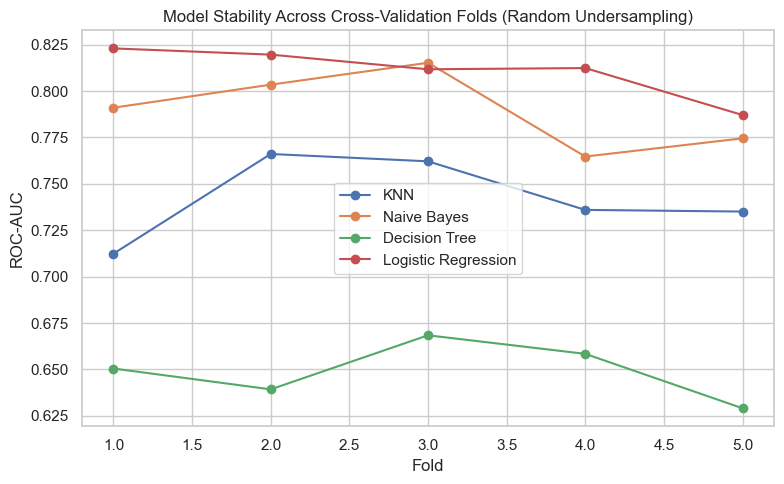

In [59]:
print(f"{'Model':<20} {'Fold ROC-AUCs':<30} {'Std Dev':<10}")
print("-" * 60)

plt.figure(figsize=(8, 5))

for name, model in models.items():
    # Perform cross-validation and get ROC-AUC scores for each fold
    fold_scores = cross_val_score(model, X_train_under, y_train_under, cv=cv, scoring='roc_auc', n_jobs=-1)
    results_under[name]["CV ROC Std"] = np.std(fold_scores)
    
    # Display fold ROC-AUCs and standard deviation for each model
    print(f"{name:<20} {str(fold_scores.round(3)):<30} {np.std(fold_scores):<10.3f}")
    
    # Plot ROC-AUC for each fold
    plt.plot(range(1, 6), fold_scores, marker='o', label=name)

# Plot customization
plt.xlabel("Fold")
plt.ylabel("ROC-AUC")
plt.title("Model Stability Across Cross-Validation Folds (Random Undersampling)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


----- Cross-Validation ROC-AUC Stability (Fold-wise) -----
Model                Fold ROC-AUCs                  Std Dev   
------------------------------------------------------------
KNN                  [0.997 0.997 0.997 0.997 0.998] 0.000     
Naive Bayes          [0.84  0.849 0.838 0.844 0.845] 0.004     
Decision Tree        [0.951 0.974 0.967 0.971 0.966] 0.008     
Logistic Regression  [0.865 0.865 0.861 0.857 0.863] 0.003     


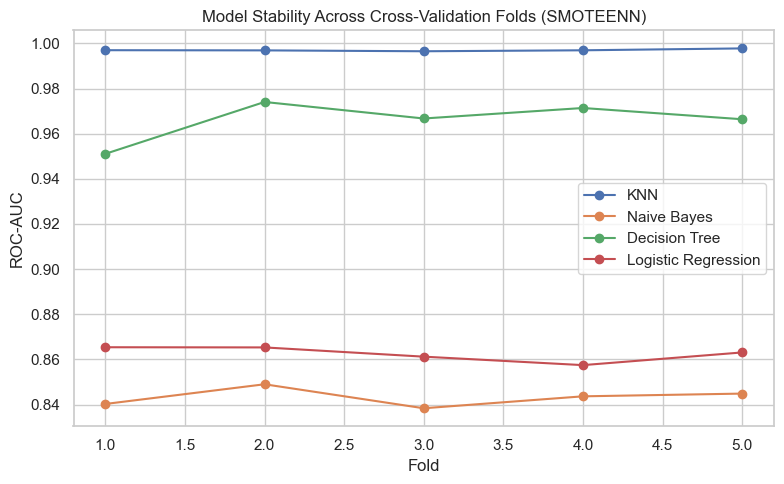

In [60]:
print("\n----- Cross-Validation ROC-AUC Stability (Fold-wise) -----")
print(f"{'Model':<20} {'Fold ROC-AUCs':<30} {'Std Dev':<10}")
print("-" * 60)

plt.figure(figsize=(8, 5))

for name, model in models.items():
    # Perform cross-validation and get ROC-AUC scores for each fold
    fold_scores = cross_val_score(model, X_train_smoteenn, y_train_smoteenn, cv=cv, scoring='roc_auc', n_jobs=-1)
    results_smoteenn[name]["CV ROC Std"] = np.std(fold_scores)
    
    # Display fold ROC-AUCs and standard deviation for each model
    print(f"{name:<20} {str(fold_scores.round(3)):<30} {np.std(fold_scores):<10.3f}")
    
    # Plot ROC-AUC for each fold
    plt.plot(range(1, 6), fold_scores, marker='o', label=name)

# Plot customization
plt.xlabel("Fold")
plt.ylabel("ROC-AUC")
plt.title("Model Stability Across Cross-Validation Folds (SMOTEENN)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Task 3
### Analyze significant patterns and influencing factors.   

### SMOTEENN Models

C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\3006444625.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perm_knn_df[:10], y=perm_knn_df.index[:10], palette='magma')


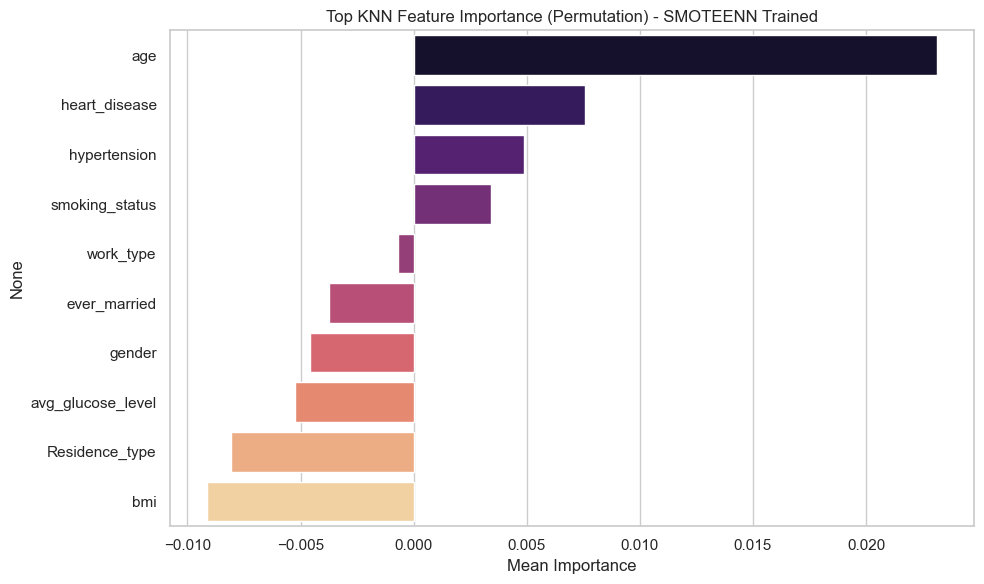

C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\3006444625.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dt_imp[:10], y=dt_imp.index[:10], palette='Blues')


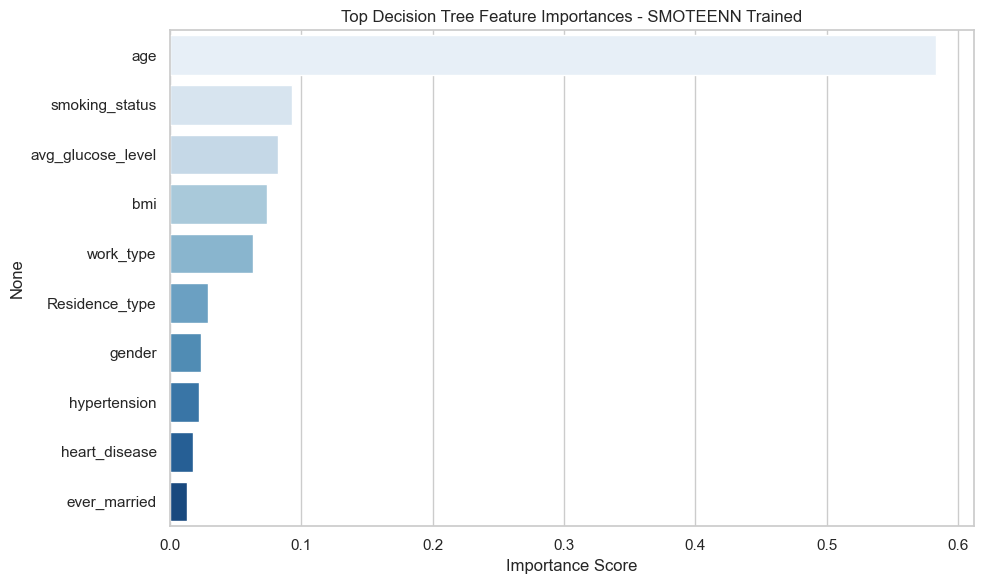

C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\3006444625.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perm_nb_df[:10], y=perm_nb_df.index[:10], palette='rocket')


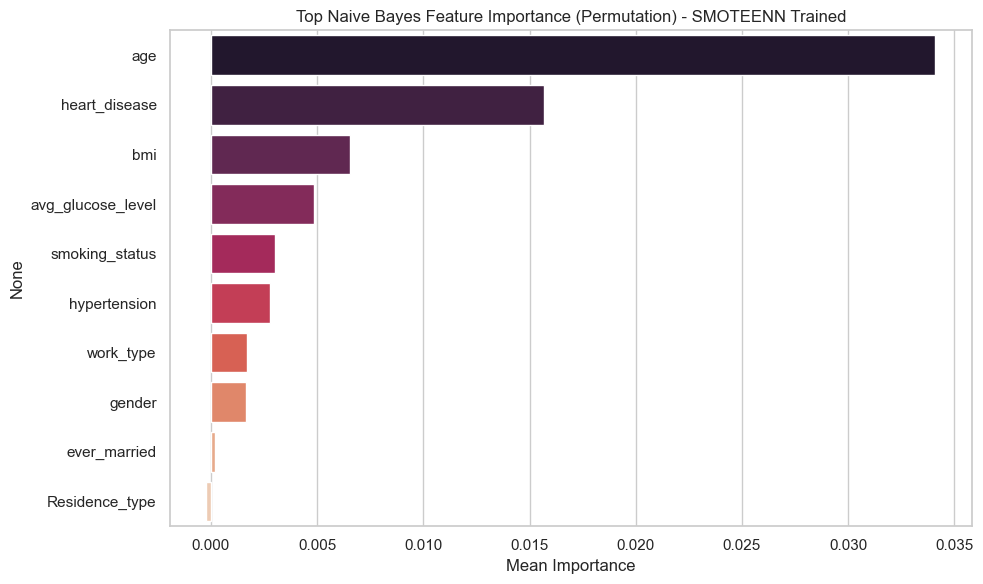

C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\3006444625.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=log_imp[:10], y=log_imp.index[:10], palette='plasma')


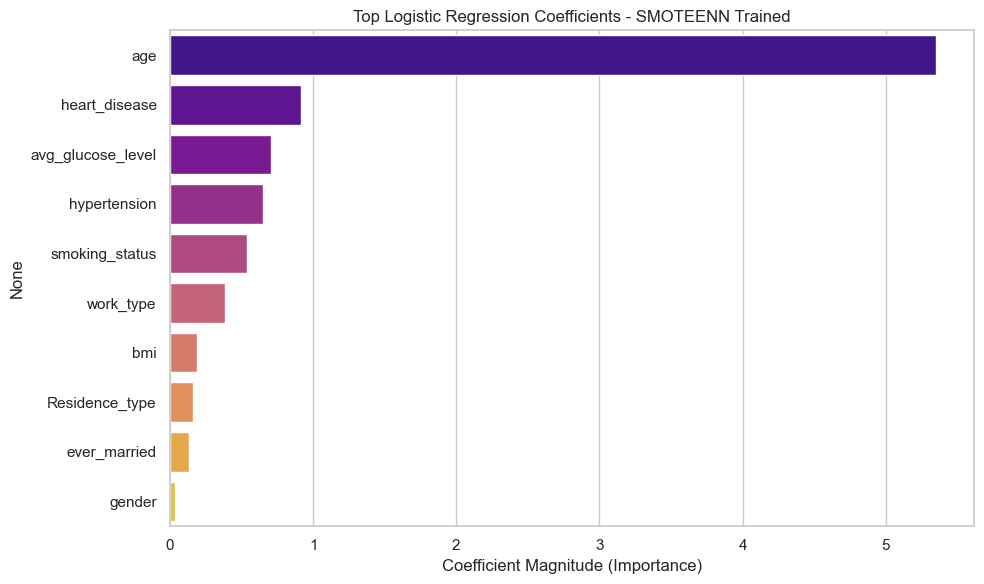

In [346]:
# --- 1. KNN – Permutation Importance ---
knn_model = results_smoteenn["KNN"]["Model"]
perm_knn = permutation_importance(knn_model, X_test, y_test, scoring='f1', n_repeats=5, random_state=42)
perm_knn_df = pd.Series(perm_knn.importances_mean, index=X_test.columns).sort_values(ascending=False)
# Plot KNN Permutation Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=perm_knn_df[:10], y=perm_knn_df.index[:10], palette='magma')
plt.title("Top KNN Feature Importance (Permutation) - SMOTEENN Trained")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.show()

# --- 2. Decision Tree – Feature Importance ---
dt_model = results_smoteenn["Decision Tree"]["Model"]
dt_imp = pd.Series(dt_model.feature_importances_, index=X_test.columns).sort_values(ascending=False)
# Plot Decision Tree Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=dt_imp[:10], y=dt_imp.index[:10], palette='Blues')
plt.title("Top Decision Tree Feature Importances - SMOTEENN Trained")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# --- 3. Naive Bayes – Permutation Importance (no native feature importance) ---
nb_model = results_smoteenn["Naive Bayes"]["Model"]
perm_nb = permutation_importance(nb_model, X_test, y_test, scoring='f1', n_repeats=5, random_state=42)
perm_nb_df = pd.Series(perm_nb.importances_mean, index=X_test.columns).sort_values(ascending=False)
# Plot Naive Bayes Permutation Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=perm_nb_df[:10], y=perm_nb_df.index[:10], palette='rocket')
plt.title("Top Naive Bayes Feature Importance (Permutation) - SMOTEENN Trained")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.show()

# --- 4. Logistic Regression – Feature Importance ---
log_model = results_smoteenn["Logistic Regression"]["Model"]
log_imp = pd.Series(abs(log_model.coef_[0]), index=X_test.columns).sort_values(ascending=False)
# Plot Logistic Regression Coefficient Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=log_imp[:10], y=log_imp.index[:10], palette='plasma')
plt.title("Top Logistic Regression Coefficients - SMOTEENN Trained")
plt.xlabel("Coefficient Magnitude (Importance)")
plt.tight_layout()
plt.show()


C:\Users\ziyan\AppData\Local\Temp\ipykernel_35308\798344862.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_importance_sorted[:10], y=mean_importance_sorted.index[:10], palette="coolwarm")


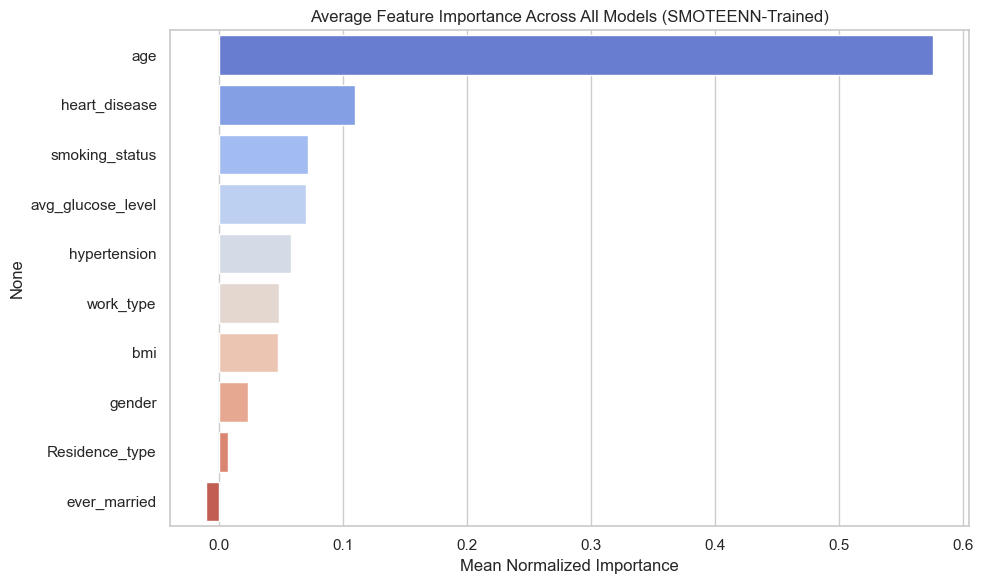

In [64]:
# Combine feature importances into a DataFrame
importance_df = pd.DataFrame({
    "KNN": perm_knn_df,
    "Decision Tree": dt_imp,
    "Naive Bayes": perm_nb_df,
    "Logistic Regression": log_imp
})

# Normalize each model's importance scores so they are comparable
importance_df_normalized = importance_df.div(importance_df.sum())

# Calculate the average importance
importance_df_normalized['Mean Importance'] = importance_df_normalized.mean(axis=1)

# Sort by average importance
mean_importance_sorted = importance_df_normalized['Mean Importance'].sort_values(ascending=False)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x=mean_importance_sorted[:10], y=mean_importance_sorted.index[:10], palette="coolwarm")
plt.title("Average Feature Importance Across All Models (SMOTEENN-Trained)")
plt.xlabel("Mean Normalized Importance")
plt.tight_layout()
plt.show()


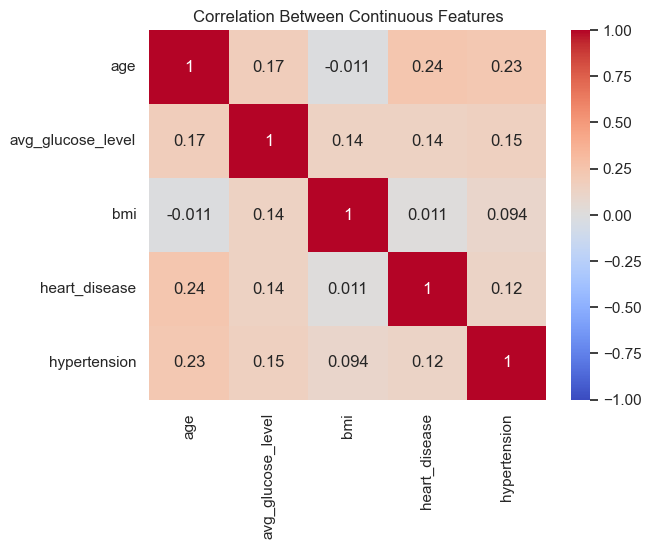

In [65]:
continuous_data = X_test[['age','avg_glucose_level', 'bmi','heart_disease','hypertension']]
corr = continuous_data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Between Continuous Features")
plt.show()

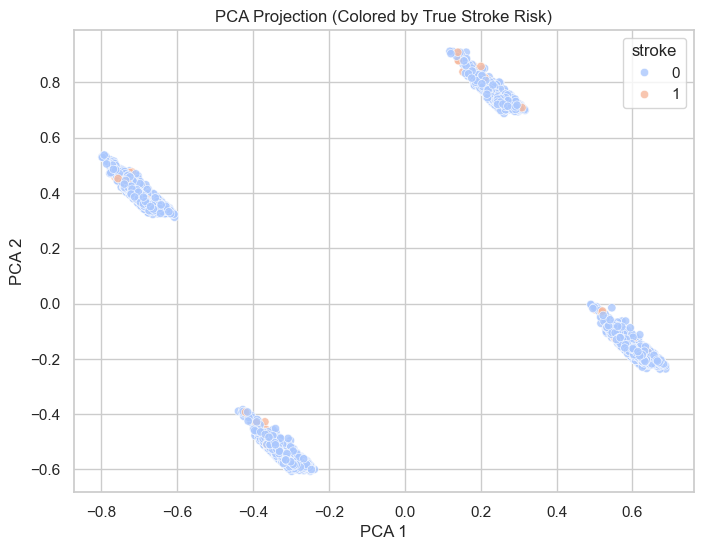

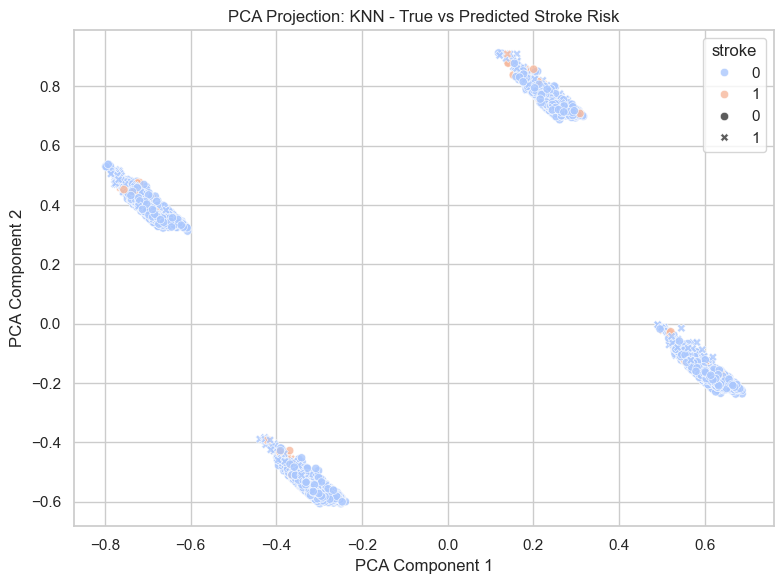

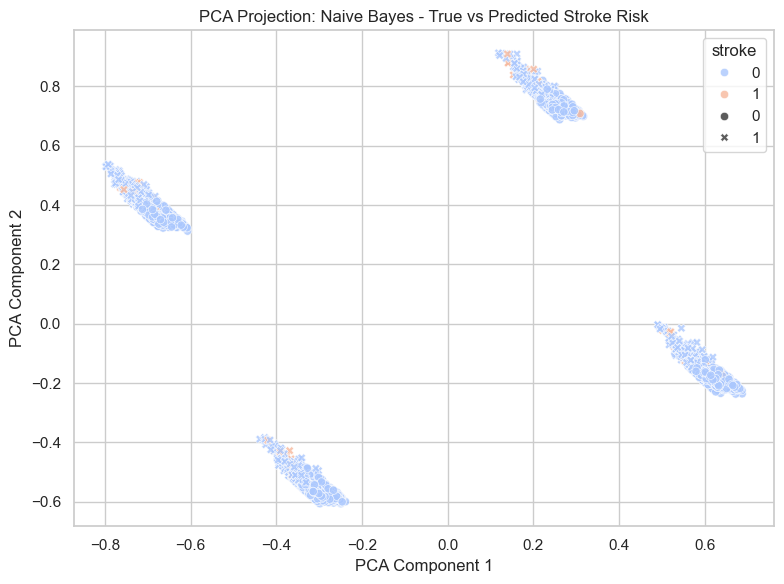

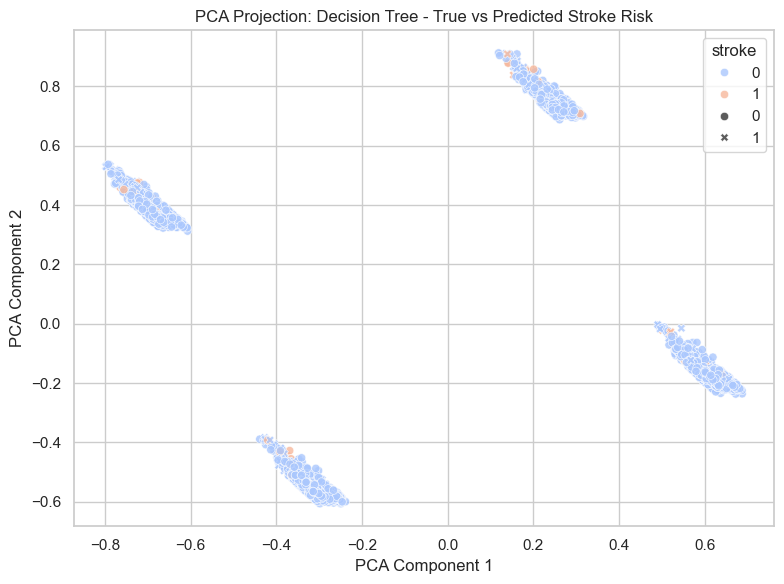

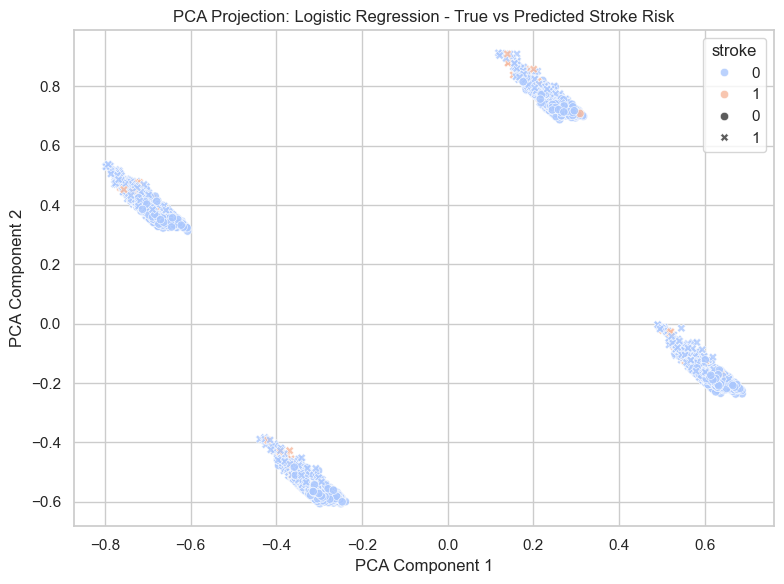

In [66]:
# Apply PCA once
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)

# Plot PCA projection colored by true labels
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_test, palette="coolwarm", alpha=0.8)
plt.title("PCA Projection (Colored by True Stroke Risk)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# Loop through each model and show predictions on the same PCA projection
for name, info in results_smoteenn.items():
    model = info["Model"]
    preds = model.predict(X_test)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                    hue=y_test, style=preds, palette='coolwarm', alpha=0.8)
    plt.title(f"PCA Projection: {name} - True vs Predicted Stroke Risk")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.tight_layout()
    plt.show()


## Task 4
### Examine types of errors or inefficiencies.   
###### -Investigate incorrect predictions, inconsistencies in identified patterns, or inefficiencies in decision-making.   
###### -Evaluate generalization ability, adaptability, and potential biases affecting learning outcomes.   
###### -Assess areas where improvements can be made through better representations, enhanced exploration, or refined adjustments.

### Investigating Incorrect Predictions

#### False Positives (Type I Error)& False Negatives (Type II Error)


Model: KNN
Confusion Matrix:
[[5142  924]
 [  87   41]]
True Negatives: 5142, False Positives: 924, False Negatives: 87, True Positives: 41

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.98      0.85      0.91      6066
      Stroke       0.04      0.32      0.08       128

    accuracy                           0.84      6194
   macro avg       0.51      0.58      0.49      6194
weighted avg       0.96      0.84      0.89      6194



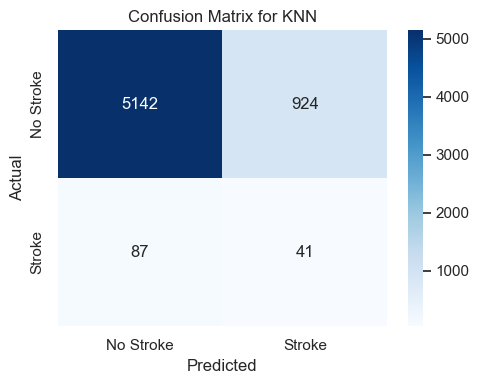


Model: Naive Bayes
Confusion Matrix:
[[4541 1525]
 [  33   95]]
True Negatives: 4541, False Positives: 1525, False Negatives: 33, True Positives: 95

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.99      0.75      0.85      6066
      Stroke       0.06      0.74      0.11       128

    accuracy                           0.75      6194
   macro avg       0.53      0.75      0.48      6194
weighted avg       0.97      0.75      0.84      6194



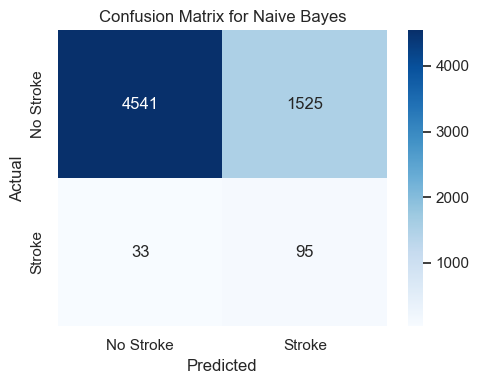


Model: Decision Tree
Confusion Matrix:
[[5598  468]
 [ 105   23]]
True Negatives: 5598, False Positives: 468, False Negatives: 105, True Positives: 23

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.98      0.92      0.95      6066
      Stroke       0.05      0.18      0.07       128

    accuracy                           0.91      6194
   macro avg       0.51      0.55      0.51      6194
weighted avg       0.96      0.91      0.93      6194



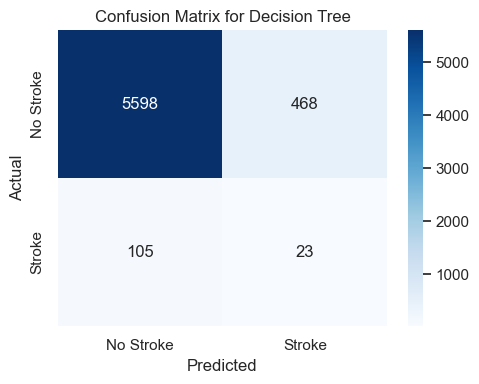


Model: Logistic Regression
Confusion Matrix:
[[4263 1803]
 [  25  103]]
True Negatives: 4263, False Positives: 1803, False Negatives: 25, True Positives: 103

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.99      0.70      0.82      6066
      Stroke       0.05      0.80      0.10       128

    accuracy                           0.70      6194
   macro avg       0.52      0.75      0.46      6194
weighted avg       0.97      0.70      0.81      6194



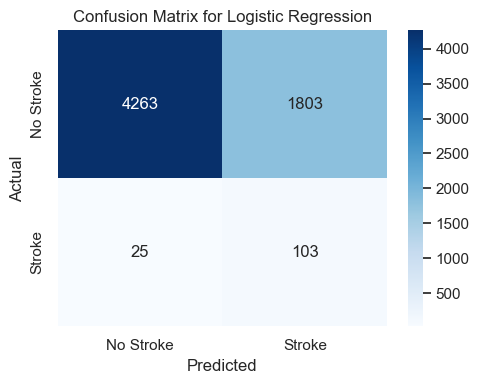

In [70]:
for name, info in results_smoteenn.items():
    model = info["Model"]
    preds = model.predict(X_test)

    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()

    print(f"\nModel: {name}")
    print("Confusion Matrix:")
    print(cm)
    print(f"True Negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True Positives: {tp}")
    print("\nClassification Report:")
    print(classification_report(y_test, preds, target_names=['No Stroke', 'Stroke']))

    # Visualizing confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
    plt.title(f"Confusion Matrix for {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

### Evaluate Generalization Ability

#### Compare CV Scores vs Test Score

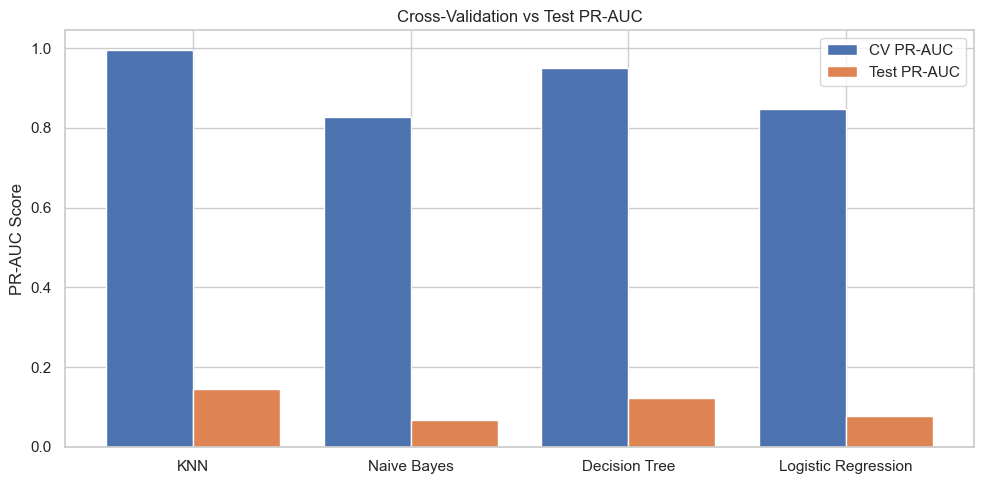

In [73]:
cv_means = [np.mean(cross_val_score(model, X_train_smoteenn, y_train_smoteenn, cv=cv, 
                                    scoring='average_precision')) for model in models.values()]
test_scores = [results_smoteenn[name]["Test PR-AUC"] for name in models]

plt.figure(figsize=(10, 5))
x = np.arange(len(models))
plt.bar(x - 0.2, cv_means, width=0.4, label='CV PR-AUC')
plt.bar(x + 0.2, test_scores, width=0.4, label='Test PR-AUC')
plt.xticks(x, models.keys())
plt.ylabel("PR-AUC Score")
plt.title("Cross-Validation vs Test PR-AUC")
plt.legend()
plt.tight_layout()
plt.show()

### Evaluate Adaptability

#### Different Data Variantions: Original,Missing Imputed,Outliers

In [95]:
adaptability_results = []
def evaluate_generalization(model, X_train_smoteenn, y_train_smoteenn, X_test, y_test, model_name="Model"):
    print("\n==============================================================")
    print(f"Generalization Report for: {model_name}")
    print("==============================================================")
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Cross-validation scores
    roc_auc_cv = cross_val_score(model, X_train_smoteenn, y_train_smoteenn, cv=cv, scoring='roc_auc')
    pr_auc_cv = cross_val_score(model, X_train_smoteenn, y_train_smoteenn, cv=cv, scoring='average_precision')
    
    print(f"Cross-Validation Scores (5-Fold):")
    print(f"  ROC-AUC: Mean = {roc_auc_cv.mean():.4f}, Std = {roc_auc_cv.std():.4f}")
    print(f"  PR-AUC : Mean = {pr_auc_cv.mean():.4f}, Std = {pr_auc_cv.std():.4f}")
    
    # Fit the model
    model.fit(X_train_smoteenn, y_train_smoteenn)
    
    # Test scores
    y_proba = model.predict_proba(X_test)[:, 1]
    roc_auc_test = roc_auc_score(y_test, y_proba)
    pr_auc_test = average_precision_score(y_test, y_proba)
    
    print(f"\nTest Set Scores:")
    print(f"  ROC-AUC: {roc_auc_test:.4f}")
    print(f"  PR-AUC : {pr_auc_test:.4f}")
    
    # Generalization gap
    print(f"\nGeneralization Gap (CV Mean - Test):")
    print(f"  ROC-AUC Gap: {roc_auc_cv.mean() - roc_auc_test:.4f}")
    print(f"  PR-AUC  Gap: {pr_auc_cv.mean() - pr_auc_test:.4f}")

    adaptability_results.append({
            "Model": model_name.split(" (")[0],
            "Variant": model_name.split(" (")[1].replace(")", ""),
            "ROC-AUC": roc_auc_test,
            "PR-AUC": pr_auc_test
        })

In [97]:
 # Create test variations
def create_test_variants(X_test):
    # Missing values
    X_missing = X_test.copy()
    X_missing.iloc[0:10, 0] = np.nan
    imputer = SimpleImputer(strategy='mean')
    X_missing_imputed = imputer.fit_transform(X_missing)

    # Outliers
    X_outliers = X_test.copy()
    X_outliers.iloc[0:5] = X_outliers.iloc[0:5] * 10

    return {
        "Original": X_test,
        "Missing Imputed": X_missing_imputed,
        "Outliers": X_outliers
    }

# Evaluate all models
def evaluate_all_models_adaptability(models, X_train, y_train, X_test, y_test):
    X_test_variants = create_test_variants(X_test)

    for variant_name, X_variant in X_test_variants.items():
        print(f"\nAdaptability Test: {variant_name}")
        for name, model in models.items():
            model_pipeline = model

            # Apply RobustScaler for KNN and Logistic Regression
            if name in ["KNN", "Logistic Regression"]:
                model_pipeline = make_pipeline(RobustScaler(), model)

            # Evaluate
            evaluate_generalization(model_pipeline, X_train, y_train, X_variant, y_test, model_name=f"{name} ({variant_name})")
            
# Define models dictionary
models = {
    "KNN": knn_model,
    "Naive Bayes": nb_model,
    "Decision Tree": dt_model,
    "Logistic Regression":log_model
}

# Run adaptability check
evaluate_all_models_adaptability(models, X_train_smoteenn, y_train_smoteenn, X_test, y_test)


Adaptability Test: Original

Generalization Report for: KNN (Original)
Cross-Validation Scores (5-Fold):
  ROC-AUC: Mean = 0.9951, Std = 0.0005
  PR-AUC : Mean = 0.9915, Std = 0.0009

Test Set Scores:
  ROC-AUC: 0.6477
  PR-AUC : 0.0372

Generalization Gap (CV Mean - Test):
  ROC-AUC Gap: 0.3474
  PR-AUC  Gap: 0.9542

Generalization Report for: Naive Bayes (Original)
Cross-Validation Scores (5-Fold):
  ROC-AUC: Mean = 0.8432, Std = 0.0041
  PR-AUC : Mean = 0.8274, Std = 0.0054

Test Set Scores:
  ROC-AUC: 0.7932
  PR-AUC : 0.0678

Generalization Gap (CV Mean - Test):
  ROC-AUC Gap: 0.0499
  PR-AUC  Gap: 0.7596

Generalization Report for: Decision Tree (Original)
Cross-Validation Scores (5-Fold):
  ROC-AUC: Mean = 0.9642, Std = 0.0022
  PR-AUC : Mean = 0.9478, Std = 0.0035

Test Set Scores:
  ROC-AUC: 0.5461
  PR-AUC : 0.0246

Generalization Gap (CV Mean - Test):
  ROC-AUC Gap: 0.4181
  PR-AUC  Gap: 0.9232

Generalization Report for: Logistic Regression (Original)
Cross-Validation Scor

C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(



Test Set Scores:
  ROC-AUC: 0.6477
  PR-AUC : 0.0372

Generalization Gap (CV Mean - Test):
  ROC-AUC Gap: 0.3474
  PR-AUC  Gap: 0.9542

Generalization Report for: Naive Bayes (Missing Imputed)
Cross-Validation Scores (5-Fold):
  ROC-AUC: Mean = 0.8432, Std = 0.0041
  PR-AUC : Mean = 0.8274, Std = 0.0054

Test Set Scores:
  ROC-AUC: 0.7932
  PR-AUC : 0.0677

Generalization Gap (CV Mean - Test):
  ROC-AUC Gap: 0.0499
  PR-AUC  Gap: 0.7596

Generalization Report for: Decision Tree (Missing Imputed)


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


Cross-Validation Scores (5-Fold):
  ROC-AUC: Mean = 0.9642, Std = 0.0020
  PR-AUC : Mean = 0.9484, Std = 0.0045


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



Test Set Scores:
  ROC-AUC: 0.5521
  PR-AUC : 0.0255

Generalization Gap (CV Mean - Test):
  ROC-AUC Gap: 0.4122
  PR-AUC  Gap: 0.9229

Generalization Report for: Logistic Regression (Missing Imputed)
Cross-Validation Scores (5-Fold):
  ROC-AUC: Mean = 0.8624, Std = 0.0034
  PR-AUC : Mean = 0.8475, Std = 0.0029

Test Set Scores:
  ROC-AUC: 0.8158
  PR-AUC : 0.0799

Generalization Gap (CV Mean - Test):
  ROC-AUC Gap: 0.0467
  PR-AUC  Gap: 0.7676

Adaptability Test: Outliers

Generalization Report for: KNN (Outliers)


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(


Cross-Validation Scores (5-Fold):
  ROC-AUC: Mean = 0.9951, Std = 0.0005
  PR-AUC : Mean = 0.9915, Std = 0.0009

Test Set Scores:
  ROC-AUC: 0.6478
  PR-AUC : 0.0373

Generalization Gap (CV Mean - Test):
  ROC-AUC Gap: 0.3472
  PR-AUC  Gap: 0.9542

Generalization Report for: Naive Bayes (Outliers)
Cross-Validation Scores (5-Fold):
  ROC-AUC: Mean = 0.8432, Std = 0.0041
  PR-AUC : Mean = 0.8274, Std = 0.0054

Test Set Scores:
  ROC-AUC: 0.7935
  PR-AUC : 0.0678

Generalization Gap (CV Mean - Test):
  ROC-AUC Gap: 0.0497
  PR-AUC  Gap: 0.7596

Generalization Report for: Decision Tree (Outliers)
Cross-Validation Scores (5-Fold):
  ROC-AUC: Mean = 0.9639, Std = 0.0027
  PR-AUC : Mean = 0.9488, Std = 0.0028

Test Set Scores:
  ROC-AUC: 0.5590
  PR-AUC : 0.0265

Generalization Gap (CV Mean - Test):
  ROC-AUC Gap: 0.4049
  PR-AUC  Gap: 0.9223

Generalization Report for: Logistic Regression (Outliers)
Cross-Validation Scores (5-Fold):
  ROC-AUC: Mean = 0.8624, Std = 0.0034
  PR-AUC : Mean = 0.

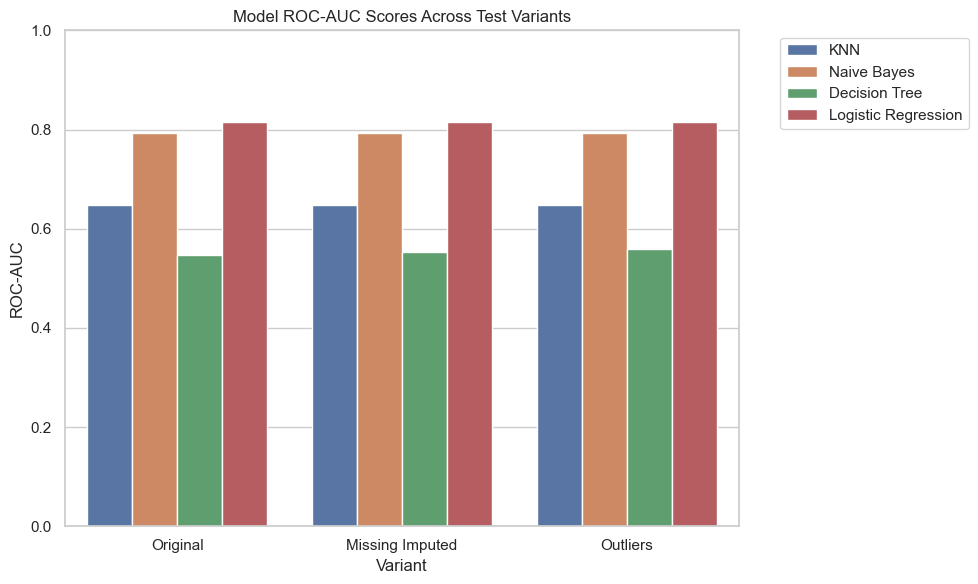

In [1549]:
df_adapt = pd.DataFrame(adaptability_results)

# Plot ROC-AUC
plt.figure(figsize=(10, 6))
sns.barplot(data=df_adapt, x="Variant", y="ROC-AUC", hue="Model")
plt.title("Model ROC-AUC Scores Across Test Variants")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


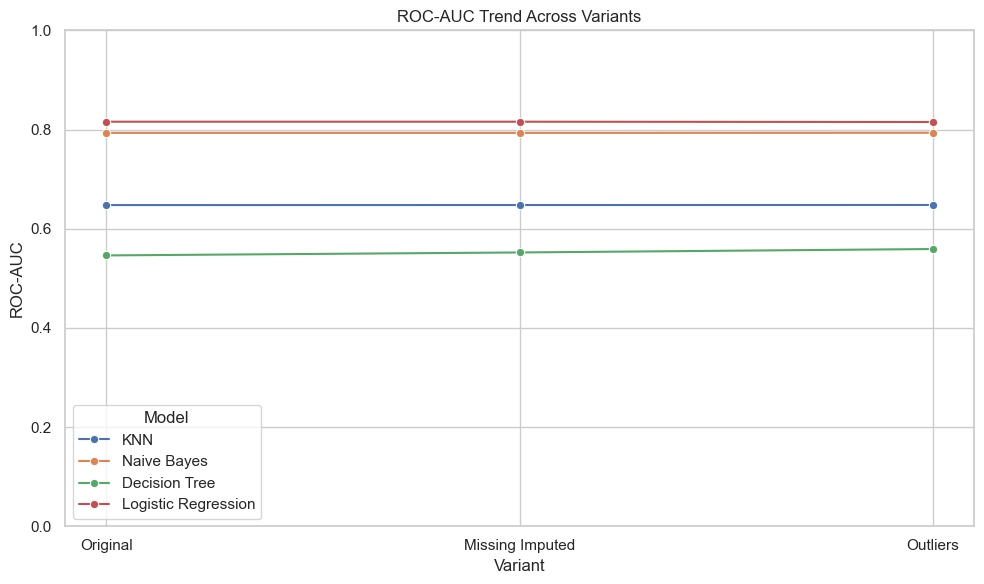

In [103]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_adapt, x="Variant", y="ROC-AUC", hue="Model", marker='o')
plt.title("ROC-AUC Trend Across Variants")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Potential Bias

#### Class Imbalance Bias

In [110]:
y.value_counts(normalize=True)

stroke
0    0.979301
1    0.020699
Name: proportion, dtype: float64

#### Bias Checks (Precision, Recall, F1 Score, Calibration)

In [1657]:
def check_bias_by_group(model, X_test, y_test, sensitive_feature):
    print(f"\nBias Check for: {model.__class__.__name__}")
    
    for group in X_test[sensitive_feature].unique():
        idx = X_test[sensitive_feature] == group
        y_true = y_test[idx]
        y_pred = model.predict(X_test[idx])
        y_prob = model.predict_proba(X_test[idx])[:, 1]
        
        # Precision, Recall, F1 Score by Group
        print(f"\nGroup {group} ({sensitive_feature}):")
        print(f"Precision: {precision_score(y_true, y_pred):.4f}")
        print(f"Recall/Sensitivity: {recall_score(y_true, y_pred):.4f}")
        print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
        
        # ROC-AUC by Group
        print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
        
        # Calibration Curve by Group
        prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
        plt.plot(prob_pred, prob_true, label=f'Group {group}')
    
    # Plot Calibration Curve for all groups
    plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
    plt.legend()
    plt.title(f'Calibration Curves by {sensitive_feature}')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Observed Frequency')
    plt.grid(True)
    plt.show()


--- Bias Check for KNN by gender ---

Bias Check for: KNeighborsClassifier


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(



Group 0.0 (gender):
Precision: 0.0171
Recall/Sensitivity: 0.7241
F1 Score: 0.0334
ROC-AUC: 0.5348


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(



Group 1.0 (gender):
Precision: 0.0378
Recall/Sensitivity: 0.4714
F1 Score: 0.0700
ROC-AUC: 0.5738


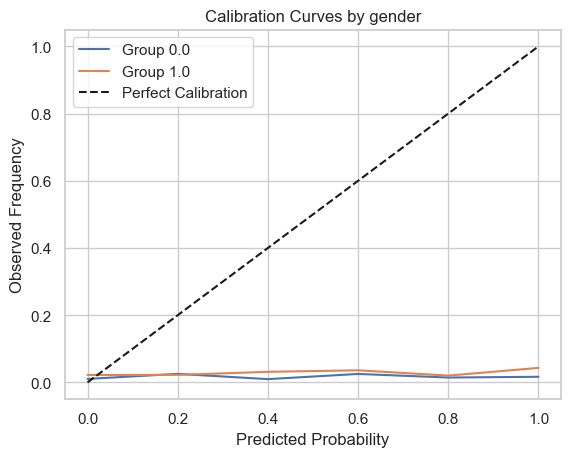


--- Bias Check for KNN by smoking_status ---

Bias Check for: KNeighborsClassifier


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(



Group 0.6666666666666666 (smoking_status):
Precision: 0.0214
Recall/Sensitivity: 0.6400
F1 Score: 0.0415
ROC-AUC: 0.5360


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(



Group 0.3333333333333333 (smoking_status):
Precision: 0.0219
Recall/Sensitivity: 0.6250
F1 Score: 0.0423
ROC-AUC: 0.4725


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(



Group 1.0 (smoking_status):
Precision: 0.0440
Recall/Sensitivity: 0.3333
F1 Score: 0.0777
ROC-AUC: 0.6424


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(



Group 0.0 (smoking_status):
Precision: 0.0202
Recall/Sensitivity: 0.6818
F1 Score: 0.0393
ROC-AUC: 0.5180


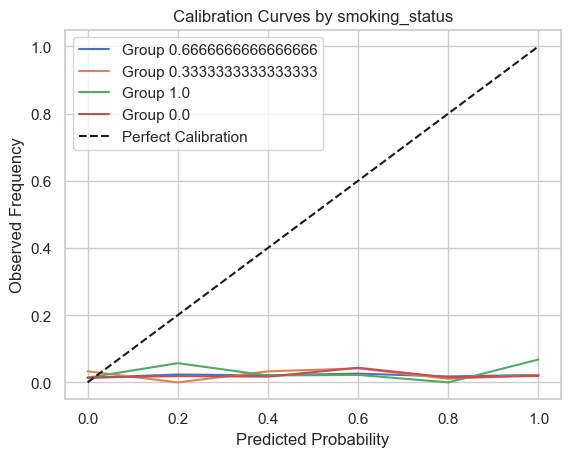


--- Bias Check for KNN by ever_married ---

Bias Check for: KNeighborsClassifier


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(



Group 1.0 (ever_married):
Precision: 0.0230
Recall/Sensitivity: 0.5752
F1 Score: 0.0442
ROC-AUC: 0.5280


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(



Group 0.0 (ever_married):
Precision: 0.0200
Recall/Sensitivity: 0.6667
F1 Score: 0.0388
ROC-AUC: 0.5827


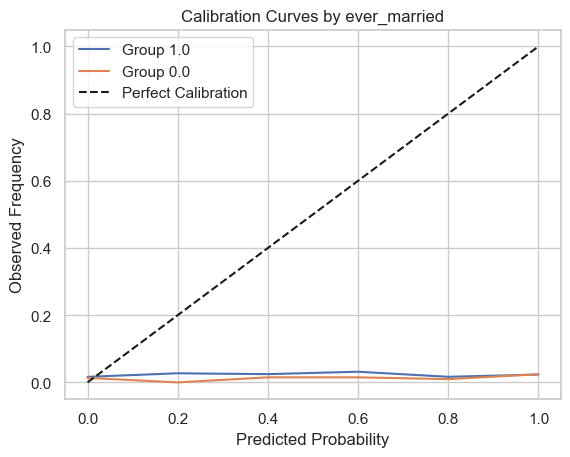


--- Bias Check for KNN by Residence_type ---

Bias Check for: KNeighborsClassifier


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(



Group 1.0 (Residence_type):
Precision: 0.0227
Recall/Sensitivity: 0.5672
F1 Score: 0.0437
ROC-AUC: 0.5308


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(



Group 0.0 (Residence_type):
Precision: 0.0223
Recall/Sensitivity: 0.6066
F1 Score: 0.0430
ROC-AUC: 0.5389


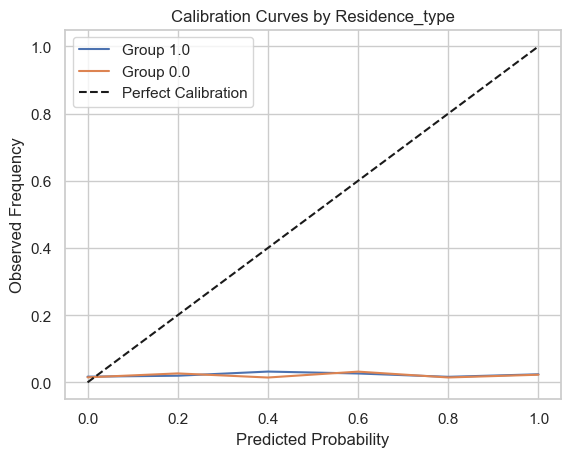


--- Bias Check for Naive Bayes by gender ---

Bias Check for: GaussianNB

Group 0.0 (gender):
Precision: 0.0511
Recall/Sensitivity: 0.7759
F1 Score: 0.0959
ROC-AUC: 0.8376

Group 1.0 (gender):
Precision: 0.0676
Recall/Sensitivity: 0.7143
F1 Score: 0.1235
ROC-AUC: 0.7394


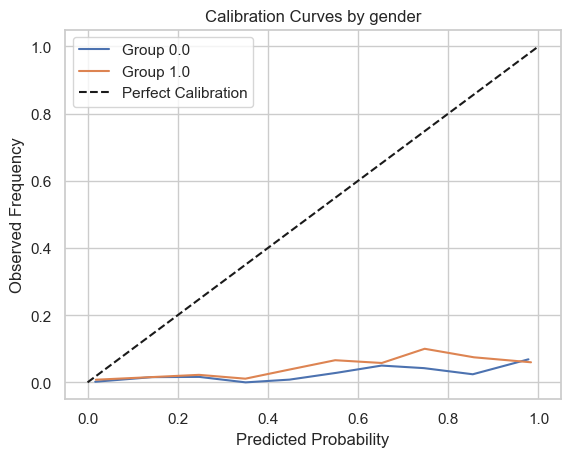


--- Bias Check for Naive Bayes by smoking_status ---

Bias Check for: GaussianNB

Group 0.6666666666666666 (smoking_status):
Precision: 0.0549
Recall/Sensitivity: 0.7200
F1 Score: 0.1020
ROC-AUC: 0.7679

Group 0.3333333333333333 (smoking_status):
Precision: 0.0530
Recall/Sensitivity: 0.8438
F1 Score: 0.0998
ROC-AUC: 0.8118

Group 1.0 (smoking_status):
Precision: 0.0705
Recall/Sensitivity: 0.6667
F1 Score: 0.1275
ROC-AUC: 0.7822

Group 0.0 (smoking_status):
Precision: 0.0702
Recall/Sensitivity: 0.7273
F1 Score: 0.1280
ROC-AUC: 0.8313


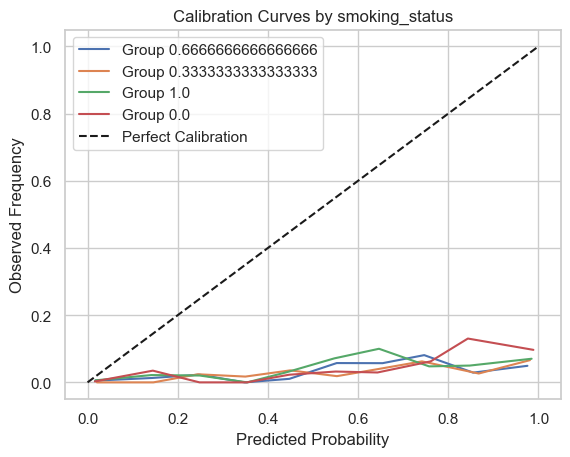


--- Bias Check for Naive Bayes by ever_married ---

Bias Check for: GaussianNB

Group 1.0 (ever_married):
Precision: 0.0565
Recall/Sensitivity: 0.7876
F1 Score: 0.1054
ROC-AUC: 0.7895

Group 0.0 (ever_married):
Precision: 0.1364
Recall/Sensitivity: 0.4000
F1 Score: 0.2034
ROC-AUC: 0.8658


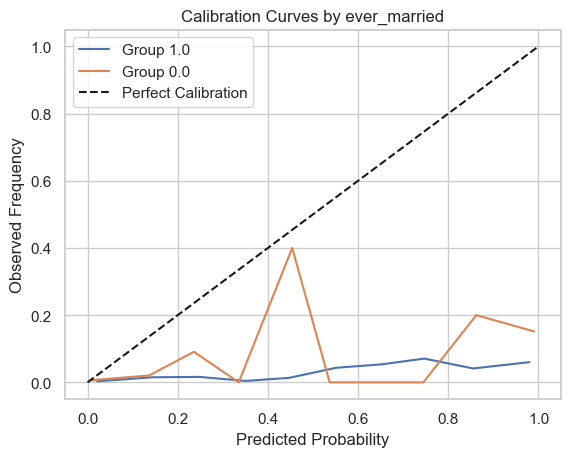


--- Bias Check for Naive Bayes by Residence_type ---

Bias Check for: GaussianNB

Group 1.0 (Residence_type):
Precision: 0.0630
Recall/Sensitivity: 0.7313
F1 Score: 0.1160
ROC-AUC: 0.7876

Group 0.0 (Residence_type):
Precision: 0.0546
Recall/Sensitivity: 0.7541
F1 Score: 0.1019
ROC-AUC: 0.8003


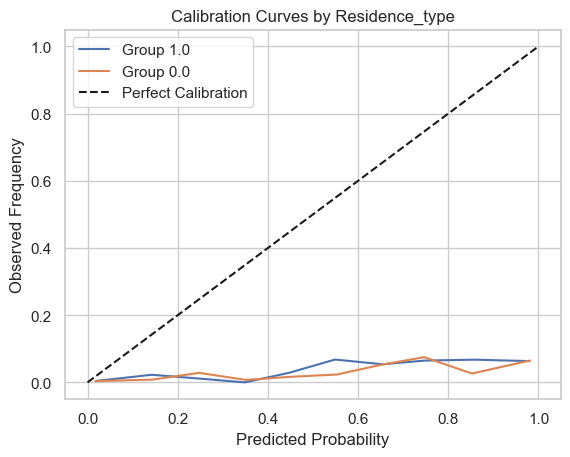


--- Bias Check for Decision Tree by gender ---

Bias Check for: DecisionTreeClassifier

Group 0.0 (gender):
Precision: 0.0346
Recall/Sensitivity: 0.1724
F1 Score: 0.0576
ROC-AUC: 0.5489

Group 1.0 (gender):
Precision: 0.0725
Recall/Sensitivity: 0.2143
F1 Score: 0.1083
ROC-AUC: 0.5659


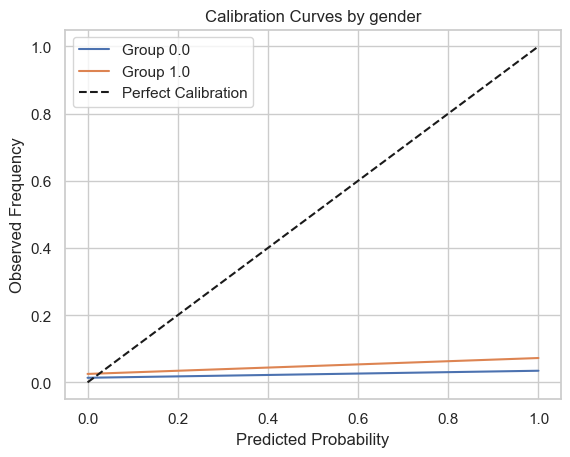


--- Bias Check for Decision Tree by smoking_status ---

Bias Check for: DecisionTreeClassifier

Group 0.6666666666666666 (smoking_status):
Precision: 0.0534
Recall/Sensitivity: 0.2200
F1 Score: 0.0859
ROC-AUC: 0.5713

Group 0.3333333333333333 (smoking_status):
Precision: 0.0458
Recall/Sensitivity: 0.1875
F1 Score: 0.0736
ROC-AUC: 0.5466

Group 1.0 (smoking_status):
Precision: 0.0370
Recall/Sensitivity: 0.1250
F1 Score: 0.0571
ROC-AUC: 0.5259

Group 0.0 (smoking_status):
Precision: 0.0641
Recall/Sensitivity: 0.2273
F1 Score: 0.1000
ROC-AUC: 0.5821


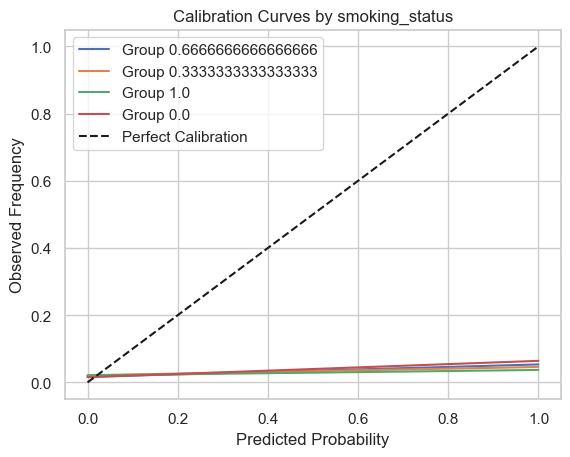


--- Bias Check for Decision Tree by ever_married ---

Bias Check for: DecisionTreeClassifier

Group 1.0 (ever_married):
Precision: 0.0464
Recall/Sensitivity: 0.1858
F1 Score: 0.0742
ROC-AUC: 0.5510

Group 0.0 (ever_married):
Precision: 0.0930
Recall/Sensitivity: 0.2667
F1 Score: 0.1379
ROC-AUC: 0.6119


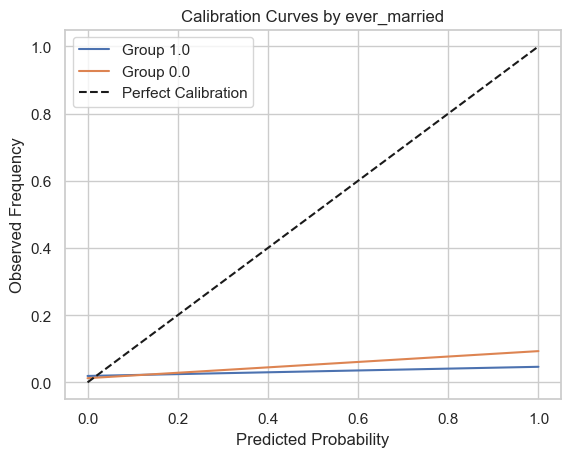


--- Bias Check for Decision Tree by Residence_type ---

Bias Check for: DecisionTreeClassifier

Group 1.0 (Residence_type):
Precision: 0.0560
Recall/Sensitivity: 0.2090
F1 Score: 0.0883
ROC-AUC: 0.5655

Group 0.0 (Residence_type):
Precision: 0.0447
Recall/Sensitivity: 0.1803
F1 Score: 0.0717
ROC-AUC: 0.5515


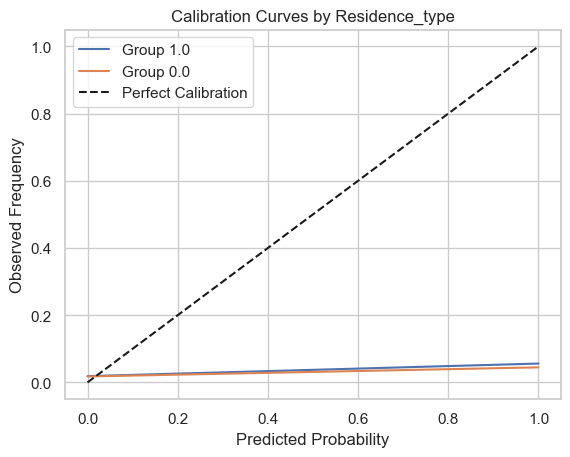


--- Bias Check for Logistic Regression by gender ---

Bias Check for: LogisticRegression

Group 0.0 (gender):
Precision: 0.0153
Recall/Sensitivity: 1.0000
F1 Score: 0.0301
ROC-AUC: 0.8629

Group 1.0 (gender):
Precision: 0.0292
Recall/Sensitivity: 1.0000
F1 Score: 0.0567
ROC-AUC: 0.7669


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


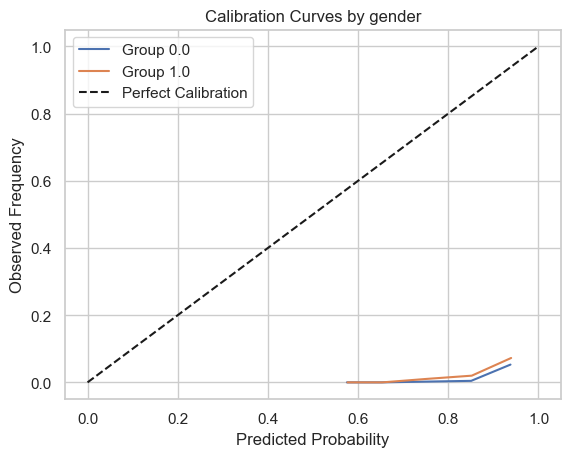


--- Bias Check for Logistic Regression by smoking_status ---

Bias Check for: LogisticRegression

Group 0.6666666666666666 (smoking_status):
Precision: 0.0195
Recall/Sensitivity: 1.0000
F1 Score: 0.0382
ROC-AUC: 0.7978

Group 0.3333333333333333 (smoking_status):
Precision: 0.0236
Recall/Sensitivity: 1.0000
F1 Score: 0.0461
ROC-AUC: 0.8227

Group 1.0 (smoking_status):
Precision: 0.0220
Recall/Sensitivity: 1.0000
F1 Score: 0.0430
ROC-AUC: 0.8035

Group 0.0 (smoking_status):
Precision: 0.0187
Recall/Sensitivity: 1.0000
F1 Score: 0.0366
ROC-AUC: 0.8508


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without featu

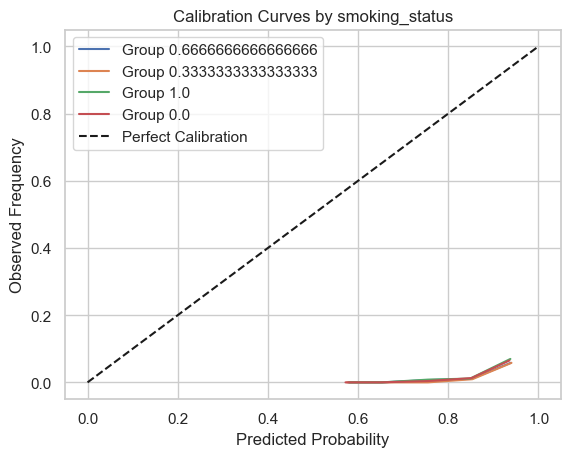


--- Bias Check for Logistic Regression by ever_married ---

Bias Check for: LogisticRegression

Group 1.0 (ever_married):
Precision: 0.0214
Recall/Sensitivity: 1.0000
F1 Score: 0.0420
ROC-AUC: 0.8022

Group 0.0 (ever_married):
Precision: 0.0162
Recall/Sensitivity: 1.0000
F1 Score: 0.0319
ROC-AUC: 0.8881


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


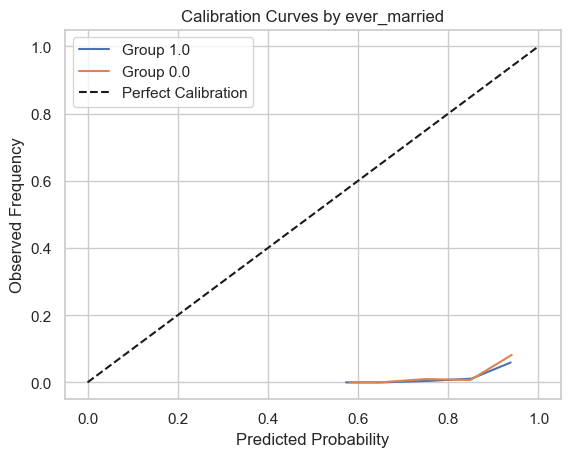


--- Bias Check for Logistic Regression by Residence_type ---

Bias Check for: LogisticRegression

Group 1.0 (Residence_type):
Precision: 0.0216
Recall/Sensitivity: 1.0000
F1 Score: 0.0424
ROC-AUC: 0.8048

Group 0.0 (Residence_type):
Precision: 0.0197
Recall/Sensitivity: 1.0000
F1 Score: 0.0386
ROC-AUC: 0.8267


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


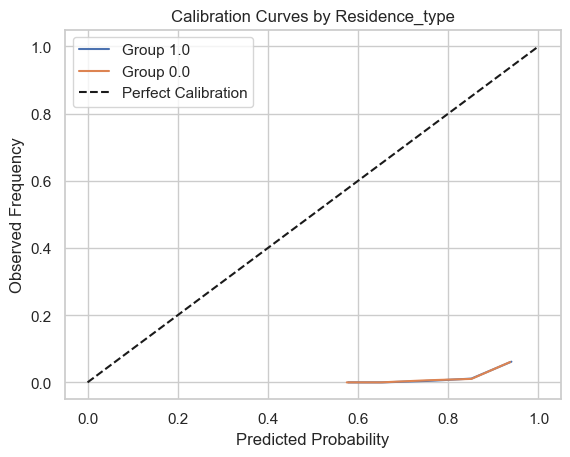

In [148]:
sensitive_features = ['gender', 'smoking_status', 'ever_married', 'Residence_type']
for model_name, model in models.items():
    for feature in sensitive_features:
        print(f"\n--- Bias Check for {model_name} by {feature} ---")
        check_bias_by_group(model, X_test, y_test, feature)

## Task 5
### Refine feature selection, data representations, and structural configurations.   
##### -Optimize information processing by transforming inputs, improving representations, or restructuring learning procedures.   
##### -Adjust learning mechanisms to ensure meaningful differentiation, adaptability, and efficiency. 

### Feature Selection Refinement 

#### ITERATION 1
#### No Feature Engineering

In [544]:
import pandas as pd
from sklearn.feature_selection import RFECV, SequentialFeatureSelector
from sklearn.model_selection import StratifiedKFold

# ==== Model-specific feature selection functions with CV ====

def apply_rfecv_feature_selection2(X_train, y_train, model, scoring='f1'):
    print(f"→ Running RFECV for {type(model).__name__} with cross-validation...")

    rfecv = RFECV(
        estimator=model,
        step=1,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring=scoring,
        n_jobs=-1
    )
    rfecv.fit(X_train, y_train)

    selected_features = X_train.columns[rfecv.support_]
    ranking = pd.Series(rfecv.ranking_, index=X_train.columns)

    return {
        'FeatureRanking': ranking.sort_values(),
        'SelectedFeatures': selected_features
    }

def apply_sfs_feature_selection2(X_train, y_train, model, n_features_to_select=10, direction='forward'):
    max_features = min(n_features_to_select, X_train.shape[1] - 1)
    print(f"→ Running SFS ({direction}) for {type(model).__name__} with {max_features} features...")

    sfs = SequentialFeatureSelector(
        estimator=model,
        n_features_to_select=max_features,
        direction=direction,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1',
        n_jobs=-1
    )
    sfs.fit(X_train, y_train)
    selected_features = X_train.columns[sfs.get_support()]

    return {
        'SelectedFeatures': selected_features
    }

def get_tree_feature_importance_cv(X_train, y_train, model, threshold=0.01, cv_splits=5):
    print(f"→ Running Tree-based Importance with CV for {type(model).__name__}...")

    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    importances = pd.DataFrame(index=X_train.columns)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_fold, y_fold = X_train.iloc[train_idx], y_train.iloc[train_idx]
        model.fit(X_fold, y_fold)
        importances[f'Fold{fold+1}'] = model.feature_importances_

    mean_importance = importances.mean(axis=1)
    selected = mean_importance[mean_importance >= threshold].sort_values(ascending=False)

    return {
        'FeatureImportance': mean_importance.sort_values(ascending=False),
        'SelectedFeatures': selected.index
    }

# ==== Main Execution ====

# Example model setup
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

# Store results
feature_selection_results2 = {}

# Loop through models and apply appropriate selection
for name, model in models.items():
    print("\n========================================")
    print(f"Feature Selection for {name}")
    print("========================================")

    if name == 'Logistic Regression':
        result = apply_rfecv_feature_selection2(X_train_smoteenn, y_train_smoteenn, model, scoring='f1')
    elif name == 'Decision Tree':
        result = get_tree_feature_importance_cv(X_train_smoteenn, y_train_smoteenn, model, threshold=0.01)
    elif name in ['KNN', 'Naive Bayes']:
        result = apply_sfs_feature_selection2(X_train_smoteenn, y_train_smoteenn, model, n_features_to_select=10)

    feature_selection_results2[name] = result

    # Output results
    print("\nSelected Features:")
    print(result['SelectedFeatures'].tolist())

    if 'FeatureRanking' in result:
        print("\nFeature Ranking:")
        print(result['FeatureRanking'])

    if 'FeatureImportance' in result:
        print("\nFeature Importances:")
        print(result['FeatureImportance'])



Feature Selection for Logistic Regression
→ Running RFECV for LogisticRegression with cross-validation...

Selected Features:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']

Feature Ranking:
gender               1
age                  1
hypertension         1
heart_disease        1
ever_married         1
work_type            1
Residence_type       1
avg_glucose_level    1
bmi                  1
smoking_status       1
dtype: int32

Feature Selection for Decision Tree
→ Running Tree-based Importance with CV for DecisionTreeClassifier...

Selected Features:
['age', 'smoking_status', 'avg_glucose_level', 'bmi', 'work_type', 'Residence_type', 'gender', 'hypertension', 'heart_disease', 'ever_married']

Feature Importances:
age                  0.528713
smoking_status       0.108522
avg_glucose_level    0.090368
bmi                  0.082895
work_type            0.077187
Residence_type       0.03

In [1335]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    precision_score, recall_score, average_precision_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np

# Define the reduced feature sets for each model
feature_sets2 = {
    'KNN': ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'avg_glucose_level', 'bmi', 'smoking_status'],
    'Naive Bayes': ['gender', 'age', 'hypertension', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status'],
    'Decision Tree': ['age', 'smoking_status', 'avg_glucose_level', 'bmi', 'work_type', 'Residence_type', 'gender', 'hypertension', 'heart_disease', 'ever_married'],
    'Logistic Regression': ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']

}

# Define models
models = {
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}
# Updated dictionary to store all results for test2
results_reduced2 = {}

# Loop through each model
for model_name, model in models.items():
    selected_features = feature_sets2[model_name]
    X_train_selected = X_train_smoteenn[selected_features]
    X_test_selected = X_test[selected_features]
    
    # Pipeline
    if model_name in ['KNN', 'Logistic Regression']:
        pipeline = make_pipeline(StandardScaler(), model)
    else:
        pipeline = model

    # Fit and predict
    pipeline.fit(X_train_selected, y_train_smoteenn)
    y_pred = pipeline.predict(X_test_selected)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, pipeline.predict_proba(X_test_selected)[:, 1])
    pr_auc = average_precision_score(y_test, pipeline.predict_proba(X_test_selected)[:, 1])

    # Cross-validation
    cv_scores_roc = cross_val_score(pipeline, X_train_selected, y_train_smoteenn, cv=5, scoring='roc_auc')
    cv_scores_pr = cross_val_score(pipeline, X_train_selected, y_train_smoteenn, cv=5, scoring='average_precision')

    # Store results in updated dictionary
    results_reduced2[model_name] = {
        'CV ROC-AUC Mean': cv_scores_roc.mean(),
        'CV ROC-AUC Std': cv_scores_roc.std(),
        'CV PR-AUC Mean': cv_scores_pr.mean(),
        'CV PR-AUC Std': cv_scores_pr.std(),        
        'Test ROC-AUC': roc_auc,
        'Test PR-AUC': pr_auc,
        'F1 Score': f1,
        'Precision': precision,
        'Sensitivity': recall,
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Classification Report': classification_report(y_test, y_pred, output_dict=True)
    }

# Summary DataFrame for test2
summary_reduced_df2 = pd.DataFrame([
    {
        "Model": model,
        "CV ROC-AUC": f"{metrics['CV ROC-AUC Mean']:.4f} ± {metrics['CV ROC-AUC Std']:.4f}",
        "CV PR-AUC": f"{metrics['CV PR-AUC Mean']:.4f} ± {metrics['CV PR-AUC Std']:.4f}",
        "Test ROC-AUC": f"{metrics['Test ROC-AUC']:.4f}",
        "Test PR-AUC": f"{metrics['Test PR-AUC']:.4f}",
        "Sensitivity": f"{metrics['Sensitivity']:.4f}",
        "Precision": f"{metrics['Precision']:.4f}",
        "F1 Score": f"{metrics['F1 Score']:.4f}"
    }
    for model, metrics in results_reduced2.items()
]).set_index("Model")


# === Display Section ===
print("\n" + "="*80)
print("STROKE PREDICTION MODEL COMPARISON (Reduced Features + SMOTEENN) - ITERATION 1".center(80))
print("="*80)

# Display the summary table
display(summary_reduced_df2.style
       .set_caption("Model Performance Summary (Reduced Features + SMOTEENN) - ITERATION 1")
       .set_properties(**{'text-align': 'center'})
       .highlight_max(subset=["F1 Score"], color='lightgreen')
       .highlight_min(subset=["F1 Score"], color='lightcoral')
       .format(precision=3))

# Detailed display
for name, result in results_reduced2.items():
    print("\n" + "="*80)
    print(f"MODEL: {name.upper()} (ITERATION 1)".center(80))
    print("="*80)
    
    # Cross-Validation and Test Metrics
    metrics_df = pd.DataFrame({
        "Cross-Validation": [
            f"{result['CV ROC-AUC Mean']:.4f} ± {result['CV ROC-AUC Std']:.4f}",
            f"{result['CV PR-AUC Mean']:.4f} ± {result['CV PR-AUC Std']:.4f}"
        ],
        "Test Set": [
            f"{result['Test ROC-AUC']:.4f}",
            f"{result['Test PR-AUC']:.4f}"
        ]
    }, index=["ROC-AUC", "PR-AUC"])
    
    print("\nPerformance Metrics:")
    display(metrics_df.style.set_properties(**{'text-align': 'center'}))
    
    # Classification Report
    print("\nComplete Classification Report:")
    cr_df = pd.DataFrame(result['Classification Report']).transpose()
    display(cr_df.style.format("{:.4f}").set_properties(**{'text-align': 'center'}))
    
    # Confusion Matrix
    cm_df = pd.DataFrame(
        result['Confusion Matrix'],
        index=['Actual No Stroke', 'Actual Stroke'],
        columns=['Predicted No Stroke', 'Predicted Stroke']
    )
    print("\nConfusion Matrix:")
    display(cm_df.style.set_properties(**{'text-align': 'center'}))
    
    print("\n" + "="*80)



 STROKE PREDICTION MODEL COMPARISON (Reduced Features + SMOTEENN) - ITERATION 1 


,CV ROC-AUC,CV PR-AUC,Test ROC-AUC,Test PR-AUC,Sensitivity,Precision,F1 Score
Model,,,,,,,
KNN,0.9831 ± 0.0008,0.9708 ± 0.0014,0.6605,0.0398,0.3750,0.0469,0.0834
Naive Bayes,0.8408 ± 0.0047,0.8235 ± 0.0058,0.7791,0.0557,0.7656,0.0489,0.0918
Decision Tree,0.9662 ± 0.0075,0.9515 ± 0.0048,0.5478,0.0249,0.1719,0.0454,0.0718
Logistic Regression,0.8625 ± 0.0030,0.8476 ± 0.0031,0.8157,0.0759,0.7969,0.0536,0.1004



                            MODEL: KNN (ITERATION 1)                            

Performance Metrics:


,Cross-Validation,Test Set
ROC-AUC,0.9831 ± 0.0008,0.6605
PR-AUC,0.9708 ± 0.0014,0.0398



Complete Classification Report:


...

,Cross-Validation,Test Set
ROC-AUC,0.8625 ± 0.0030,0.8157
PR-AUC,0.8476 ± 0.0031,0.0759



Complete Classification Report:


,precision,recall,f1-score,support
0,0.9939,0.7029,0.8235,6066.0000
1,0.0536,0.7969,0.1004,128.0000
accuracy,0.7049,0.7049,0.7049,0.7049
macro avg,0.5238,0.7499,0.4619,6194.0000
weighted avg,0.9745,0.7049,0.8085,6194.0000



Confusion Matrix:


,Predicted No Stroke,Predicted Stroke
Actual No Stroke,4264,1802
Actual Stroke,26,102


## Task 6
##### Iterate through the previous steps, incorporating insights gained from exploratory analysis, refinements, tuning strategies, and validation results.   

### ITERATION PHASE
### Feature Engineering

#### ITERATION 2
#### With Feature Engineering-2 New Features 

In [1327]:
X_train_smoteenn_2fe = X_train_smoteenn.copy()
X_test_smoteenn_2fe = X_test.copy()

# Create interaction features on the copied data
X_train_smoteenn_2fe['hypertension_heart'] = X_train_smoteenn_2fe['hypertension'] * X_train_smoteenn_2fe['heart_disease']
X_test_smoteenn_2fe['hypertension_heart'] = X_test_smoteenn_2fe['hypertension'] * X_test_smoteenn_2fe['heart_disease']

X_train_smoteenn_2fe['age_glucose_interaction'] = X_train_smoteenn_2fe['age'] * X_train_smoteenn_2fe['avg_glucose_level']
X_test_smoteenn_2fe['age_glucose_interaction'] = X_test_smoteenn_2fe['age'] * X_test_smoteenn_2fe['avg_glucose_level']


In [1329]:
X_train_smoteenn_2fe

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,hypertension_heart,age_glucose_interaction
0,1.0,0.508772,0.0,0.0,1.0,0.666667,1.0,0.449742,0.302326,1.000000,0.0,0.228816
1,0.0,0.245614,0.0,0.0,1.0,0.666667,1.0,0.401026,0.845930,0.666667,0.0,0.098498
2,1.0,0.614035,0.0,0.0,1.0,0.666667,1.0,0.260482,0.424419,0.666667,0.0,0.159945
3,0.0,0.350877,0.0,0.0,1.0,0.666667,0.0,0.333513,0.630814,0.666667,0.0,0.117022
4,0.0,0.473684,0.0,0.0,1.0,0.666667,1.0,0.244272,0.607558,0.333333,0.0,0.115708
...,...,...,...,...,...,...,...,...,...,...,...,...
44115,0.0,1.000000,1.0,0.0,1.0,1.000000,1.0,1.000000,0.290960,0.553551,0.0,1.000000
44116,1.0,0.633930,0.0,0.0,1.0,1.000000,1.0,0.342671,0.412949,0.000000,0.0,0.217229
44117,1.0,0.900183,0.0,1.0,1.0,0.850580,1.0,0.266274,0.648658,0.517247,0.0,0.239696
44118,0.0,0.397908,0.0,0.0,1.0,0.666667,1.0,0.150260,0.524927,0.666667,0.0,0.059790


In [608]:
import pandas as pd
from sklearn.feature_selection import RFECV, SequentialFeatureSelector
from sklearn.model_selection import StratifiedKFold

# ==== Model-specific feature selection functions with CV ====

def apply_rfecv_feature_selection2(X_train, y_train, model, scoring='f1'):
    print(f"→ Running RFECV for {type(model).__name__} with cross-validation...")

    rfecv = RFECV(
        estimator=model,
        step=1,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring=scoring,
        n_jobs=-1
    )
    rfecv.fit(X_train, y_train)

    selected_features = X_train.columns[rfecv.support_]
    ranking = pd.Series(rfecv.ranking_, index=X_train.columns)

    return {
        'FeatureRanking': ranking.sort_values(),
        'SelectedFeatures': selected_features
    }

def apply_sfs_feature_selection2(X_train, y_train, model, n_features_to_select=10, direction='forward'):
    max_features = min(n_features_to_select, X_train.shape[1] - 1)
    print(f"→ Running SFS ({direction}) for {type(model).__name__} with {max_features} features...")

    sfs = SequentialFeatureSelector(
        estimator=model,
        n_features_to_select=max_features,
        direction=direction,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1',
        n_jobs=-1
    )
    sfs.fit(X_train, y_train)
    selected_features = X_train.columns[sfs.get_support()]

    return {
        'SelectedFeatures': selected_features
    }

def get_tree_feature_importance_cv(X_train, y_train, model, threshold=0.01, cv_splits=5):
    print(f"→ Running Tree-based Importance with CV for {type(model).__name__}...")

    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    importances = pd.DataFrame(index=X_train.columns)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_fold, y_fold = X_train.iloc[train_idx], y_train.iloc[train_idx]
        model.fit(X_fold, y_fold)
        importances[f'Fold{fold+1}'] = model.feature_importances_

    mean_importance = importances.mean(axis=1)
    selected = mean_importance[mean_importance >= threshold].sort_values(ascending=False)

    return {
        'FeatureImportance': mean_importance.sort_values(ascending=False),
        'SelectedFeatures': selected.index
    }

# ==== Main Execution ====

# Example model setup
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

# Store results
feature_selection_results2 = {}

# Loop through models and apply appropriate selection
for name, model in models.items():
    print("\n========================================")
    print(f"Feature Selection for {name}")
    print("========================================")

    if name == 'Logistic Regression':
        result = apply_rfecv_feature_selection2(X_train_smoteenn_2fe, y_train_smoteenn, model, scoring='f1')
    elif name == 'Decision Tree':
        result = get_tree_feature_importance_cv(X_train_smoteenn_2fe, y_train_smoteenn, model, threshold=0.01)
    elif name in ['KNN', 'Naive Bayes']:
        result = apply_sfs_feature_selection2(X_train_smoteenn_2fe, y_train_smoteenn, model, n_features_to_select=10)

    feature_selection_results2[name] = result

    # Output results
    print("\nSelected Features:")
    print(result['SelectedFeatures'].tolist())

    if 'FeatureRanking' in result:
        print("\nFeature Ranking:")
        print(result['FeatureRanking'])

    if 'FeatureImportance' in result:
        print("\nFeature Importances:")
        print(result['FeatureImportance'])



Feature Selection for Logistic Regression
→ Running RFECV for LogisticRegression with cross-validation...

Selected Features:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'hypertension_heart', 'age_glucose_interaction']

Feature Ranking:
gender                     1
age                        1
hypertension               1
heart_disease              1
ever_married               1
work_type                  1
Residence_type             1
avg_glucose_level          1
bmi                        1
smoking_status             1
hypertension_heart         1
age_glucose_interaction    1
dtype: int32

Feature Selection for Decision Tree
→ Running Tree-based Importance with CV for DecisionTreeClassifier...

Selected Features:
['age', 'smoking_status', 'bmi', 'work_type', 'avg_glucose_level', 'age_glucose_interaction', 'Residence_type', 'gender', 'hypertension', 'heart_disease', 'ever_married']

Fe

In [1337]:

# Define the reduced feature sets for each model
feature_sets_2fe = {
    'KNN': ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'hypertension_heart'],
    'Naive Bayes': ['gender', 'age', 'hypertension', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'age_glucose_interaction'],
    'Decision Tree': ['age', 'smoking_status', 'bmi', 'work_type', 'avg_glucose_level', 'age_glucose_interaction', 'Residence_type', 'gender', 'hypertension', 'heart_disease', 'ever_married'],
    'Logistic Regression': ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'hypertension_heart', 'age_glucose_interaction']

}

# Define models
models = {
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}
# Updated dictionary to store all results for test3
results_reduced3 = {}

# Loop through each model
for model_name, model in models.items():
    selected_features = feature_sets_2fe[model_name]
    X_train_selected = X_train_smoteenn_2fe[selected_features]
    X_test_selected = X_test_smoteenn_2fe[selected_features]
    

    if model_name in ['KNN', 'Logistic Regression']:
            pipeline = Pipeline([
                ('scaler', MinMaxScaler()),
                ('classifier', model)
            ])
    else:
        pipeline = model
        
    # Fit and predict
    pipeline.fit(X_train_selected, y_train_smoteenn)
    y_pred = pipeline.predict(X_test_selected)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, pipeline.predict_proba(X_test_selected)[:, 1])
    pr_auc = average_precision_score(y_test, pipeline.predict_proba(X_test_selected)[:, 1])

    # Cross-validation
    cv_scores_roc = cross_val_score(pipeline, X_train_selected, y_train_smoteenn, cv=5, scoring='roc_auc')
    cv_scores_pr = cross_val_score(pipeline, X_train_selected, y_train_smoteenn, cv=5, scoring='average_precision')

    # Store results in updated dictionary
    results_reduced3[model_name] = {
        'CV ROC-AUC Mean': cv_scores_roc.mean(),
        'CV ROC-AUC Std': cv_scores_roc.std(),
        'CV PR-AUC Mean': cv_scores_pr.mean(),
        'CV PR-AUC Std': cv_scores_pr.std(),        
        'Test ROC-AUC': roc_auc,
        'Test PR-AUC': pr_auc,
        'F1 Score': f1,
        'Precision': precision,
        'Sensitivity': recall,
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Classification Report': classification_report(y_test, y_pred, output_dict=True)
    }

# Summary DataFrame for test3
summary_reduced_df3 = pd.DataFrame([
    {
        "Model": model,
        "CV ROC-AUC": f"{metrics['CV ROC-AUC Mean']:.4f} ± {metrics['CV ROC-AUC Std']:.4f}",
        "CV PR-AUC": f"{metrics['CV PR-AUC Mean']:.4f} ± {metrics['CV PR-AUC Std']:.4f}",
        "Test ROC-AUC": f"{metrics['Test ROC-AUC']:.4f}",
        "Test PR-AUC": f"{metrics['Test PR-AUC']:.4f}",
        "Sensitivity": f"{metrics['Sensitivity']:.4f}",
        "Precision": f"{metrics['Precision']:.4f}",
        "F1 Score": f"{metrics['F1 Score']:.4f}"
    }
    for model, metrics in results_reduced3.items()
]).set_index("Model")


# === Display Section ===
print("\n" + "="*80)
print("STROKE PREDICTION MODEL COMPARISON (Reduced Features + SMOTEENN) - ITERATION 2".center(80))
print("="*80)

# Display the summary table
display(summary_reduced_df3.style
       .set_caption("Model Performance Summary (Reduced Features + SMOTEENN) - ITERATION 2")
       .set_properties(**{'text-align': 'center'})
       .highlight_max(subset=["F1 Score"], color='lightgreen')
       .highlight_min(subset=["F1 Score"], color='lightcoral')
       .format(precision=3))

# Detailed display
for name, result in results_reduced3.items():
    print("\n" + "="*80)
    print(f"MODEL: {name.upper()} (ITERATION 2)".center(80))
    print("="*80)
    
    # Cross-Validation and Test Metrics
    metrics_df = pd.DataFrame({
        "Cross-Validation": [
            f"{result['CV ROC-AUC Mean']:.4f} ± {result['CV ROC-AUC Std']:.4f}",
            f"{result['CV PR-AUC Mean']:.4f} ± {result['CV PR-AUC Std']:.4f}"
        ],
        "Test Set": [
            f"{result['Test ROC-AUC']:.4f}",
            f"{result['Test PR-AUC']:.4f}"
        ]
    }, index=["ROC-AUC", "PR-AUC"])
    
    print("\nPerformance Metrics:")
    display(metrics_df.style.set_properties(**{'text-align': 'center'}))
    
    # Classification Report
    print("\nComplete Classification Report:")
    cr_df = pd.DataFrame(result['Classification Report']).transpose()
    display(cr_df.style.format("{:.4f}").set_properties(**{'text-align': 'center'}))
    
    # Confusion Matrix
    cm_df = pd.DataFrame(
        result['Confusion Matrix'],
        index=['Actual No Stroke', 'Actual Stroke'],
        columns=['Predicted No Stroke', 'Predicted Stroke']
    )
    print("\nConfusion Matrix:")
    display(cm_df.style.set_properties(**{'text-align': 'center'}))
    
    print("\n" + "="*80)



 STROKE PREDICTION MODEL COMPARISON (Reduced Features + SMOTEENN) - ITERATION 2 


,CV ROC-AUC,CV PR-AUC,Test ROC-AUC,Test PR-AUC,Sensitivity,Precision,F1 Score
Model,,,,,,,
KNN,0.9833 ± 0.0006,0.9711 ± 0.0011,0.6401,0.0357,0.3594,0.0453,0.0804
Naive Bayes,0.8406 ± 0.0035,0.8212 ± 0.0034,0.7910,0.0621,0.7578,0.0538,0.1005
Decision Tree,0.9656 ± 0.0082,0.9506 ± 0.0055,0.5613,0.0271,0.1953,0.0536,0.0842
Logistic Regression,0.8625 ± 0.0029,0.8480 ± 0.0029,0.8158,0.0761,0.8047,0.0539,0.1011



                            MODEL: KNN (ITERATION 2)                            

Performance Metrics:


,Cross-Validation,Test Set
ROC-AUC,0.9833 ± 0.0006,0.6401
PR-AUC,0.9711 ± 0.0011,0.0357



Complete Classification Report:


...

,Cross-Validation,Test Set
ROC-AUC,0.8625 ± 0.0029,0.8158
PR-AUC,0.8480 ± 0.0029,0.0761



Complete Classification Report:


,precision,recall,f1-score,support
0,0.9942,0.7021,0.8230,6066.0000
1,0.0539,0.8047,0.1011,128.0000
accuracy,0.7042,0.7042,0.7042,0.7042
macro avg,0.5240,0.7534,0.4620,6194.0000
weighted avg,0.9747,0.7042,0.8081,6194.0000



Confusion Matrix:


,Predicted No Stroke,Predicted Stroke
Actual No Stroke,4259,1807
Actual Stroke,25,103


#### ITERATION 3 
#### With Feature Engineering-3 New Features

In [810]:
X_train_smoteenn_3fe = X_train_smoteenn.copy()
X_test_smoteenn_3fe = X_test.copy()

# Create interaction features on the copied data
X_train_smoteenn_3fe['hypertension_heart'] = X_train_smoteenn_3fe['hypertension'] * X_train_smoteenn_3fe['heart_disease']
X_test_smoteenn_3fe['hypertension_heart'] = X_test_smoteenn_3fe['hypertension'] * X_test_smoteenn_3fe['heart_disease']

X_train_smoteenn_3fe['age_glucose_interaction'] = X_train_smoteenn_3fe['age'] * X_train_smoteenn_3fe['avg_glucose_level']
X_test_smoteenn_3fe['age_glucose_interaction'] = X_test_smoteenn_3fe['age'] * X_test_smoteenn_3fe['avg_glucose_level']

X_train_smoteenn_3fe['age_bmi_interaction '] = X_train_smoteenn_3fe['age'] * X_train_smoteenn_3fe['bmi']
X_test_smoteenn_3fe['age_bmi_interaction '] = X_test_smoteenn_3fe['age'] * X_test_smoteenn_3fe['bmi']


In [834]:
X_train_smoteenn_3fe

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,hypertension_heart,age_glucose_interaction,age_bmi_interaction
0,1.0,0.508772,0.0,0.0,1.0,0.666667,1.0,0.449742,0.302326,1.000000,0.0,0.228816,0.153815
1,0.0,0.245614,0.0,0.0,1.0,0.666667,1.0,0.401026,0.845930,0.666667,0.0,0.098498,0.207772
2,1.0,0.614035,0.0,0.0,1.0,0.666667,1.0,0.260482,0.424419,0.666667,0.0,0.159945,0.260608
3,0.0,0.350877,0.0,0.0,1.0,0.666667,0.0,0.333513,0.630814,0.666667,0.0,0.117022,0.221338
4,0.0,0.473684,0.0,0.0,1.0,0.666667,1.0,0.244272,0.607558,0.333333,0.0,0.115708,0.287791
...,...,...,...,...,...,...,...,...,...,...,...,...,...
44115,0.0,1.000000,1.0,0.0,1.0,1.000000,1.0,1.000000,0.290960,0.553551,0.0,1.000000,0.290960
44116,1.0,0.633930,0.0,0.0,1.0,1.000000,1.0,0.342671,0.412949,0.000000,0.0,0.217229,0.261780
44117,1.0,0.900183,0.0,1.0,1.0,0.850580,1.0,0.266274,0.648658,0.517247,0.0,0.239696,0.583911
44118,0.0,0.397908,0.0,0.0,1.0,0.666667,1.0,0.150260,0.524927,0.666667,0.0,0.059790,0.208873


In [840]:
# ==== Model-specific feature selection functions with CV ====

def apply_rfecv_feature_selection2(X_train, y_train, model, scoring='f1'):
    print(f"→ Running RFECV for {type(model).__name__} with cross-validation...")

    rfecv = RFECV(
        estimator=model,
        step=1,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring=scoring,
        n_jobs=-1
    )
    rfecv.fit(X_train, y_train)

    selected_features3 = X_train.columns[rfecv.support_]
    ranking = pd.Series(rfecv.ranking_, index=X_train.columns)

    return {
        'FeatureRanking': ranking.sort_values(),
        'SelectedFeatures': selected_features3
    }

def apply_sfs_feature_selection2(X_train, y_train, model, n_features_to_select=13, direction='forward'):
    max_features = min(n_features_to_select, X_train.shape[1] - 1)
    print(f"→ Running SFS ({direction}) for {type(model).__name__} with {max_features} features...")

    sfs = SequentialFeatureSelector(
        estimator=model,
        n_features_to_select=max_features,
        direction=direction,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1',
        n_jobs=-1
    )
    sfs.fit(X_train, y_train)
    selected_features3 = X_train.columns[sfs.get_support()]

    return {
        'SelectedFeatures': selected_features3
    }

def get_tree_feature_importance_cv(X_train, y_train, model, threshold=0.01, cv_splits=5):
    print(f"→ Running Tree-based Importance with CV for {type(model).__name__}...")

    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    importances = pd.DataFrame(index=X_train.columns)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_fold, y_fold = X_train.iloc[train_idx], y_train.iloc[train_idx]
        model.fit(X_fold, y_fold)
        importances[f'Fold{fold+1}'] = model.feature_importances_

    mean_importance = importances.mean(axis=1)
    selected = mean_importance[mean_importance >= threshold].sort_values(ascending=False)

    return {
        'FeatureImportance': mean_importance.sort_values(ascending=False),
        'SelectedFeatures': selected.index
    }

# ==== Main Execution ====

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

# Store results
feature_selection_results3 = {}

# Loop through models and apply appropriate selection
for name, model in models.items():
    print("\n========================================")
    print(f"Feature Selection for {name}")
    print("========================================")

    if name == 'Logistic Regression':
        result = apply_rfecv_feature_selection2(X_train_smoteenn_3fe, y_train_smoteenn, model, scoring='f1')
    elif name == 'Decision Tree':
        result = get_tree_feature_importance_cv(X_train_smoteenn_3fe, y_train_smoteenn, model, threshold=0.01)
    elif name in ['KNN', 'Naive Bayes']:
        result = apply_sfs_feature_selection2(X_train_smoteenn_3fe, y_train_smoteenn, model, n_features_to_select=13)

    feature_selection_results3[name] = result

    # Output results
    print("\nSelected Features:")
    print(result['SelectedFeatures'].tolist())

    if 'FeatureRanking' in result:
        print("\nFeature Ranking:")
        print(result['FeatureRanking'])

    if 'FeatureImportance' in result:
        print("\nFeature Importances:")
        print(result['FeatureImportance'])



Feature Selection for Logistic Regression
→ Running RFECV for LogisticRegression with cross-validation...

Selected Features:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'hypertension_heart', 'age_glucose_interaction', 'age_bmi_interaction ']

Feature Ranking:
gender                     1
age                        1
hypertension               1
heart_disease              1
ever_married               1
work_type                  1
Residence_type             1
avg_glucose_level          1
bmi                        1
smoking_status             1
hypertension_heart         1
age_glucose_interaction    1
age_bmi_interaction        1
dtype: int32

Feature Selection for Decision Tree
→ Running Tree-based Importance with CV for DecisionTreeClassifier...

Selected Features:
['age', 'smoking_status', 'work_type', 'avg_glucose_level', 'bmi', 'age_glucose_interaction', 'age_bmi_interaction ', 'Re

In [1341]:

# Define the reduced feature sets for each model
feature_sets_3fe = {
    'KNN': ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'hypertension_heart', 'age_bmi_interaction '],
    'Naive Bayes': ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'age_glucose_interaction', 'age_bmi_interaction '],
    'Decision Tree': ['age', 'smoking_status', 'work_type', 'avg_glucose_level', 'bmi', 'age_glucose_interaction', 'age_bmi_interaction ', 'Residence_type', 'gender', 'hypertension', 'heart_disease', 'ever_married'],
    'Logistic Regression': ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'hypertension_heart', 'age_glucose_interaction', 'age_bmi_interaction ']
}

# Define models
models = {
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

# Updated dictionary to store all results for test3
results_reduced3 = {}

# Loop through each model
for model_name, model in models.items():
    selected_features = feature_sets_3fe[model_name]
    X_train_selected = X_train_smoteenn_3fe[selected_features]
    X_test_selected = X_test_smoteenn_3fe[selected_features]

    
    if model_name in ['KNN', 'Logistic Regression']:
            pipeline = Pipeline([
                ('scaler', MinMaxScaler()),
                ('classifier', model)
            ])
    else:
        pipeline = model
            
    # Fit and predict
    pipeline.fit(X_train_selected, y_train_smoteenn)
    y_pred = pipeline.predict(X_test_selected)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, pipeline.predict_proba(X_test_selected)[:, 1])
    pr_auc = average_precision_score(y_test, pipeline.predict_proba(X_test_selected)[:, 1])

    # Cross-validation
    cv_scores_roc = cross_val_score(pipeline, X_train_selected, y_train_smoteenn, cv=5, scoring='roc_auc')
    cv_scores_pr = cross_val_score(pipeline, X_train_selected, y_train_smoteenn, cv=5, scoring='average_precision')

    # Store results in updated dictionary
    results_reduced3[model_name] = {
        'CV ROC-AUC Mean': cv_scores_roc.mean(),
        'CV ROC-AUC Std': cv_scores_roc.std(),
        'CV PR-AUC Mean': cv_scores_pr.mean(),
        'CV PR-AUC Std': cv_scores_pr.std(),        
        'Test ROC-AUC': roc_auc,
        'Test PR-AUC': pr_auc,
        'F1 Score': f1,
        'Precision': precision,
        'Sensitivity': recall,
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Classification Report': classification_report(y_test, y_pred, output_dict=True)
    }

# Summary DataFrame for test3
summary_reduced_df3 = pd.DataFrame([
    {
        "Model": model,
        "CV ROC-AUC": f"{metrics['CV ROC-AUC Mean']:.4f} ± {metrics['CV ROC-AUC Std']:.4f}",
        "CV PR-AUC": f"{metrics['CV PR-AUC Mean']:.4f} ± {metrics['CV PR-AUC Std']:.4f}",
        "Test ROC-AUC": f"{metrics['Test ROC-AUC']:.4f}",
        "Test PR-AUC": f"{metrics['Test PR-AUC']:.4f}",
        "Sensitivity": f"{metrics['Sensitivity']:.4f}",
        "Precision": f"{metrics['Precision']:.4f}",
        "F1 Score": f"{metrics['F1 Score']:.4f}"
    }
    for model, metrics in results_reduced3.items()
]).set_index("Model")


# === Display Section ===
print("\n" + "="*80)
print("STROKE PREDICTION MODEL COMPARISON (Reduced Features + SMOTEENN) - ITERATION 3".center(80))
print("="*80)

# Display the summary table
display(summary_reduced_df3.style
       .set_caption("Model Performance Summary (Reduced Features + SMOTEENN) - Test3")
       .set_properties(**{'text-align': 'center'})
       .highlight_max(subset=["F1 Score"], color='lightgreen')
       .highlight_min(subset=["F1 Score"], color='lightcoral')
       .format(precision=3))

# Detailed display
for name, result in results_reduced3.items():
    print("\n" + "="*80)
    print(f"MODEL: {name.upper()} (ITERATION 3)".center(80))
    print("="*80)
    
    # Cross-Validation and Test Metrics
    metrics_df = pd.DataFrame({
        "Cross-Validation": [
            f"{result['CV ROC-AUC Mean']:.4f} ± {result['CV ROC-AUC Std']:.4f}",
            f"{result['CV PR-AUC Mean']:.4f} ± {result['CV PR-AUC Std']:.4f}"
        ],
        "Test Set": [
            f"{result['Test ROC-AUC']:.4f}",
            f"{result['Test PR-AUC']:.4f}"
        ]
    }, index=["ROC-AUC", "PR-AUC"])
    
    print("\nPerformance Metrics:")
    display(metrics_df.style.set_properties(**{'text-align': 'center'}))
    
    # Classification Report
    print("\nComplete Classification Report:")
    cr_df = pd.DataFrame(result['Classification Report']).transpose()
    display(cr_df.style.format("{:.4f}").set_properties(**{'text-align': 'center'}))
    
    # Confusion Matrix
    cm_df = pd.DataFrame(
        result['Confusion Matrix'],
        index=['Actual No Stroke', 'Actual Stroke'],
        columns=['Predicted No Stroke', 'Predicted Stroke']
    )
    print("\nConfusion Matrix:")
    display(cm_df.style.set_properties(**{'text-align': 'center'}))
    
    print("\n" + "="*80)



 STROKE PREDICTION MODEL COMPARISON (Reduced Features + SMOTEENN) - ITERATION 3 


,CV ROC-AUC,CV PR-AUC,Test ROC-AUC,Test PR-AUC,Sensitivity,Precision,F1 Score
Model,,,,,,,
KNN,0.9966 ± 0.0005,0.9940 ± 0.0009,0.6369,0.0349,0.3828,0.0507,0.0896
Naive Bayes,0.8459 ± 0.0026,0.8321 ± 0.0032,0.8000,0.0756,0.7422,0.0560,0.1042
Decision Tree,0.9621 ± 0.0077,0.9460 ± 0.0050,0.5533,0.0258,0.1797,0.0494,0.0774
Logistic Regression,0.8627 ± 0.0029,0.8483 ± 0.0028,0.8164,0.0770,0.8125,0.0544,0.1020



                            MODEL: KNN (ITERATION 3)                            

Performance Metrics:


,Cross-Validation,Test Set
ROC-AUC,0.9966 ± 0.0005,0.6369
PR-AUC,0.9940 ± 0.0009,0.0349



Complete Classification Report:


...

,Cross-Validation,Test Set
ROC-AUC,0.8627 ± 0.0029,0.8164
PR-AUC,0.8483 ± 0.0028,0.0770



Complete Classification Report:


,precision,recall,f1-score,support
0,0.9944,0.7021,0.8231,6066.0000
1,0.0544,0.8125,0.1020,128.0000
accuracy,0.7044,0.7044,0.7044,0.7044
macro avg,0.5244,0.7573,0.4625,6194.0000
weighted avg,0.9750,0.7044,0.8082,6194.0000



Confusion Matrix:


,Predicted No Stroke,Predicted Stroke
Actual No Stroke,4259,1807
Actual Stroke,24,104


### Hyperparameter Tuning - Grid Search

#### For Iteration 1 (Without Feature Engineering)

In [577]:
param_grids = {
    'KNN': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    },
    'Decision Tree': {
        'max_depth': [3, 5, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Logistic Regression': {
        'C': [0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    }
}


# Loop through each model
for model_name, model in models.items():
    selected_features = feature_sets[model_name]
    X_train_selected = X_train_smoteenn[selected_features]
    X_test_selected = X_test[selected_features]
     
    pipeline = model
    
    # Grid Search with Cross-Validation
    grid_search = GridSearchCV(pipeline, param_grids[model_name], cv=5, scoring='f1', n_jobs=-1, verbose=1)
    grid_search.fit(X_train_selected, y_train_smoteenn)
    
    # Best parameters
    best_params = grid_search.best_params_
    
    # Train with best parameters
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_selected)
    
    # Scores with best model
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test_selected)[:, 1])
    pr_auc = average_precision_score(y_test, best_model.predict_proba(X_test_selected)[:, 1])
    
    # Cross-Validation (ROC-AUC and PR-AUC)
    cv_scores_roc = cross_val_score(best_model, X_train_selected, y_train_smoteenn, cv=5, scoring='roc_auc')
    cv_scores_pr = cross_val_score(best_model, X_train_selected, y_train_smoteenn, cv=5, scoring='average_precision')
    
    # Store results
    tuned_results[model_name] = {
        'Best Parameters': best_params,
        'CV ROC-AUC Mean': cv_scores_roc.mean(),
        'CV ROC-AUC Std': cv_scores_roc.std(),
        'CV PR-AUC Mean': cv_scores_pr.mean(),
        'CV PR-AUC Std': cv_scores_pr.std(),        
        'Test ROC-AUC': roc_auc,
        'Test PR-AUC': pr_auc,
        'F1 Score': f1,
        'Precision': precision,
        'Sensitivity': recall,
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Classification Report': classification_report(y_test, y_pred, output_dict=True)
    }


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits


In [1343]:
# Create summary DataFrame to show the best results for each model
summary_tuned_df = pd.DataFrame([
    {
        "Model": model_name,
        #"Best Parameters": result['Best Parameters'],
        "CV ROC-AUC": f"{result['CV ROC-AUC Mean']:.4f} ± {result['CV ROC-AUC Std']:.4f}",
        "CV PR-AUC": f"{result['CV PR-AUC Mean']:.4f} ± {result['CV PR-AUC Std']:.4f}",
        "Test ROC-AUC": f"{result['Test ROC-AUC']:.4f}",
        "Test PR-AUC": f"{result['Test PR-AUC']:.4f}",
        "Sensitivity": f"{result['Sensitivity']:.4f}",
        "Precision": f"{result['Precision']:.4f}",
        "F1 Score": f"{result['F1 Score']:.4f}"
    }
    for model_name, result in tuned_results.items()
]).set_index("Model")

# === Display Section ===
print("\n" + "="*80)
print("STROKE PREDICTION MODEL COMPARISON (Hyperparameter Tuning)".center(80))
print("="*80)

# Display the summary table
display(summary_tuned_df.style
       .set_caption("Model Performance Summary (Hyperparameter Tuning On Iteration 1)")
       .set_properties(**{'text-align': 'center'})
       .highlight_max(subset=["F1 Score"], color='lightgreen')
       .highlight_min(subset=["F1 Score"], color='lightcoral')
       .format(precision=3))

# Detailed display for each model
for model_name, result in tuned_results.items():
    print("\n" + "="*80)
    print(f"MODEL: {model_name.upper()}".center(80))
    print("="*80)
    
    # Cross-Validation and Test Metrics
    metrics_df = pd.DataFrame({
        "Cross-Validation": [
            f"{result['CV ROC-AUC Mean']:.4f} ± {result['CV ROC-AUC Std']:.4f}",
            f"{result['CV PR-AUC Mean']:.4f} ± {result['CV PR-AUC Std']:.4f}"
        ],
        "Test Set": [
            f"{result['Test ROC-AUC']:.4f}",
            f"{result['Test PR-AUC']:.4f}"
        ]
    }, index=["ROC-AUC", "PR-AUC"])
    
    print("\nPerformance Metrics:")
    display(metrics_df.style.set_properties(**{'text-align': 'center'}))
    
    # Classification Report
    print("\nComplete Classification Report:")
    cr_df = pd.DataFrame(result['Classification Report']).transpose()
    display(cr_df.style.format("{:.4f}").set_properties(**{'text-align': 'center'}))
    
    # Confusion Matrix
    cm_df = pd.DataFrame(
        result['Confusion Matrix'],
        index=['Actual No Stroke', 'Actual Stroke'],
        columns=['Predicted No Stroke', 'Predicted Stroke']
    )
    print("\nConfusion Matrix:")
    display(cm_df.style.set_properties(**{'text-align': 'center'}))
    
    print("\n" + "="*80)



           STROKE PREDICTION MODEL COMPARISON (Hyperparameter Tuning)           


,CV ROC-AUC,CV PR-AUC,Test ROC-AUC,Test PR-AUC,Sensitivity,Precision,F1 Score
Model,,,,,,,
KNN,0.9828 ± 0.0009,0.9699 ± 0.0016,0.6136,0.0342,0.3125,0.0500,0.0862
Naive Bayes,0.8408 ± 0.0047,0.8235 ± 0.0058,0.7791,0.0557,0.7656,0.0489,0.0918
Decision Tree,0.9662 ± 0.0075,0.9515 ± 0.0048,0.5478,0.0249,0.1719,0.0454,0.0718
Logistic Regression,0.8626 ± 0.0029,0.8481 ± 0.0030,0.8166,0.0765,0.8047,0.0536,0.1005



                                   MODEL: KNN                                   

Performance Metrics:


,Cross-Validation,Test Set
ROC-AUC,0.9828 ± 0.0009,0.6136
PR-AUC,0.9699 ± 0.0016,0.0342



Complete Classification Report:


...

,Cross-Validation,Test Set
ROC-AUC,0.8626 ± 0.0029,0.8166
PR-AUC,0.8481 ± 0.0030,0.0765



Complete Classification Report:


,precision,recall,f1-score,support
0,0.9941,0.7003,0.8217,6066.0000
1,0.0536,0.8047,0.1005,128.0000
accuracy,0.7025,0.7025,0.7025,0.7025
macro avg,0.5239,0.7525,0.4611,6194.0000
weighted avg,0.9747,0.7025,0.8068,6194.0000



Confusion Matrix:


,Predicted No Stroke,Predicted Stroke
Actual No Stroke,4248,1818
Actual Stroke,25,103


#### For Iteration 2 

In [1353]:
param_grids = {
    'KNN': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    },
    'Decision Tree': {
        'max_depth': [4, 5, 6, 7],
        'min_samples_split':[2, 3, 4],
        'min_samples_leaf':[1, 2]
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear'],  # 'liblinear' supports both l1 and l2
        'class_weight': ['balanced']  # Improve handling of class imbalance
    }
}

models_2fe = {
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

tuned_results_2fe = {}

# Loop through each model
for model_name, model in models_2fe.items():
    selected_features = feature_sets_2fe[model_name]
    X_train_selected = X_train_smoteenn_2fe[selected_features]
    X_test_selected = X_test_smoteenn_2fe[selected_features]
    
    pipeline = model
    
    # Grid Search with Cross-Validation
    grid_search = GridSearchCV(pipeline, param_grids[model_name], cv=5, scoring='f1', n_jobs=-1, verbose=1)
    grid_search.fit(X_train_selected, y_train_smoteenn)
    
    # Best parameters
    best_params = grid_search.best_params_
    
    # Train with best parameters
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_selected)
    
    # Scores with best model
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test_selected)[:, 1])
    pr_auc = average_precision_score(y_test, best_model.predict_proba(X_test_selected)[:, 1])
    
    # Cross-Validation (ROC-AUC and PR-AUC)
    cv_scores_roc = cross_val_score(best_model, X_train_selected, y_train_smoteenn, cv=5, scoring='roc_auc')
    cv_scores_pr = cross_val_score(best_model, X_train_selected, y_train_smoteenn, cv=5, scoring='average_precision')
    
    # Store results
    tuned_results_2fe[model_name] = {
        'Best Parameters': best_params,
        'CV ROC-AUC Mean': cv_scores_roc.mean(),
        'CV ROC-AUC Std': cv_scores_roc.std(),
        'CV PR-AUC Mean': cv_scores_pr.mean(),
        'CV PR-AUC Std': cv_scores_pr.std(),        
        'Test ROC-AUC': roc_auc,
        'Test PR-AUC': pr_auc,
        'F1 Score': f1,
        'Precision': precision,
        'Sensitivity': recall,
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Classification Report': classification_report(y_test, y_pred, output_dict=True)
    }


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [1354]:
# Create summary DataFrame to show the best results for each model
summary_tuned_2fe_df = pd.DataFrame([
    {
        "Model": model_name,
        #"Best Parameters": result['Best Parameters'],
        "CV ROC-AUC": f"{result['CV ROC-AUC Mean']:.4f} ± {result['CV ROC-AUC Std']:.4f}",
        "CV PR-AUC": f"{result['CV PR-AUC Mean']:.4f} ± {result['CV PR-AUC Std']:.4f}",
        "Test ROC-AUC": f"{result['Test ROC-AUC']:.4f}",
        "Test PR-AUC": f"{result['Test PR-AUC']:.4f}",
        "Sensitivity": f"{result['Sensitivity']:.4f}",
        "Precision": f"{result['Precision']:.4f}",
        "F1 Score": f"{result['F1 Score']:.4f}"
    }
    for model_name, result in tuned_results_2fe.items()
]).set_index("Model")

# === Display Section ===
print("\n" + "="*80)
print("STROKE PREDICTION MODEL COMPARISON (Hyperparameter Tuning)".center(80))
print("="*80)

# Display the summary table
display(summary_tuned_2fe_df.style
       .set_caption("Model Performance Summary (Hyperparameter Tuning With Iteration 2)")
       .set_properties(**{'text-align': 'center'})
       .highlight_max(subset=["F1 Score"], color='lightgreen')
       .highlight_min(subset=["F1 Score"], color='lightcoral')
       .format(precision=3))

# Detailed display for each model
for model_name, result in tuned_results_2fe.items():
    print("\n" + "="*80)
    print(f"MODEL: {model_name.upper()}".center(80))
    print("="*80)
    
    # Cross-Validation and Test Metrics
    metrics_df = pd.DataFrame({
        "Cross-Validation": [
            f"{result['CV ROC-AUC Mean']:.4f} ± {result['CV ROC-AUC Std']:.4f}",
            f"{result['CV PR-AUC Mean']:.4f} ± {result['CV PR-AUC Std']:.4f}"
        ],
        "Test Set": [
            f"{result['Test ROC-AUC']:.4f}",
            f"{result['Test PR-AUC']:.4f}"
        ]
    }, index=["ROC-AUC", "PR-AUC"])
    
    print("\nPerformance Metrics:")
    display(metrics_df.style.set_properties(**{'text-align': 'center'}))
    
    # Classification Report
    print("\nComplete Classification Report:")
    cr_df = pd.DataFrame(result['Classification Report']).transpose()
    display(cr_df.style.format("{:.4f}").set_properties(**{'text-align': 'center'}))
    
    # Confusion Matrix
    cm_df = pd.DataFrame(
        result['Confusion Matrix'],
        index=['Actual No Stroke', 'Actual Stroke'],
        columns=['Predicted No Stroke', 'Predicted Stroke']
    )
    print("\nConfusion Matrix:")
    display(cm_df.style.set_properties(**{'text-align': 'center'}))
    
    print("\n" + "="*80)



           STROKE PREDICTION MODEL COMPARISON (Hyperparameter Tuning)           


,CV ROC-AUC,CV PR-AUC,Test ROC-AUC,Test PR-AUC,Sensitivity,Precision,F1 Score
Model,,,,,,,
KNN,0.9828 ± 0.0009,0.9699 ± 0.0016,0.6136,0.0342,0.3125,0.0500,0.0862
Naive Bayes,0.8406 ± 0.0035,0.8212 ± 0.0034,0.7910,0.0621,0.7578,0.0538,0.1005
Decision Tree,0.9092 ± 0.0037,0.8905 ± 0.0063,0.7258,0.0494,0.4219,0.0538,0.0955
Logistic Regression,0.8625 ± 0.0029,0.8480 ± 0.0029,0.8158,0.0764,0.7891,0.0551,0.1030



                                   MODEL: KNN                                   

Performance Metrics:


,Cross-Validation,Test Set
ROC-AUC,0.9828 ± 0.0009,0.6136
PR-AUC,0.9699 ± 0.0016,0.0342



Complete Classification Report:


...

,Cross-Validation,Test Set
ROC-AUC,0.8625 ± 0.0029,0.8158
PR-AUC,0.8480 ± 0.0029,0.0764



Complete Classification Report:


,precision,recall,f1-score,support
0,0.9938,0.7145,0.8313,6066.0000
1,0.0551,0.7891,0.1030,128.0000
accuracy,0.7160,0.7160,0.7160,0.7160
macro avg,0.5245,0.7518,0.4672,6194.0000
weighted avg,0.9744,0.7160,0.8163,6194.0000



Confusion Matrix:


,Predicted No Stroke,Predicted Stroke
Actual No Stroke,4334,1732
Actual Stroke,27,101


#### For Iteration 3

In [1349]:
param_grids = {
    'KNN': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    },
    'Decision Tree': {
        'max_depth': [3, 5, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Logistic Regression': {
        'C': [0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    }
}

tuned_results_fe = {}

# Loop through each model
for model_name, model in models.items():
    selected_features = feature_sets_3fe[model_name]
    X_train_selected = X_train_smoteenn_3fe[selected_features]
    X_test_selected = X_test_smoteenn_3fe[selected_features]
    
    # If the model needs scaling, create a pipeline
    pipeline = model
    
    # Grid Search with Cross-Validation
    grid_search = GridSearchCV(pipeline, param_grids[model_name], cv=5, scoring='f1', n_jobs=-1, verbose=1)
    grid_search.fit(X_train_selected, y_train_smoteenn)
    
    # Best parameters
    best_params = grid_search.best_params_
    
    # Train with best parameters
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_selected)
    
    # Scores with best model
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test_selected)[:, 1])
    pr_auc = average_precision_score(y_test, best_model.predict_proba(X_test_selected)[:, 1])
    
    # Cross-Validation (ROC-AUC and PR-AUC)
    cv_scores_roc = cross_val_score(best_model, X_train_selected, y_train_smoteenn, cv=5, scoring='roc_auc')
    cv_scores_pr = cross_val_score(best_model, X_train_selected, y_train_smoteenn, cv=5, scoring='average_precision')
    
    # Store results
    tuned_results_fe[model_name] = {
        'Best Parameters': best_params,
        'CV ROC-AUC Mean': cv_scores_roc.mean(),
        'CV ROC-AUC Std': cv_scores_roc.std(),
        'CV PR-AUC Mean': cv_scores_pr.mean(),
        'CV PR-AUC Std': cv_scores_pr.std(),        
        'Test ROC-AUC': roc_auc,
        'Test PR-AUC': pr_auc,
        'F1 Score': f1,
        'Precision': precision,
        'Sensitivity': recall,
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Classification Report': classification_report(y_test, y_pred, output_dict=True)
    }


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits


In [1350]:
# Create summary DataFrame to show the best results for each model
summary_tuned_fe_df = pd.DataFrame([
    {
        "Model": model_name,
        #"Best Parameters": result['Best Parameters'],
        "CV ROC-AUC": f"{result['CV ROC-AUC Mean']:.4f} ± {result['CV ROC-AUC Std']:.4f}",
        "CV PR-AUC": f"{result['CV PR-AUC Mean']:.4f} ± {result['CV PR-AUC Std']:.4f}",
        "Test ROC-AUC": f"{result['Test ROC-AUC']:.4f}",
        "Test PR-AUC": f"{result['Test PR-AUC']:.4f}",
        "Sensitivity": f"{result['Sensitivity']:.4f}",
        "Precision": f"{result['Precision']:.4f}",
        "F1 Score": f"{result['F1 Score']:.4f}"
    }
    for model_name, result in tuned_results_fe.items()
]).set_index("Model")

# === Display Section ===
print("\n" + "="*80)
print("STROKE PREDICTION MODEL COMPARISON (Hyperparameter Tuning)".center(80))
print("="*80)

# Display the summary table
display(summary_tuned_fe_df.style
       .set_caption("Model Performance Summary (Hyperparameter Tuning On Iteration 3)")
       .set_properties(**{'text-align': 'center'})
       .highlight_max(subset=["F1 Score"], color='lightgreen')
       .highlight_min(subset=["F1 Score"], color='lightcoral')
       .format(precision=3))

# Detailed display for each model
for model_name, result in tuned_results_fe.items():
    print("\n" + "="*80)
    print(f"MODEL: {model_name.upper()}".center(80))
    print("="*80)
    
    # Cross-Validation and Test Metrics
    metrics_df = pd.DataFrame({
        "Cross-Validation": [
            f"{result['CV ROC-AUC Mean']:.4f} ± {result['CV ROC-AUC Std']:.4f}",
            f"{result['CV PR-AUC Mean']:.4f} ± {result['CV PR-AUC Std']:.4f}"
        ],
        "Test Set": [
            f"{result['Test ROC-AUC']:.4f}",
            f"{result['Test PR-AUC']:.4f}"
        ]
    }, index=["ROC-AUC", "PR-AUC"])
    
    print("\nPerformance Metrics:")
    display(metrics_df.style.set_properties(**{'text-align': 'center'}))
    
    # Classification Report
    print("\nComplete Classification Report:")
    cr_df = pd.DataFrame(result['Classification Report']).transpose()
    display(cr_df.style.format("{:.4f}").set_properties(**{'text-align': 'center'}))
    
    # Confusion Matrix
    cm_df = pd.DataFrame(
        result['Confusion Matrix'],
        index=['Actual No Stroke', 'Actual Stroke'],
        columns=['Predicted No Stroke', 'Predicted Stroke']
    )
    print("\nConfusion Matrix:")
    display(cm_df.style.set_properties(**{'text-align': 'center'}))
    
    print("\n" + "="*80)



           STROKE PREDICTION MODEL COMPARISON (Hyperparameter Tuning)           


,CV ROC-AUC,CV PR-AUC,Test ROC-AUC,Test PR-AUC,Sensitivity,Precision,F1 Score
Model,,,,,,,
KNN,0.9964 ± 0.0005,0.9936 ± 0.0008,0.6120,0.0318,0.3203,0.0492,0.0852
Naive Bayes,0.8459 ± 0.0026,0.8321 ± 0.0032,0.8000,0.0756,0.7422,0.0560,0.1042
Decision Tree,0.9621 ± 0.0077,0.9460 ± 0.0050,0.5533,0.0258,0.1797,0.0494,0.0774
Logistic Regression,0.8623 ± 0.0028,0.8480 ± 0.0028,0.8154,0.0763,0.8047,0.0541,0.1014



                                   MODEL: KNN                                   

Performance Metrics:


,Cross-Validation,Test Set
ROC-AUC,0.9964 ± 0.0005,0.6120
PR-AUC,0.9936 ± 0.0008,0.0318



Complete Classification Report:


...

,Cross-Validation,Test Set
ROC-AUC,0.8623 ± 0.0028,0.8154
PR-AUC,0.8480 ± 0.0028,0.0763



Complete Classification Report:


,precision,recall,f1-score,support
0,0.9942,0.7031,0.8237,6066.0000
1,0.0541,0.8047,0.1014,128.0000
accuracy,0.7052,0.7052,0.7052,0.7052
macro avg,0.5241,0.7539,0.4625,6194.0000
weighted avg,0.9747,0.7052,0.8088,6194.0000



Confusion Matrix:


,Predicted No Stroke,Predicted Stroke
Actual No Stroke,4265,1801
Actual Stroke,25,103


### Iteration 2 Selected

#### Recap About Performance of Feature Engineering

In [1044]:
df_smoteenn = X_train_smoteenn_2fe.copy()
df_smoteenn['stroke'] = y_train_smoteenn.values

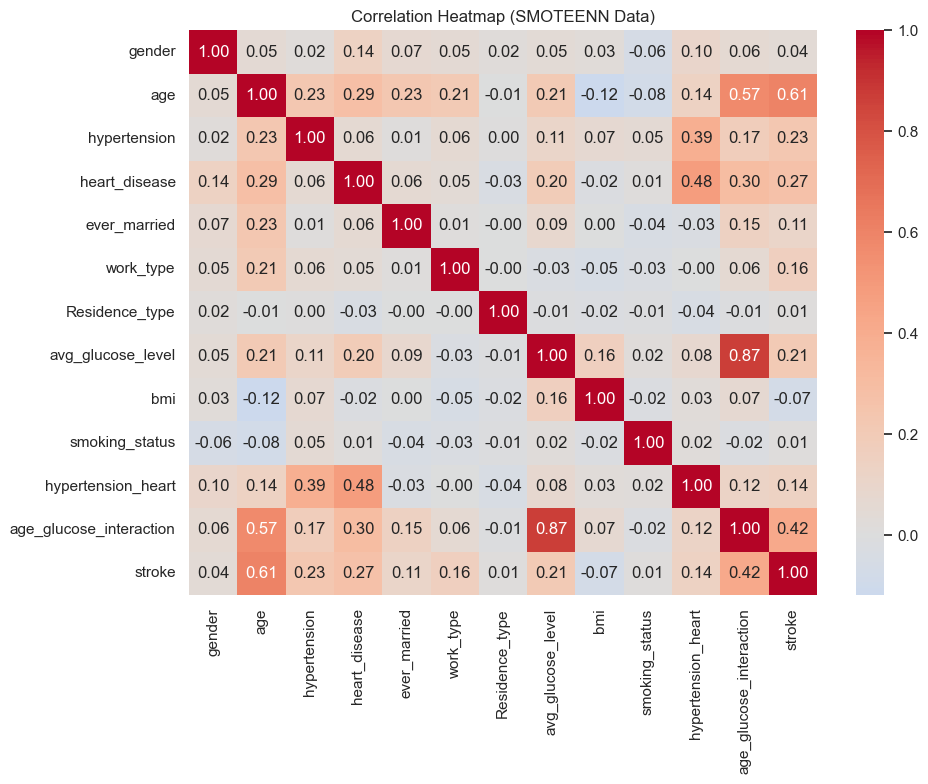

In [1046]:
corr_matrix = df_smoteenn.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (SMOTEENN Data)')
plt.tight_layout()
plt.show()

## Task 7
##### -Shortlist the most promising models or strategies.   
##### -Select approaches based on effectiveness, interpretability, and adaptability to different scenarios.   
##### -Choose models that provide meaningful insights, efficient learning, and reliable outcomes.   

In [1357]:
model_performance = {
    model_name: {
        'F1 Score': result['F1 Score'],
        'Test ROC-AUC': result['Test ROC-AUC'],
        'Test PR-AUC': result['Test PR-AUC'],
        'Sensitivity': result['Sensitivity'],
        'Precision': result['Precision'],
    }
    for model_name, result in tuned_results_2fe.items()
}

# Create a DataFrame from the model performance results
model_df = pd.DataFrame(model_performance).T

# Rank models based on Test PR-AUC and F1 Score (you can adjust the weighting or priority here)
ranked_models = model_df.sort_values(by=['F1 Score'], ascending=False)

# Shortlist top models (you can adjust the number of top models based on the results)
top_models = ranked_models.head(3)  

print("\nTop Shortlisted Models Based on Performance Metrics:")
display(top_models)



Top Shortlisted Models Based on Performance Metrics:


,F1 Score,Test ROC-AUC,Test PR-AUC,Sensitivity,Precision
Logistic Regression,0.103009,0.815837,0.076404,0.789062,0.055101
Naive Bayes,0.100466,0.791039,0.062072,0.757812,0.053799
Decision Tree,0.095491,0.725770,0.049426,0.421875,0.053838


# Part B

## Task 1
#### 1. Improve how the model learns by adjusting its settings   
##### - Fine-tune different options that control how the model processes data and makes decisions.   
##### - Try different ways of handling missing or unclear information, such as filling in gaps with estimated values, using common patterns in the data, or removing incomplete entries.   
##### - When testing different settings, randomly exploring options can be more efficient than checking every possibility. For models that take longer to train, smarter search methods can help find the best settings faster. 

### Refine Tuning

#### RandomizedSearchCV (Test 1)

In [1355]:
# Function to evaluate model
def evaluate_model(name, model, X_test, y_test, y_pred):
    print(f"\n=== {name.upper()} ===")
    print("Best Params:", model.get_params())
    print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))
    print("PR-AUC:", average_precision_score(y_test, model.predict_proba(X_test)[:, 1]))
    print("F1:", f1_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("f")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("f")
    print("Classification Report:\n", classification_report(y_test, y_pred))

In [1356]:
models_info = {
    'KNN': {
        'model': KNeighborsClassifier(),
        'scaling': True,
        'param_distributions': {
            'clf__n_neighbors': [3, 5, 7, 9],
            'clf__weights': ['uniform', 'distance'],
            'clf__metric': ['euclidean', 'manhattan']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'scaling': False,
        'param_distributions': {
            'clf__max_depth': [3, 5, 10, None],
            'clf__min_samples_split': [2, 5, 10],
            'clf__min_samples_leaf': [1, 2, 4]
        }
    },
    'Naive Bayes': {
        'model': GaussianNB(),
        'scaling': False,
        'param_distributions': {
            'clf__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, solver='liblinear'),
        'scaling': True,
        'param_distributions': {
            'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
            'clf__penalty': ['l1', 'l2']
        }
    }
}

results = []

# Loop through all models
for name, info in models_info.items():
    print(f"\n--- Tuning {name} ---")
    
    selected_features = feature_sets_2fe[name]
    X_train_sel = X_train_smoteenn_2fe[selected_features]
    X_test_sel = X_test_smoteenn_2fe[selected_features]
    
    # Pipeline with imputation and model
    steps = [('imputer', KNNImputer(n_neighbors=3)), ('clf', info['model'])]
    pipeline = Pipeline(steps)
    
    # RandomizedSearchCV for hyperparameter tuning
    search = RandomizedSearchCV(
        pipeline,
        info['param_distributions'],
        n_iter=20,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )
    
    # Fit the model
    search.fit(X_train_sel, y_train_smoteenn)
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test_sel)
    
    # Store evaluation metrics in results list
    result = {
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, best_model.predict_proba(X_test_sel)[:, 1]),
        'PR-AUC': average_precision_score(y_test, best_model.predict_proba(X_test_sel)[:, 1]),
        'F1': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
    }
    
    results.append(result)

    # Print the best parameters, confusion matrix, and classification report separately
    print(f"\nBest Params for {name}: {best_model.get_params()}")
    print(f"\nConfusion Matrix for {name}:\n", confusion_matrix(y_test, y_pred))
    
    # Display the classification report in the proper format
    print(f"\nClassification Report for {name}:\n", classification_report(y_test, y_pred))

# Convert results list to DataFrame for key metrics only
results_df = pd.DataFrame(results)
results_df = results_df.round(4)

# Display the results DataFrame
print("\nEvaluation Results (Key Metrics):")
print(results_df)


--- Tuning KNN ---
Fitting 5 folds for each of 16 candidates, totalling 80 fits


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 16 is smaller than n_iter=20. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best Params for KNN: {'memory': None, 'steps': [('imputer', KNNImputer(n_neighbors=3)), ('clf', KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance'))], 'verbose': False, 'imputer': KNNImputer(n_neighbors=3), 'clf': KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance'), 'imputer__add_indicator': False, 'imputer__copy': True, 'imputer__keep_empty_features': False, 'imputer__metric': 'nan_euclidean', 'imputer__missing_values': nan, 'imputer__n_neighbors': 3, 'imputer__weights': 'uniform', 'clf__algorithm': 'auto', 'clf__leaf_size': 30, 'clf__metric': 'manhattan', 'clf__metric_params': None, 'clf__n_jobs': None, 'clf__n_neighbors': 3, 'clf__p': 2, 'clf__weights': 'distance'}

Confusion Matrix for KNN:
 [[5306  760]
 [  88   40]]

Classification Report for KNN:
               precision    recall  f1-score   support

           0       0.98      0.87      0.93      6066
           1       0.05      0.31      0.09       128

    accuracy          

C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best Params for Naive Bayes: {'memory': None, 'steps': [('imputer', KNNImputer(n_neighbors=3)), ('clf', GaussianNB())], 'verbose': False, 'imputer': KNNImputer(n_neighbors=3), 'clf': GaussianNB(), 'imputer__add_indicator': False, 'imputer__copy': True, 'imputer__keep_empty_features': False, 'imputer__metric': 'nan_euclidean', 'imputer__missing_values': nan, 'imputer__n_neighbors': 3, 'imputer__weights': 'uniform', 'clf__priors': None, 'clf__var_smoothing': 1e-09}

Confusion Matrix for Naive Bayes:
 [[4360 1706]
 [  31   97]]

Classification Report for Naive Bayes:
               precision    recall  f1-score   support

           0       0.99      0.72      0.83      6066
           1       0.05      0.76      0.10       128

    accuracy                           0.72      6194
   macro avg       0.52      0.74      0.47      6194
weighted avg       0.97      0.72      0.82      6194


--- Tuning Logistic Regression ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 12 is smaller than n_iter=20. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best Params for Logistic Regression: {'memory': None, 'steps': [('imputer', KNNImputer(n_neighbors=3)), ('clf', LogisticRegression(C=0.001, max_iter=1000, penalty='l1', solver='liblinear'))], 'verbose': False, 'imputer': KNNImputer(n_neighbors=3), 'clf': LogisticRegression(C=0.001, max_iter=1000, penalty='l1', solver='liblinear'), 'imputer__add_indicator': False, 'imputer__copy': True, 'imputer__keep_empty_features': False, 'imputer__metric': 'nan_euclidean', 'imputer__missing_values': nan, 'imputer__n_neighbors': 3, 'imputer__weights': 'uniform', 'clf__C': 0.001, 'clf__class_weight': None, 'clf__dual': False, 'clf__fit_intercept': True, 'clf__intercept_scaling': 1, 'clf__l1_ratio': None, 'clf__max_iter': 1000, 'clf__multi_class': 'deprecated', 'clf__n_jobs': None, 'clf__penalty': 'l1', 'clf__random_state': None, 'clf__solver': 'liblinear', 'clf__tol': 0.0001, 'clf__verbose': 0, 'clf__warm_start': False}

Confusion Matrix for Logistic Regression:
 [[3713 2353]
 [  18  110]]

Classific

#### Optuna (Test 2)

In [1538]:
# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Define Optuna objective function
def objective(trial, model_name, X_train, y_train):
    # Selecting features for the specific model
    selected_features = feature_sets_2fe[model_name]
    X_train_sel = X_train[selected_features]
    
    # Define the model and hyperparameter search space
    if model_name == 'Decision Tree':
        max_depth = trial.suggest_categorical('max_depth', [3, 5, 10, 15, 20, None])
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        max_features = trial.suggest_categorical('max_features', [None, 'sqrt', 'log2'])
        min_impurity_decrease = trial.suggest_uniform('min_impurity_decrease', 0.0, 0.05)
        
        model = DecisionTreeClassifier(
            max_depth=max_depth, 
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            min_impurity_decrease=min_impurity_decrease,
            random_state=42
        )
      
    elif model_name == 'Naive Bayes':
        var_smoothing = trial.suggest_loguniform('var_smoothing', 1e-9, 1e-6)
        model = GaussianNB(var_smoothing=var_smoothing)
        
    elif model_name == 'Logistic Regression':
        C = trial.suggest_loguniform('C', 0.001, 100)
        penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
        solver = trial.suggest_categorical('solver', ['liblinear', 'saga'])
        max_iter = 1000  # To ensure convergence with higher regularization
        model = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=max_iter, random_state=42)

    # Build pipeline
    steps = [('imputer', KNNImputer(n_neighbors=3))]
    steps.append(('scaler', MinMaxScaler()))  # Scaling added for all models
    steps.append(('clf', model))
    
    pipeline = Pipeline(steps)

    # Cross-validation to get F1 score
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1 = cross_val_score(pipeline, X_train_sel, y_train, scoring='f1', cv=kfold, n_jobs=-1).mean()
    return f1

# Store results in a DataFrame
results = []
optuna_studies_ziyan2 = {}

# Loop through all models and optimize using Optuna, excluding KNN
for name, info in models_info.items():
    if name == 'KNN':
        continue  # Skip KNN model

    print(f"\n--- Tuning {name} with Optuna ---")
    
    # Run optimization using Optuna
    study = optuna.create_study(direction='maximize')  # maximize F1 score
    study.optimize(lambda trial: objective(trial, name, X_train_smoteenn_2fe, y_train_smoteenn), n_trials=20)

    optuna_studies_ziyan2[name] = study  # Save the study for reuse later

    # Best parameters found
    print(f"Best parameters for {name}:", study.best_params)
    
    # Create and evaluate the best model
    best_model_params_optuna = study.best_params
    if name == 'Decision Tree':
        best_model_optuna = DecisionTreeClassifier(**best_model_params_optuna)
    elif name == 'Naive Bayes':
        best_model_optuna = GaussianNB(**best_model_params_optuna)
    elif name == 'Logistic Regression':
        best_model_optuna = LogisticRegression(**best_model_params_optuna)
    
    steps = [('imputer', KNNImputer(n_neighbors=3))]
    steps.append(('scaler', MinMaxScaler()))  # Scaling for all models
    steps.append(('clf', best_model_optuna))
    pipeline = Pipeline(steps)
    
    # Fit the best model
    pipeline.fit(X_train_smoteenn_2fe, y_train_smoteenn)
    y_pred = pipeline.predict(X_test_smoteenn_2fe)
    
    # Store results for DataFrame
    results.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, pipeline.predict_proba(X_test_smoteenn_2fe)[:, 1]),
        'PR-AUC': average_precision_score(y_test, pipeline.predict_proba(X_test_smoteenn_2fe)[:, 1]),
        'F1': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    })
    
    # Evaluate the model
    evaluate_model(name, pipeline, X_test_smoteenn_2fe, y_test, y_pred)

# Create a DataFrame for all results
results_df = pd.DataFrame(results)

results_df = results_df.round(4)

# Display results
print("\nEvaluation Results of Hyperparameter Tuning (Optuna):")
print(results_df)



--- Tuning Decision Tree with Optuna ---
Best parameters for Decision Tree: {'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 8, 'max_features': None, 'min_impurity_decrease': 0.0004433993551347488}

=== DECISION TREE ===
Best Params: {'memory': None, 'steps': [('imputer', KNNImputer(n_neighbors=3)), ('scaler', MinMaxScaler()), ('clf', DecisionTreeClassifier(max_depth=20,
                       min_impurity_decrease=0.0004433993551347488,
                       min_samples_leaf=8, min_samples_split=7))], 'verbose': False, 'imputer': KNNImputer(n_neighbors=3), 'scaler': MinMaxScaler(), 'clf': DecisionTreeClassifier(max_depth=20,
                       min_impurity_decrease=0.0004433993551347488,
                       min_samples_leaf=8, min_samples_split=7), 'imputer__add_indicator': False, 'imputer__copy': True, 'imputer__keep_empty_features': False, 'imputer__metric': 'nan_euclidean', 'imputer__missing_values': nan, 'imputer__n_neighbors': 3, 'imputer__weights': 'uniform

## Task 2
#### 2. Combine different models to improve accuracy and reliability   
##### - Using multiple models together can lead to better overall results.   
##### - Consider blending different models to take advantage of their strengths, which can help reduce mistakes and make the model/system more effective.

In [1482]:
def evaluate_ensemble_model(name, model, X_test, y_test, y_pred):
    print(f"\n=== {name.upper()} ===")
    print("ROC-AUC:", f"{roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")
    print("PR-AUC:", f"{average_precision_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")
    print("F1:", f"{f1_score(y_test, y_pred):.4f}")
    print("Precision:", f"{precision_score(y_test, y_pred):.4f}")
    print("Recall:", f"{recall_score(y_test, y_pred):.4f}")
    print(f"")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(f"")
    print("Classification Report:\n", classification_report(y_test, y_pred, digits=4))

In [1603]:
# Build pipeline
ensemble_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=3)),
    ('scaler', MinMaxScaler()),
    ('clf', ensemble)
])
results_ensemble2 = []  

### Voting Classifier

In [1650]:
# Extract best models from studies
dt_clf = DecisionTreeClassifier(**optuna_studies_ziyan2['Decision Tree'].best_params, random_state=42)
nb_clf = GaussianNB(**optuna_studies_ziyan2['Naive Bayes'].best_params)
lr_clf = LogisticRegression(**optuna_studies_ziyan2['Logistic Regression'].best_params, random_state=42)

# Use model-specific features
voting_features = list(set(feature_sets_2fe['Decision Tree']) |
                       set(feature_sets_2fe['Naive Bayes']) )

X_train_voting = X_train_smoteenn_2fe[voting_features]
X_test_voting = X_test_smoteenn_2fe[voting_features]

# Define Voting Classifier with soft voting
voting_ensemble = VotingClassifier(
    estimators=[
        ('DT', dt_clf),
        ('NB', nb_clf)
    ],
    voting='soft'
)

# Pipeline with preprocessing
voting_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=3)),
    ('scaler', MinMaxScaler()),
    ('ensemble', voting_ensemble)
])

# Train ensemble
voting_pipeline.fit(X_train_voting, y_train_smoteenn)

# Predict and evaluate
y_pred_voting = voting_pipeline.predict(X_test_voting)
y_prob_voting = voting_pipeline.predict_proba(X_test_voting)[:, 1]

print("Voting Classifier Evaluation:")
evaluate_ensemble_model("Voting Classifier (DT,NB)", voting_pipeline, X_test_voting, y_test, y_pred_voting)

# Add to results
results_ensemble2.append({
    'Model': 'Voting Classifier',
    'ROC-AUC': roc_auc_score(y_test, y_prob_voting),
    'PR-AUC': average_precision_score(y_test, y_prob_voting),
    'F1': f1_score(y_test, y_pred_voting),
    'Precision': precision_score(y_test, y_pred_voting),
    'Recall': recall_score(y_test, y_pred_voting)
})

Voting Classifier Evaluation:

=== VOTING CLASSIFIER (DT,NB) ===
ROC-AUC: 0.8083
PR-AUC: 0.0683
F1: 0.1192
Precision: 0.0653
Recall: 0.6797

Confusion Matrix:
 [[4821 1245]
 [  41   87]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9916    0.7948    0.8823      6066
           1     0.0653    0.6797    0.1192       128

    accuracy                         0.7924      6194
   macro avg     0.5284    0.7372    0.5007      6194
weighted avg     0.9724    0.7924    0.8666      6194



In [1605]:
# Extract best models from studies
dt_clf = DecisionTreeClassifier(**optuna_studies_ziyan2['Decision Tree'].best_params, random_state=42)
nb_clf = GaussianNB(**optuna_studies_ziyan2['Naive Bayes'].best_params)
lr_clf = LogisticRegression(**optuna_studies_ziyan2['Logistic Regression'].best_params, random_state=42)

# Use model-specific features
voting_features = list(set(feature_sets_2fe['Decision Tree']) |
                       set(feature_sets_2fe['Naive Bayes']) |
                       set(feature_sets_2fe['Logistic Regression']))

X_train_voting = X_train_smoteenn_2fe[voting_features]
X_test_voting = X_test_smoteenn_2fe[voting_features]

# Define Voting Classifier with soft voting
voting_ensemble = VotingClassifier(
    estimators=[
        ('DT', dt_clf),
        ('NB', nb_clf),
        ('LR', lr_clf)
    ],
    voting='soft'
)

# Pipeline with preprocessing
voting_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=3)),
    ('scaler', MinMaxScaler()),
    ('ensemble', voting_ensemble)
])

# Train ensemble
voting_pipeline.fit(X_train_voting, y_train_smoteenn)

# Predict and evaluate
y_pred_voting = voting_pipeline.predict(X_test_voting)
y_prob_voting = voting_pipeline.predict_proba(X_test_voting)[:, 1]

print("Voting Classifier Evaluation:")
evaluate_ensemble_model("Voting Classifier (DT,NB,LR)", voting_pipeline, X_test_voting, y_test, y_pred_voting)

# Add to results
results_ensemble2.append({
    'Model': 'Voting Classifier',
    'ROC-AUC': roc_auc_score(y_test, y_prob_voting),
    'PR-AUC': average_precision_score(y_test, y_prob_voting),
    'F1': f1_score(y_test, y_pred_voting),
    'Precision': precision_score(y_test, y_pred_voting),
    'Recall': recall_score(y_test, y_pred_voting)
})

Voting Classifier Evaluation:

=== VOTING CLASSIFIER (DT,NB,LR) ===
ROC-AUC: 0.8176
PR-AUC: 0.0714
F1: 0.1217
Precision: 0.0668
Recall: 0.6797

Confusion Matrix:
 [[4851 1215]
 [  41   87]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9916    0.7997    0.8854      6066
           1     0.0668    0.6797    0.1217       128

    accuracy                         0.7972      6194
   macro avg     0.5292    0.7397    0.5035      6194
weighted avg     0.9725    0.7972    0.8696      6194



## Task 3
##### -Test the model in different situations to check its reliability  
##### - Measure how well the model performs on new data to make sure it works consistently. 
##### - Look at the types of mistakes it makes and think about how to reduce them.   
##### - If the system is meant to handle changing information, test whether it adapts well over time.  

### Fine Tune And Evalaute on Original X_test

In [1621]:
param_grid = {
    'ensemble__weights': [
        [1, 1, 1],
        [2, 1, 1],
        [1, 2, 1],
        [1, 1, 2],
        [3, 1, 2],
        [2, 2, 1],
        [1, 3, 2]
    ]
}

grid_search = GridSearchCV(
    voting_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_voting, y_train_smoteenn)

# Output best weights
print("Best Weights:", grid_search.best_params_)
print("Best ROC-AUC Score (CV):", grid_search.best_score_)
# Predict with best ensemble
best_model = grid_search.best_estimator_
y_pred_voting = best_model.predict(X_test_voting)
y_prob_voting = best_model.predict_proba(X_test_voting)[:, 1]

# Evaluate
print("Fine-Tuned Voting Classifier Evaluation:")
evaluate_ensemble_model("Voting Classifier (Fine-Tuned)", best_model, X_test_voting, y_test, y_pred_voting)

# Store results
results_ensemble2.append({
    'Model': 'Voting Classifier (Fine-Tuned)',
    'ROC-AUC': roc_auc_score(y_test, y_prob_voting),
    'PR-AUC': average_precision_score(y_test, y_prob_voting),
    'F1': f1_score(y_test, y_pred_voting),
    'Precision': precision_score(y_test, y_pred_voting),
    'Recall': recall_score(y_test, y_pred_voting)
})


Best Weights: {'ensemble__weights': [3, 1, 2]}
Best ROC-AUC Score (CV): 0.9328796571975484
Fine-Tuned Voting Classifier Evaluation:

=== VOTING CLASSIFIER (FINE-TUNED) ===
ROC-AUC: 0.8162
PR-AUC: 0.0711
F1: 0.1303
Precision: 0.0717
Recall: 0.7188

Confusion Matrix:
 [[4874 1192]
 [  36   92]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9927    0.8035    0.8881      6066
           1     0.0717    0.7188    0.1303       128

    accuracy                         0.8017      6194
   macro avg     0.5322    0.7611    0.5092      6194
weighted avg     0.9736    0.8017    0.8725      6194



### Evaluate on Simulated Data Drift (Noisy Test Set)

In [1645]:
import numpy as np
import pandas as pd

# Copy the original X_test
X_test_drift = X_test_voting.copy()

# Identify numerical columns to add noise
numeric_cols = X_test_drift.select_dtypes(include=[np.number]).columns

# Add Gaussian noise to simulate drift (mean=0, small stddev)
np.random.seed(42)
X_test_drift[numeric_cols] = X_test_drift[numeric_cols] + np.random.normal(0, 0.05, X_test_drift[numeric_cols].shape)

# Evaluate on drifted data
evaluate_model("Voting Classifier (Simulated Drift)", best_model, X_test_drift, y_test)



Voting Classifier (Simulated Drift) - Evaluation on Given Data:
Confusion Matrix:
 [[2186 3880]
 [  12  116]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.36      0.53      6066
           1       0.03      0.91      0.06       128

    accuracy                           0.37      6194
   macro avg       0.51      0.63      0.29      6194
weighted avg       0.97      0.37      0.52      6194

ROC-AUC: 0.7858
PR-AUC: 0.0593
F1 Score: 0.0563
Precision: 0.0290
Recall: 0.9062


### Cross-Validation on Entire Training Set

In [1627]:
from sklearn.model_selection import cross_val_predict

# Cross-validated predictions
cv_preds = cross_val_predict(best_model, X_train_voting, y_train_smoteenn, cv=5, method='predict_proba', n_jobs=-1)
cv_preds_class = (cv_preds[:, 1] >= 0.5).astype(int)

# Evaluate CV results
print("\nCross-Validation (on training set) Performance:")
print("ROC-AUC:", roc_auc_score(y_train_smoteenn, cv_preds[:, 1]))
print("PR-AUC:", average_precision_score(y_train_smoteenn, cv_preds[:, 1]))
print("F1 Score:", f1_score(y_train_smoteenn, cv_preds_class))
print("Precision:", precision_score(y_train_smoteenn, cv_preds_class))
print("Recall:", recall_score(y_train_smoteenn, cv_preds_class))


Cross-Validation (on training set) Performance:
ROC-AUC: 0.9330759605189606
PR-AUC: 0.9286090750532385
F1 Score: 0.8917424112502144
Precision: 0.8813135593220339
Recall: 0.9024210343630684


### Confusion Matrix & Error Analysis

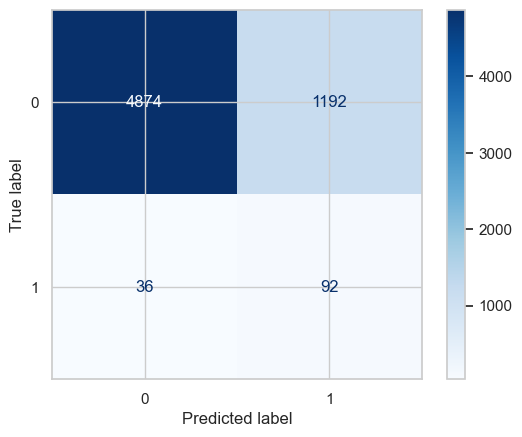

In [1632]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_voting)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')